# Extended BTFR MaNGA paper plots

* ~~Fig. 1 CMD diagram~~
* ~~Fig. 2 stellar mass density + profile '8319-1902'~~
* ~~Fig. 3 ellipticals pipe3d modeled Mstar vs NSA Mstar~~
* ~~Fig. 4 stellar/gas components for ellipticals and spirals~~
* ~~Fig. 5 stellar velocity disp, corrected, residual~~
* ~~Fig. 6 MaNGA Illustris matching plots~~
* ~~Fig. 7 Mtot and Veff compairsons~~
* ~~Fig. 8 Mstar vs Mtot for MaNGA Illustris matched samples~~
* ~~Fig. 9 spiral gas comparison for MaNGA and TNG~~
* ~~Fig. 10 stellar, baryonic, and total mass vs mr~~
* ~~Fig. 11 BTFR for matched samples (MCMC and fixed slope 4)~~
* ~~Fig. 12 distance to best BTFR~~
* Fig. 13 full MaNGA sample BTFR
* ~~Fig. 14 BTFR for full TNG sample (with contours)~~

## imports and data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib
from astropy.table import Table, vstack,hstack
import numpy.ma as ma
import matplotlib.cm as cm
import scipy 

from tqdm import tqdm

import emcee
import corner

# import marvin
import pyneb as pn
import sys
sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/ellipticals')
from elliptical_plottingFunctions import *
from IO_data import *
from elliptical_stellar_mass import calc_mass_curve
from elliptical_stellar_mass_functions import exponential_disk, exponential_sphere, exponential_sphere_disk
from matplotlib.lines import Line2D

from scipy.optimize import curve_fit
from scipy.optimize import minimize
import scipy.stats as stats

sys.path.insert(1, '/Users/nityaravi/Documents/Github/RotationCurves/spirals')
from SHMR_functions import shmr_RP11

In [2]:
master_table_fn = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/Elliptical_sphdisk_refitspirals_BPT_illustris_v11.fits'

master_table = Table.read(master_table_fn)
master_table[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

In [3]:
master_table_dict = {}
for i in range(len(master_table)):
    master_table_dict[master_table['plateifu'][i]] = i

In [4]:
PIPE3D_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Pipe3D/'
DATA_FOLDER = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/'
VEL_FOLDER = DATA_FOLDER + 'DR17/'


matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['savefig.dpi'] = 300

In [5]:
plot_dir = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax/'
plot_dir_HI = plot_dir + '/HI_spirals/'

In [6]:
ellipticals = master_table[master_table['elliptical_mask']==1]
spirals = master_table[master_table['spiral_mask']==1]

In [7]:
nsa_portsmouth = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/NSA_v1_0_1_vflag_Portsmouth.fits')
nsa_portsmouth[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [8]:
nsa_dict = {}
for i in range(len(nsa_portsmouth)):
    nsa_dict[nsa_portsmouth['NSAID'][i]] = i

In [9]:
G = 4.3009 * 10**-6 # [kpc (km/s)^2 / M_sun]
H_0 = 100 # [km / s / Mpc]
c = 299792.458 # Speed of light in units of km/s

In [10]:
blue_spirals = spirals[spirals['CMD_class'] == 1]
green_spirals = spirals[spirals['CMD_class']==2]
red_spirals = spirals[spirals['CMD_class']==3]

In [11]:
mcg = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/McGaugh_2012.csv', format='csv')
mcg[:5]

Galaxy,D,V_f,V_f_err,Mstar,Mstar_err,Mg,Mg_err
str8,float64,int64,int64,float64,float64,float64,float64
DDO 210,0.94,17,4,5.88,0.15,6.64,0.2
Cam B,3.34,20,12,6.99,0.15,7.33,0.2
UGC 8215,4.5,20,6,6.81,0.15,7.45,0.2
DDO 183,3.24,25,3,7.24,0.15,7.54,0.2
UGC 8833,3.2,27,4,6.94,0.15,7.3,0.2


In [12]:
torflor = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/torres_flores_2011.csv', format='csv')
torflor[:5]

Galaxy UGC,Mbar,Mbar_err,V_TF,V_TF_err
int64,float64,float64,int64,int64
89,11.37,0.1,343,117
94,10.72,0.08,209,21
763,9.81,0.06,104,11
1317,11.23,0.09,205,9
2141,9.82,0.08,157,20


In [13]:
HI_spirals = spirals[spirals['logHI_h']>0]

# for galaxies with unphysical bulge (R_bulge > 10 kpc) use only the disk mass


for i in range(len(HI_spirals)):
    if HI_spirals['R_bulge'][i] > 10:
        HI_spirals['sphd_M_star_h'][i] = np.log10(2 * np.pi * HI_spirals['Sigma_disk'][i] * (HI_spirals['R_disk'][i]*10**3)**2)
    

HI_spirals['Mstar_MHI_h'] = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_h'])
HI_spirals['Mstar_MHI_err_h'] = 0.5*np.log10((10**HI_spirals['sphd_M_star_err_h'])**2 + (10**HI_spirals['logHI_err_h'])**2)



# HI_ellipticals = ellipticals[np.logical_and(ellipticals['logHI_h'] >= 0, 
#                                             np.logical_or(ellipticals['HI_catalog'] == 'himanga_dr4', ellipticals['HI_catalog']=='himanga_dr4_alfalfa'))]
HI_ellipticals = ellipticals[ellipticals['logHI_h'] >= 0]

In [14]:
# put the final sample together to use for tng matching
manga_sample = vstack([HI_spirals, ellipticals])
# manga_sample.write('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/BTFR_manga_sample.fits', overwrite=True)

### run the IllustrisTNG_MaNGA_match_v2 notebook on this table -- then read in new table

In [15]:
manga_sample = Table.read('/Users/nityaravi/Documents/Research/RotationCurves/data/manga/output_files/DR17/CURRENT_MASTER_TABLE/BTFR_manga_sample_tng.fits')

In [16]:
i_sample = manga_sample[manga_sample['illustris_match'] >= 0]

### add gas stuff

In [17]:
HI_spirals = manga_sample[manga_sample['spiral_mask'] == 1]
ellipticals = manga_sample[manga_sample['elliptical_mask'] == 1]
HI_ellipticals = ellipticals[ellipticals['logHI_h'] >= 0]

In [18]:
# recalculate the components

HI_spirals['param_H2'] = np.zeros(len(HI_spirals))
HI_spirals['param_H2_h'] = np.zeros(len(HI_spirals))
HI_spirals['param_He_h'] = np.zeros(len(HI_spirals))
HI_spirals['param_He90_h'] = np.zeros(len(HI_spirals))


for i in range(len(HI_spirals)):
    
    if HI_spirals['CMD_class'][i] == 1:
        HI_spirals['param_H2'][i] = -0.4*HI_spirals['rabsmag'][i] +1.12
    elif HI_spirals['CMD_class'][i] == 2 or HI_spirals['CMD_class'][i] == 3:
        HI_spirals['param_H2'][i] = -0.27*HI_spirals['rabsmag'][i] + 3.62

    HI_spirals['param_H2_h'][i] = HI_spirals['param_H2'][i] + np.log10(0.7)
    HI_spirals['param_He_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_spirals['logHI'][i] + 10**HI_spirals['param_H2'][i])
    HI_spirals['param_He90_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_spirals['logHI_R90'][i] + 10**HI_spirals['param_H2'][i])

HI_ellipticals['param_H2'] = np.zeros(len(HI_ellipticals))
HI_ellipticals['param_H2_h'] = np.zeros(len(HI_ellipticals))
HI_ellipticals['param_He_h'] = np.zeros(len(HI_ellipticals))
HI_ellipticals['param_He90_h'] = np.zeros(len(HI_ellipticals))


for i in range(len(HI_ellipticals)):
    
    if HI_ellipticals['CMD_class'][i] == 1:
        HI_ellipticals['param_H2'][i] = -0.4*HI_ellipticals['rabsmag'][i] +1.12
    elif HI_ellipticals['CMD_class'][i] == 2 or HI_ellipticals['CMD_class'][i] == 3:
        HI_ellipticals['param_H2'][i] = -0.27*HI_ellipticals['rabsmag'][i] + 3.62

    HI_ellipticals['param_H2_h'][i] = HI_ellipticals['param_H2'][i] + np.log10(0.7)
    HI_ellipticals['param_He_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_ellipticals['logHI'][i] + 10**HI_ellipticals['param_H2'][i])
    HI_ellipticals['param_He90_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_ellipticals['logHI_R90'][i] + 10**HI_ellipticals['param_H2'][i])


## functions

In [19]:
def lin_fit(x, a, b):

    return a*x + b

def lin_fit_fixed_slope(x, b):

    return x + b

def chi2_norm(model, data, err, dof):

    return np.sum(((model-data)/err)**2)/(len(data)-dof)

In [20]:
def logl(params, x, y, dy):

    '''
    PARAMETERS
    ==========

    a : slope
    b : y int
    
    '''

    a, b = params

    model = a * x + b

    return -0.5 * np.sum((y-model)**2/dy**2 + np.log(2*np.pi*dy**2))

def log_prior(params):

    a, b = params
    if -10 < a < 10 and -10 < b < 10:
        return 0.

    return -np.inf

def log_prob(params, x, y, dy):

    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf

    return lp + logl(params, x, y, dy)
    

In [21]:
def get_BTFR_vals_from_txt(fn):

    f = open(fn, mode='r')
    text = f.read()
    f.close()

    text = text.replace('\n', ' ')
    text = text.replace('  ', ' ')

    idx = text.find('[')
    idx2 = text.find(']')
    ctrs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)
    text=text.split(']',1)[1]
    
    idx = text.find('[')
    idx2 = text.find(']')
    avgs = np.array(text[idx+1:idx2].split(' ',-1)).astype(float)
    text=text.split(']',1)[1]
    
    
    idx = text.find('[')
    idx2 = text.find(']')
    sigs = np.array(text[idx+1:idx2].split(' ',-1)).astype(float)
    text=text.split(']',1)[1]

    print(text)
    
    slope = float(text.split('[',1)[0].split(' ',-1)[-1])
    yint = float(text.split('[', -1)[1].split(' ', -1)[-1])
    yint_fixed = float(text.split('4 y-int ')[1].split(' ')[0])

    return ctrs, avgs, sigs, slope, yint, yint_fixed

In [22]:
def get_vals_from_txt(fn):

    f = open(fn, mode='r')
    text = f.read()
    f.close()

    text = text.replace('\n', ' ')
    text = text.replace('  ', ' ')

    idx = text.find('[')
    idx2 = text.find(']')
    ctrs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)
    text=text.split(']',1)[1]
    
    idx = text.find('[')
    idx2 = text.find(']')
    avgs = np.array(text[idx+1:idx2].split(' ',-1)).astype(float)
    text=text.split(']',1)[1]
    
    
    idx = text.find('[')
    idx2 = text.find(']')
    sigs = np.array(text[idx+1:idx2].split(' ',-1)).astype(float)
    text=text.split(']',1)[1]


    vals = text.split(' ')
    slope = float(vals[2])
    yint = float(vals[6])
    
    # slope = float(text.split('[',1)[0].split(' ',-1)[-1])
    # yint = float(text.split('[', -1)[1].split(' ', -1)[-1])
    # yint_fixed = float(text.split('4 y-int ')[1].split(' ')[0])

    return ctrs, avgs, sigs, slope, yint

## test gal set up

In [23]:
gal_ID = '8319-1902'
pipe3d_maps = extract_Pipe3d_data(PIPE3D_FOLDER, '8319-1902', ['sMass'])
dap_maps = extract_data(VEL_FOLDER, '8319-1902', ['star_sigma', 'flux'])

idx = master_table_dict[gal_ID]
sMass = pipe3d_maps['sMass_density']
sMass_err = pipe3d_maps['sMass_density_err']
flux = dap_maps['mflux']
ba = master_table['nsa_elpetro_ba'][idx]
z = master_table['nsa_z'][idx]
phi = master_table['nsa_elpetro_phi'][idx]
R90 = master_table['R90_kpc'][idx]
Mstar = master_table['sphd_M_star'][idx]
Mstar_R90 = master_table['e_M_star_R90'][idx]

## Fig 1 CMD

In [24]:
cmd_color_dict = {1.0: 'b',
            2.0: 'g',
            3.0:'r',
            -99: 'k',
           -1: 'k'}
cmd_marker_dict = {1.0: '+',
            2.0: '*',
            3.0:'.',
            -99: '.',
           -1: '.'}
cmd_fc_dict = {1.0: None,
            2.0: None,
            3.0:'none',
            -99: None,
           -1: None}

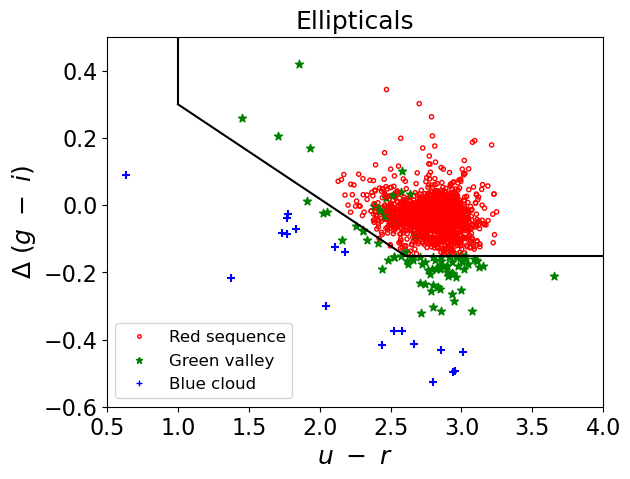

In [25]:
for i in range(len(ellipticals)):
    nsaid = ellipticals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    plt.scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker=cmd_marker_dict[ellipticals[i]['CMD_class']], 
                color=cmd_color_dict[ellipticals[i]['CMD_class']], 
               facecolor=cmd_fc_dict[ellipticals[i]['CMD_class']],
               )


plt.xlim(0.5,4)
plt.ylim(-0.6,0.5)
plt.xlabel(r'$u\ -\ r$', fontsize=18)
plt.ylabel(r'$\Delta\ (g\ -\ i)$', fontsize=18)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='.', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='*', color='w', label='Green valley',
                          markeredgecolor='g', markerfacecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markerfacecolor='b', markersize=5)]
plt.tick_params( axis='both', labelsize=16)

plt.title('Ellipticals', fontsize=18)
plt.legend(handles=legend_elements, loc='lower left', fontsize='large')
plt.savefig(plot_dir + 'ellipticals_CMD.png', bbox_inches='tight')

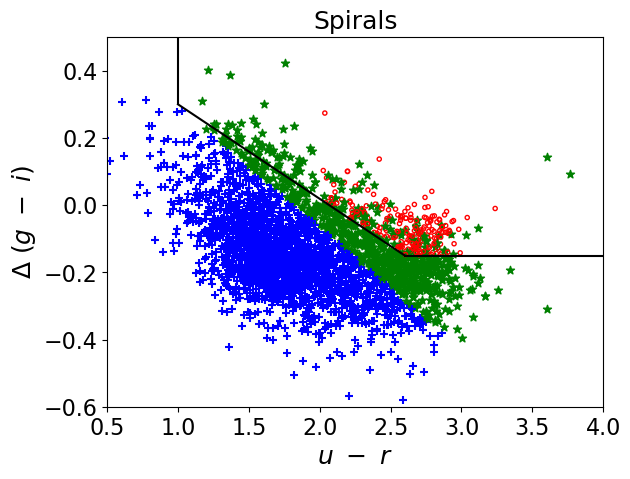

In [26]:
for i in range(len(HI_spirals)):
    nsaid = HI_spirals[i]['nsa_nsaid']
    nsa_idx = nsa_dict[nsaid]

    plt.scatter(nsa_portsmouth['u_r_KIAS'][nsa_idx], nsa_portsmouth['cd'][nsa_idx], marker=cmd_marker_dict[HI_spirals[i]['CMD_class']], 
                color=cmd_color_dict[HI_spirals[i]['CMD_class']], 
               facecolor=cmd_fc_dict[HI_spirals[i]['CMD_class']],
               )


plt.xlim(0.5,4)
plt.ylim(-0.6,0.5)
plt.xlabel(r'$u\ -\ r$', fontsize=18)
plt.ylabel(r'$\Delta\ (g\ -\ i)$', fontsize=18)
plt.plot([4,2.6],[-0.15,-0.15], color='k')
plt.plot([2.6,1.0],[-0.15,0.3], color='k')
plt.plot([1.0,1.0],[0.3,10], color='k')




legend_elements = [Line2D([0], [0], marker='.', color='w', label='Red sequence',
                          markeredgecolor='r', markersize=5),
                   Line2D([0], [0], marker='*', color='w', label='Green valley',
                          markeredgecolor='g', markerfacecolor='g', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Blue cloud',
                          markeredgecolor='b', markerfacecolor='b', markersize=5)]
plt.tick_params( axis='both', labelsize=16)

plt.title('Spirals', fontsize=18)
# plt.legend(handles=legend_elements, loc='lower left')
plt.savefig(plot_dir + 'spirals_CMD.png', bbox_inches='tight')

## Fig 2 sMass

In [62]:
sMass_density = pipe3d_maps['sMass_density']
msMass_density = ma.array(sMass_density, mask=np.isnan(sMass_density))

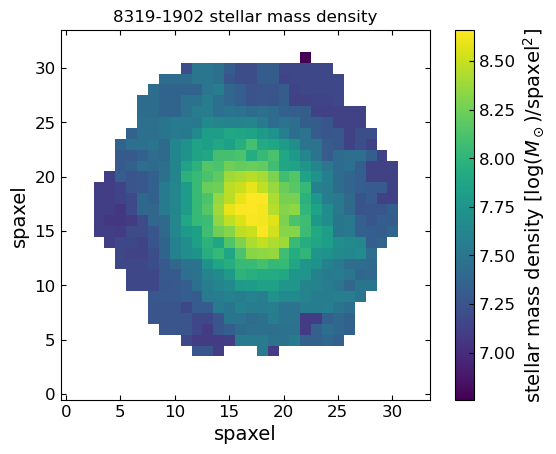

In [63]:
fig, ax = plt.subplots()

vmax = ma.max(msMass_density)
#cbar_ticks = np.linspace( 0, vmax, 11, dtype='int')

ax.set_title(gal_ID + ' stellar mass density', fontsize=12)
############################################################################


############################################################################
# Create plot
#---------------------------------------------------------------------------
vel_im = ax.imshow( msMass_density, 
                    cmap='viridis', 
                    origin='lower', 
                    #vmin=0, 
                    #vmax=vmax
                  )

cbar = plt.colorbar( vel_im, ax=ax)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'stellar mass density $[\log(M_\odot) / \rm spaxel^2]$', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)

plt.savefig( plot_dir + gal_ID + '_sMass_density.png', 
             format='png', 
             bbox_inches = 'tight', 
             pad_inches = 0
             )

### model

In [64]:
mass_table

NameError: name 'mass_table' is not defined

In [65]:
mass_table = calc_mass_curve(sMass, sMass_err, flux, ba, phi, z)
rs = np.linspace(np.min(mass_table['radius']), np.max(mass_table['radius']), 1000)
rs = np.linspace(0,4, 1000)
sph = exponential_sphere(rs, 10**master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx])
disk = exponential_disk(rs, 10**master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
sphdisk = exponential_sphere_disk(rs, master_table['sphd_rho_c'][idx], master_table['sphd_R_scale'][idx],
                                  master_table['sphd_Sigma_d'][idx], master_table['sphd_R_d'][idx])
mass_table['M_star_err'] = mass_table['M_star_err'] + np.max(mass_table['M_star'])-2.5

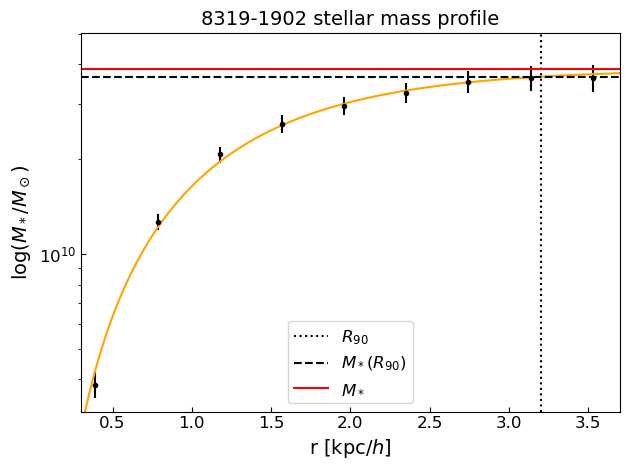

In [68]:
plt.errorbar(mass_table['radius'], 10**mass_table['M_star'], yerr=10**mass_table['M_star_err'], color='k', fmt='.')
# plt.plot(rs, sph, color='dodgerblue', linestyle='--', label='sphere')
# plt.plot(rs, disk, color='crimson', linestyle='--', label='disk')
plt.plot(rs, sphdisk, color='orange')
plt.ylim(10**9.5, 10**10.7)
plt.yscale('log')
plt.xlabel(r'r [kpc/$h$]', fontsize=14)
plt.ylabel(r'$\log(M_*/M_\odot)$',fontsize=14)
# ax[1].legend(loc='lower right', )
plt.tick_params( axis='both', direction='in', labelsize=12)


#R90, M(R90), M*
plt.axvline(R90, color='k', linestyle=':', label=r'$R_{90}$')
plt.axhline(10**Mstar_R90, color='k', linestyle='--', label=r'$M_*(R_{90})$')

plt.axhline(10**Mstar, color='r', label = r'$M_*$')
plt.legend(fontsize=12)

plt.xlim(0.3, 3.7)

plt.title(gal_ID + ' stellar mass profile', fontsize=14)
plt.tight_layout()
plt.savefig(plot_dir + gal_ID +  '_smass_sphd_fit.png', bbox_inches='tight', pad_inches=0)

## fig 3 nsa vs modeled mass

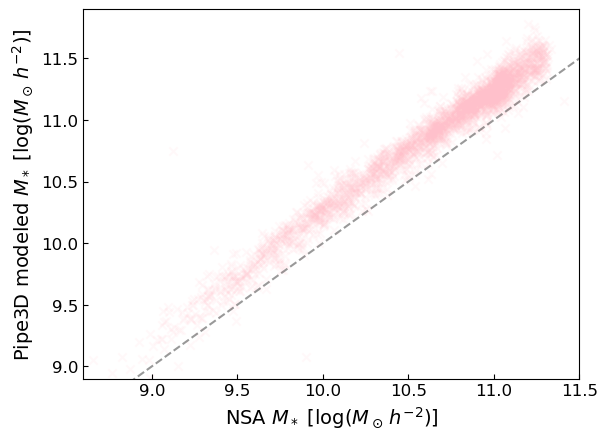

In [35]:
plt.scatter(ellipticals['nsa_elpetro_log_mass'], ellipticals['e_M_star_R90'] + np.log10(0.73**2), color='pink', alpha=0.1, marker='x')
plt.plot([8,12.5],[8,12.5], color='k', alpha=0.4, linestyle='--')
plt.xlim(8.6,11.5)
plt.ylim(8.9,11.9)
plt.tick_params( axis='both', direction='in', labelsize=12)

plt.xlabel(r'NSA $M_*$ $[\log(M_\odot\,h^{-2})]$', fontsize=14)
plt.ylabel(r'Pipe3D modeled $M_*$ $[\log(M_\odot\,h^{-2})]$', fontsize=14)
plt.savefig(plot_dir + 'nsa_pipe3d_model_mstar_compare.png')

In [36]:
print(ma.mean(ellipticals['e_M_star_R90']+ np.log10(0.73**2) - ellipticals['nsa_elpetro_log_mass']))
print(ma.median(ellipticals['e_M_star_R90']+ np.log10(0.73**2) - ellipticals['nsa_elpetro_log_mass']))

0.24552363692992502
0.24911255337619131


## fig 4 spiral galaxy components/ellipticals mr dist

### top figure, scatter plot of HI fraction

In [56]:
mr_bins =  np.linspace(np.min(manga_sample['rabsmag'])-0.01,
                 np.max(manga_sample['rabsmag']), 15)

In [57]:
elliptical_HI_ratio = HI_ellipticals['logHI_h'] - HI_ellipticals['sphd_M_star_h']
spirals_HI_ratio = HI_spirals['logHI_h'] - HI_spirals['sphd_M_star_h']

In [58]:
mr_e_HIrat_bins = []
mr_e_HIrat_bin_ctrs = []
e_HIrat = []
mr_e_HIrat_bins = mr_bins[0::2]

mr_e_HIrat_bins = np.concatenate((mr_bins[:1], mr_bins[4:-5:2], mr_bins[-1:]))

indices = np.digitize(HI_ellipticals['rabsmag'], mr_e_HIrat_bins, right=True)

for i in range(1,len(mr_e_HIrat_bins)):

    e_HIrat.append(elliptical_HI_ratio[indices==i])
    mr_e_HIrat_bin_ctrs.append(np.mean(HI_ellipticals['rabsmag'][indices==i]))

e_HIrat_avg, e_HIrat_sig = fit_to_gaussian(e_HIrat, plot_dir = plot_dir + 'ellipticals_HI/ellipticals/', plot_name='elliptical_HI_ratio_mstar', xlab=r'$M_{\rm tot}$', plot_bins=mr_e_HIrat_bins, bin_lab=r'$M_r$', bin_order='flip')
# rs_mtot_popt, rs_mtot_pcov = curve_fit(lin_fit, rs_mr_mtot_ctrs, 
#                                        rs_mtot_avg, sigma=rs_mtot_sig)
# print(rs_mtot_popt, np.sqrt(rs_mtot_pcov[0,0]), np.sqrt(rs_mtot_pcov[1,1]))


In [59]:
# write data to a file 
f = open(plot_dir + 'ellipticals_HI/ellipticals/data.txt', 'x')
f.write('e_mr_centers \n')
f.write(str(mr_e_HIrat_bin_ctrs) + '\n')
f.write('e_HIratio_avgs \n')
f.write(str(e_HIrat_avg)+ '\n')
f.write('e_HIratio_sigs \n')
f.write(str(e_HIrat_sig)+ '\n')

f.close()



FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax/ellipticals_HI/ellipticals/data.txt'

In [60]:
mr_s_HIrat_bins = []
mr_s_HIrat_bin_ctrs = []
s_HIrat = []
mr_s_HIrat_bins = mr_bins

mr_s_HIrat_bins = np.concatenate((mr_bins[:1], mr_bins[3:-4], mr_bins[-1:]))
indices = np.digitize(HI_spirals['rabsmag'], mr_s_HIrat_bins, right=True)

for i in range(1,len(mr_s_HIrat_bins)):

    s_HIrat.append(spirals_HI_ratio[indices==i])
    mr_s_HIrat_bin_ctrs.append(np.mean(HI_spirals['rabsmag'][indices==i]))

s_HIrat_avg, s_HIrat_sig = fit_to_gaussian(s_HIrat, plot_dir = plot_dir + 'ellipticals_HI/spirals/', 
                                           plot_name='spiral_HI_ratio_mstar', xlab=r'$M_{\rm tot}$', 
                                           plot_bins=mr_s_HIrat_bins, bin_lab=r'$M_r$', bin_order='flip',
                                          )


In [61]:
# write data to a file 
f = open(plot_dir + 'ellipticals_HI/spirals/data.txt', 'x')
f.write('s_mr_centers \n')
f.write(str(mr_s_HIrat_bin_ctrs) + '\n')
f.write('s_HIratio_avgs \n')
f.write(str(s_HIrat_avg)+ '\n')
f.write('s_HIratio_sigs \n')
f.write(str(s_HIrat_sig)+ '\n')

f.close()



FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax/ellipticals_HI/spirals/data.txt'

#### plot

In [ ]:
plt.scatter(HI_spirals['rabsmag'], spirals_HI_ratio, marker='+', color='cornflowerblue', alpha=0.4)
plt.scatter(HI_ellipticals['rabsmag'], elliptical_HI_ratio, marker='x', color='pink', alpha=0.7),

plt.errorbar(mr_s_HIrat_bin_ctrs, s_HIrat_avg, yerr=s_HIrat_sig, marker='^', color='navy', linestyle='none')
plt.errorbar(mr_e_HIrat_bin_ctrs, e_HIrat_avg, yerr = e_HIrat_sig, marker='o', color='firebrick', linestyle='none')

plt.xlim(-16.1, -22.9)
plt.ylim(-5,2)
plt.xlabel(r'$M_r$')
plt.ylabel(r'$\log (M_{\rm HI}/M_*)$')

### 2nd and 3rd plots

In [62]:
bins  = np.arange(-23, -15.5, 0.5)
e_indices = np.digitize(ellipticals['rabsmag'], bins, right=True)
e_HI_indices = np.digitize(HI_ellipticals['rabsmag'], bins, right=True)
s_indices = np.digitize(HI_spirals['rabsmag'], bins, right=True)
bin_ctrs = (bins[1:] + bins[:-1])/2

s_mbar = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_h'] + 10**(HI_spirals['param_H2_h']) +10**HI_spirals['param_He_h'])
e_mbar = np.log10(10**HI_ellipticals['sphd_M_star_h'] + 10**HI_ellipticals['logHI_h'] + 10**HI_ellipticals['param_H2_h'] + 10**HI_ellipticals['param_He_h'])

e_all = []
e_HI_all = []
e_mstar = []
e_mstar_hi = []
e_mstar_he = []

s_all = []
s_mstar = []
s_mstar_hi = []
s_mstar_he = []

for i in range(1,len(bins)):

    e_all.append(ellipticals['rabsmag'][e_indices==i])
    e_HI_all.append(HI_ellipticals['rabsmag'][e_HI_indices==i])
    s_all.append(HI_spirals['rabsmag'][s_indices==i])

    s_mstar.append(10**(HI_spirals['sphd_M_star_h'][s_indices==i] - s_mbar[s_indices==i]))
    e_mstar.append(10**(HI_ellipticals['sphd_M_star_h'][e_HI_indices==i] - e_mbar[e_HI_indices==i]))
    e_mstar_hi.append(10**(np.log10(10**HI_ellipticals['sphd_M_star_h'][e_HI_indices==i] +
                                   10**HI_ellipticals['logHI_h'][e_HI_indices==i])
                           - e_mbar[e_HI_indices==i]))

    e_mstar_he.append(10**(np.log10(10**HI_ellipticals['sphd_M_star_h'][e_HI_indices==i] +
                                   10**HI_ellipticals['logHI_h'][e_HI_indices==i] + 10**HI_ellipticals['param_He_h'][e_HI_indices==i])
                           - e_mbar[e_HI_indices==i]))

    s_mstar_he.append(10**((np.log10(10**(HI_spirals['sphd_M_star_h'][s_indices==i]) + 10**(HI_spirals['logHI_h'][s_indices==i]) 
                                     + 10**(HI_spirals['param_He_h'][s_indices==i]))
                      - s_mbar[s_indices==i])))
    s_mstar_hi.append(10**(np.log10(10**HI_spirals['sphd_M_star_h'][s_indices==i] + 10**HI_spirals['logHI_h'][s_indices==i]) - s_mbar[s_indices==i]))

In [63]:
e_counts = np.zeros(len(e_all))
e_HI_counts = np.zeros(len(e_HI_all))

e_mstarHI_med = np.zeros(len(s_mstar))
e_mstarHIHe_med = np.zeros(len(s_mstar))


s_counts = np.zeros(len(s_all))
s_mstar_med = np.zeros(len(s_mstar))
s_mstarHI_med = np.zeros(len(s_mstar))
s_mstarHIHe_med = np.zeros(len(s_mstar))
e_mstar_med = np.zeros(len(e_mstar))

for i in range(len(e_all)):
    e_counts[i] = len(e_all[i])

for i in range(len(e_HI_all)):
    e_HI_counts[i] = len(e_HI_all[i])

for i in range(len(s_all)):
    s_counts[i] = len(s_all[i])

for i in range(len(e_mstar)):
    e_mstar_med[i] = np.median(e_mstar[i])
    e_mstarHI_med[i] = np.median(e_mstar_hi[i])
    e_mstarHIHe_med[i] = np.median(e_mstar_he[i])

for i in range(len(s_mstar)):

    s_mstar_med[i] = np.median(s_mstar[i])
    s_mstarHI_med[i] =  np.median(s_mstar_hi[i])
    s_mstarHIHe_med[i] =  np.median(s_mstar_he[i])


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3502: RuntimeWarning: Mean of empty slice.
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### combined plot

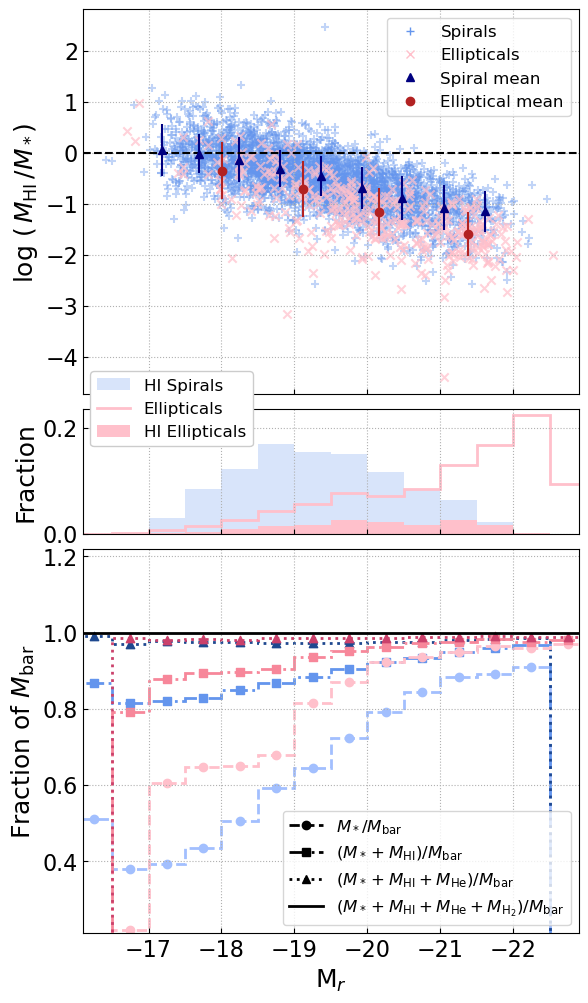

In [64]:
fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(4,1.3, 4), figsize=(6.4,12))

# spiral stellar mass
ax[2].stairs(s_mstar_med, bins, color='xkcd:pastel blue', linestyle='--', linewidth=2, label=r'$M_*/M_{\rm bar}$')
ax[2].scatter(bin_ctrs, s_mstar_med, color='xkcd:pastel blue', marker='o')

# stellar + HI
ax[2].stairs(s_mstarHI_med, bins, color='cornflowerblue', linewidth=2, linestyle='-.', label=r'$(M_*+M_{\rm HI})/M_{\rm bar}$')
ax[2].scatter(bin_ctrs, s_mstarHI_med, color='cornflowerblue', marker='s')

# stellar + HI + He
ax[2].stairs(s_mstarHIHe_med, bins, color='xkcd:cobalt', linewidth=2, linestyle=':', label=r'$(M_*+M_{\rm HI} +M_{\rm He})/M_{\rm bar}$')
ax[2].scatter(bin_ctrs, s_mstarHIHe_med, color='xkcd:cobalt', marker='^')


# ellipticals stellar
ax[2].stairs(e_mstar_med, bins, color='pink', linewidth=2, linestyle='--', alpha=1)
ax[2].scatter(bin_ctrs, e_mstar_med, color='pink', marker='o', alpha=1)

#stellar + HI
ax[2].stairs(e_mstarHI_med, bins, color='xkcd:rose pink', linewidth=2, linestyle='-.')
ax[2].scatter(bin_ctrs, e_mstarHI_med, color='xkcd:rose pink', marker='s')


#stellar + HI + He


ax[2].stairs(e_mstarHIHe_med, bins, color='xkcd:dark pink', linewidth=2, linestyle=':')
ax[2].scatter(bin_ctrs, e_mstarHIHe_med, color='xkcd:dark pink', marker='^')


ax[2].axhline(1, linestyle='-', color='k', linewidth=2, label=r'$(M_*+M_{\rm HI}+M_{\rm H_2})/M_{\rm bar} = 1$')



# ax[1].stairs(e_counts/len(ellipticals), bins, color='pink', linewidth=2, label='Ellipticals', hatch='///')
# ax[1].stairs(e_HI_counts/len(ellipticals), bins, edgecolor='pink', linewidth=2, label='HI Ellipticals', facecolor='w', fill=True, )
# ax[1].stairs(s_counts/len(HI_spirals), bins, color='cornflowerblue', linewidth=2, label='HI Spirals', )

ax[1].stairs(s_counts/len(HI_spirals), bins, color='cornflowerblue', linewidth=2, label='HI Spirals', fill=1, alpha=0.25)

ax[1].stairs(e_counts/len(ellipticals), bins, color='pink', linewidth=2, label='Ellipticals')
ax[1].stairs(e_HI_counts/len(ellipticals), bins, color='pink', linewidth=2, label='HI Ellipticals',fill=1, alpha=1)



ax[0].scatter(HI_spirals['rabsmag'], (HI_spirals['logHI_h'] - HI_spirals['sphd_M_star_h']),
              marker='+', color='cornflowerblue', alpha=0.4)

# ax[0].set_ylim(-5,2)


ax[0].scatter(HI_ellipticals['rabsmag'], (HI_ellipticals['logHI_h'] - HI_ellipticals['sphd_M_star_h']), 
              marker='x', color='pink', alpha=0.7)


ax[0].errorbar(mr_s_HIrat_bin_ctrs, s_HIrat_avg, yerr=s_HIrat_sig, color='navy', marker='^', linestyle='none', label='Spiral mean')
ax[0].errorbar(mr_e_HIrat_bin_ctrs, e_HIrat_avg, yerr=e_HIrat_sig, color='firebrick', marker='o', linestyle='none', label='Elliptical mean')


for i in range(3):
    ax[i].tick_params( axis='both', direction='in', labelsize=16)
    ax[i].grid(linestyle=':')



ax[1].legend(fontsize='large', loc=(0.015,0.7), framealpha=1)

ax[0].set_xlim(-16, -23)
# ax[0].set_xlabel(r'$M_r$',fontsize=18)
ax[0].axhline(0, linestyle='--', color='k')


ax[0].set_ylabel(r'$\log\,(\,M_{\rm HI}\,/M_*)$',fontsize=18)
ax[1].set_ylabel('Fraction', fontsize=18)

legend_elements = [#Line2D([0], [0], marker='o', color='w', label='IllustrisTNG ellipticals',
                    #      markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                    Line2D([0], [0], marker='^', color='w', label='Spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                    Line2D([0], [0], marker='o', color='w', label='Elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),]


ax[0].legend(handles=legend_elements, fontsize='large',
           # loc='upper center', framealpha=1, ncols=5,
             loc='upper right'
          )


legend_elements_2 = [Line2D([0], [0], marker='o', color='k', label=r'$M_*/M_{\rm bar}$',
                            markeredgecolor='k', markerfacecolor='k', linestyle='--', markersize=6, linewidth=2),
                     Line2D([0], [0], marker='s', color='k', label=r'$(M_* + M_{\rm HI})/M_{\rm bar}$',
                            markeredgecolor='k', markerfacecolor='k', linestyle='-.', markersize=6, linewidth=2),
                     Line2D([0], [0], marker='^', color='k', label=r'$(M_* + M_{\rm HI} + M_{\rm He})/M_{\rm bar}$',
                            markeredgecolor='k', markerfacecolor='k', linestyle=':', markersize=6, linewidth=2),
                     Line2D([0], [0], marker='none', color='k', label=r'$(M_* + M_{\rm HI} + M_{\rm He} + M_{\rm H_2})/M_{\rm bar}$',
                            markeredgecolor='k', markerfacecolor='k', linestyle='-', markersize=6, linewidth=2),
                     

]
ax[2].legend(handles=legend_elements_2, fontsize='large', ncols=1, loc='lower right')


ax[1].set_xlim(-16.1,-22.9)
ax[2].set_ylim(0.21,1.22)
ax[2].set_ylabel(r'Fraction of $M_{\rm bar}$', fontsize=18)
plt.xlabel(r'M$_r$ ', fontsize=18)
fig.subplots_adjust(hspace=0.05)

plt.savefig(plot_dir + 'ellipticals_HI/spiral_comp_ellipticals_combined_means_refit.png', bbox_inches='tight')

## fig 5, stell vel disp

In [36]:
star_sigma = dap_maps['star_sigma']
star_sigma_mask = dap_maps['star_sigma_mask']
star_sigma_correction = dap_maps['star_sigma_corr']

mstar_sigma = ma.array(star_sigma, mask=star_sigma_mask)
mstar_sigma_correction = ma.array(star_sigma_correction, mask=star_sigma_mask)
mstar_sigma_corr = np.sqrt(mstar_sigma**2 - mstar_sigma_correction**2)

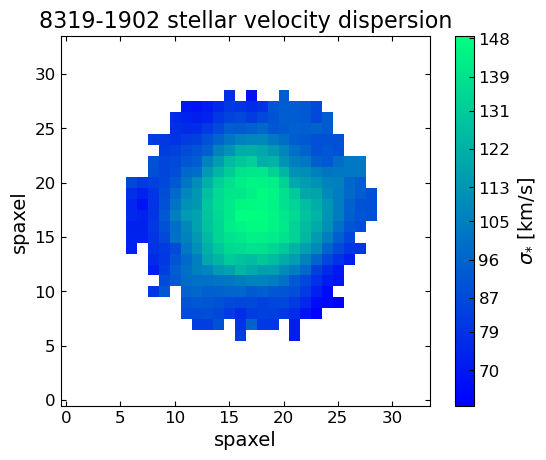

In [37]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma), ma.max(mstar_sigma), 11, dtype='int')
ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma), 
                    vmax=ma.max(mstar_sigma))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title('8319-1902 stellar velocity dispersion', fontsize=16)


plt.savefig(plot_dir + gal_ID + '_stel_sigma.png', bbox_inches='tight', pad_inches=0)

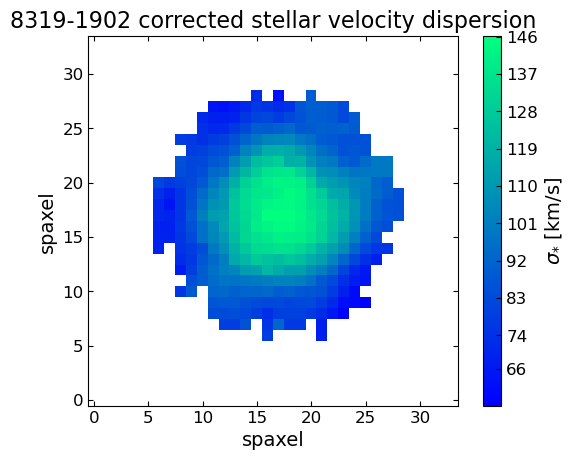

In [38]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma_corr), ma.max(mstar_sigma_corr), 11, dtype='int')
ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma_corr, 
                    cmap='winter', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma_corr), 
                    vmax=ma.max(mstar_sigma_corr))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'$\sigma_{*}$ [km/s]', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title('8319-1902 corrected stellar velocity dispersion', fontsize=16)


plt.savefig(plot_dir + gal_ID + '_stel_sigma_corr.png', bbox_inches='tight', pad_inches=0)

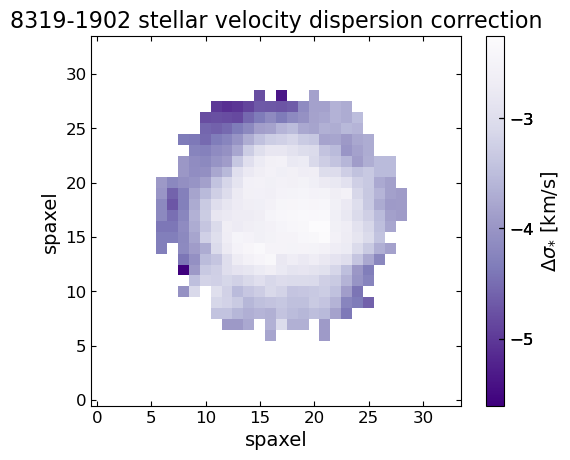

In [39]:
fig, ax = plt.subplots()

cbar_ticks = np.linspace(ma.min(mstar_sigma_corr-mstar_sigma), ma.max(mstar_sigma_corr-mstar_sigma), 11, dtype='int')
# ax.set_title(gal_ID + ' stellar velocity dispersion', fontsize=12)

vel_im = ax.imshow( mstar_sigma_corr-mstar_sigma, 
                    cmap='Purples_r', # 4h 
                    origin='lower', 
                    vmin=ma.min(mstar_sigma_corr-mstar_sigma), 
                    vmax=ma.max(mstar_sigma_corr-mstar_sigma))

cbar = plt.colorbar( vel_im, ax=ax, ticks=cbar_ticks)
cbar.ax.tick_params( direction='in', labelsize=12)
cbar.set_label(r'$\Delta \sigma_{*}$ [km/s]', fontsize=14) 

ax.tick_params( axis='both', direction='in', labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.set_xlabel('spaxel', fontsize=14)
ax.set_ylabel('spaxel', fontsize=14)
ax.set_title('8319-1902 stellar velocity dispersion correction', fontsize=16)


plt.savefig(plot_dir + gal_ID + '_stel_sigma_res.png', bbox_inches='tight', pad_inches=0)

## fig 6 manga /tng match

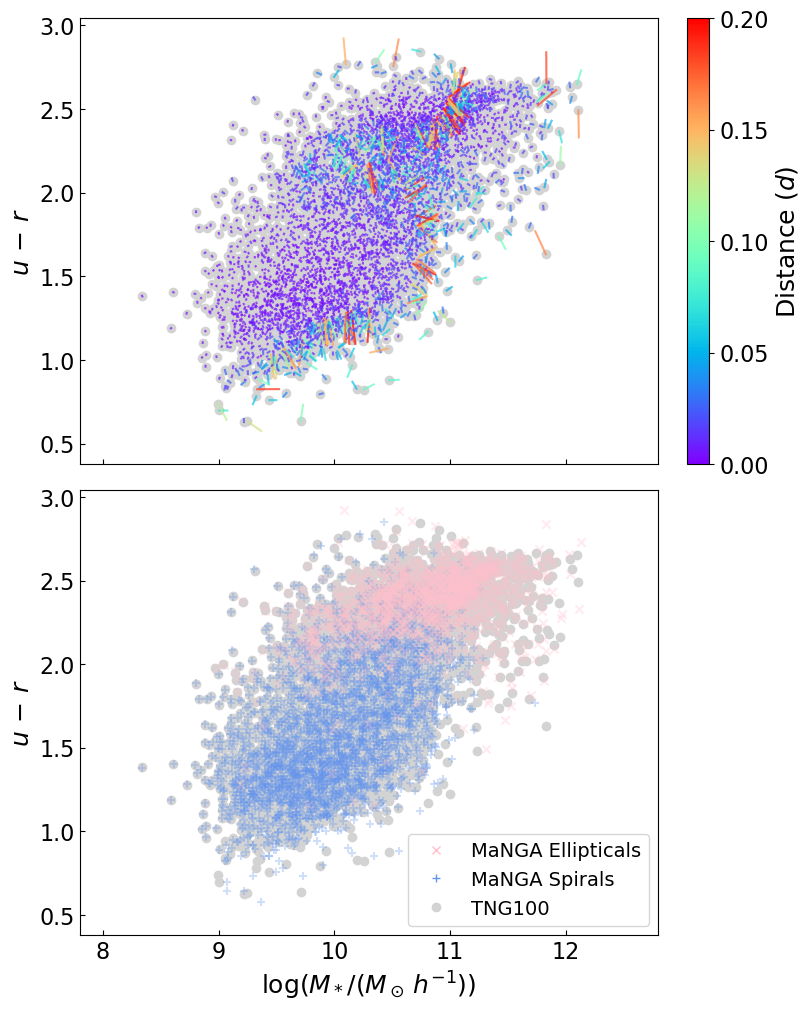

In [34]:
fig, ax = plt.subplots(2,1, figsize=(8,10), sharex=True, layout='compressed')
cmap = plt.get_cmap('rainbow')
ax[0].scatter(i_sample['illustris_Mstar_Sal'], i_sample['illustris_u_r'], marker='o', color='lightgrey')
for i in range(len(i_sample)):
    ax[0].plot([i_sample['sphd_M_star_h'][i],i_sample['illustris_Mstar_Sal'][i]],
                     [i_sample['nsa_u_r'][i],i_sample['illustris_u_r'][i]], 
                     alpha=0.7,color=cmap(i_sample['illustris_dist'][i]/0.2)
                    )
cbar = fig.colorbar(cm.ScalarMappable(norm=matplotlib.colors.Normalize(0, 0.2), cmap='rainbow'),
             ax=ax[0], orientation='vertical', label=r'distance ($d$)', ticks=[0,0.05,0.1,0.15,0.2])
cbar.set_label(r'Distance ($d$)', size=18)
ax[0].set_ylabel(r'$u\, -\, r$', size=18)
ax[1].set_ylabel(r'$u\, -\, r$', size=18)
ax[1].set_xlabel(r'$\log(M_*/(M_\odot\, h^{-1}))$', size=18)

ax[0].tick_params( axis='both', direction='in', labelsize=16)
ax[1].tick_params( axis='both', direction='in', labelsize=16)
cbar.ax.tick_params(labelsize=16) 


ax[1].scatter(i_sample['illustris_Mstar_Sal'], i_sample['illustris_u_r'], marker='o', color='lightgrey')
ax[1].scatter(i_sample[i_sample['spiral_mask']==1]['sphd_M_star_h'], i_sample[i_sample['spiral_mask']==1]['nsa_u_r'],
              marker='+', color='cornflowerblue', alpha=0.3)
ax[1].scatter(i_sample[i_sample['elliptical_mask']==1]['sphd_M_star_h'], i_sample[i_sample['elliptical_mask']==1]['nsa_u_r'],
              marker='x', color='pink', alpha=0.3)


legend_elements = [Line2D([0], [0], marker='x', color='w', label='MaNGA Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='+', color='w', label='MaNGA Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='TNG100',
                          markeredgecolor='lightgrey', markerfacecolor='lightgrey', markersize=6)]


ax[1].legend(handles=legend_elements,fontsize=14)
ax[1].set_xlim(7.8,12.8)
plt.savefig(plot_dir + '/TNGmatch/IllustrisTNG_matching.png', bbox_inches='tight')

## fig 7'manga/tng veff/mtot comparison

In [23]:
s_match = manga_sample[np.logical_and(manga_sample['spiral_mask'] == 1, manga_sample['illustris_match'] >= 0)]
e_match = manga_sample[np.logical_and(manga_sample['elliptical_mask'] == 1, manga_sample['illustris_match'] >= 0)]

In [24]:
mtot_comp_bins = np.linspace(np.min(e_match['Mvir']), np.max(e_match['Mvir'])+0.01, 8)
veff_comp_bins = np.linspace(np.min(e_match['v_eff']), np.max(e_match['v_eff'])+0.01, 8)

In [25]:
# ellipticals
mtot_comp_ctrs = []
tng_mtot = []
e_mtot_tng_bins = mtot_comp_bins
e_mtot_tng_bins = np.concatenate((mtot_comp_bins[:1], mtot_comp_bins[2:]))

indices = np.digitize(e_match['Mvir'], e_mtot_tng_bins, right=True)

for i in range(1,len(e_mtot_tng_bins)):
    
    tng_mtot.append(e_match['illustris_MR90'][indices==i])
    mtot_comp_ctrs.append(np.mean(e_match['Mvir'][indices==i]))


mtot_tng_avg, mtot_tng_sig = fit_to_gaussian(tng_mtot, plot_dir = plot_dir + '/TNGmatch/mtot_comp/', 
                                               plot_name='mtot_comp', xlab=r'$M_{\rm tot, sim}$',
                                        plot_bins=e_mtot_tng_bins, bin_lab=r'$M_{\rm tot, MaNGA}$')

# fit da lines

mtot_tng_popt, mtot_tng_pcov = curve_fit(lin_fit, mtot_comp_ctrs, 
                                       mtot_tng_avg, sigma=mtot_tng_sig)

print(mtot_tng_popt, np.sqrt(mtot_tng_pcov[0,0]), np.sqrt(mtot_tng_pcov[1,1]))

[0.96265371 0.45749898] 0.03280084283257527 0.3710527866331234


In [26]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/mtot_comp/data.txt', 'x')
f.write('e_mvir_centers \n')
f.write(str(mtot_comp_ctrs) + '\n')
f.write('e_mtot_avgs \n')
f.write(str(mtot_tng_avg)+ '\n')
f.write('e_mtot_sigs \n')
f.write(str(mtot_tng_sig)+ '\n')

f.write('slope \n')
f.write(str(mtot_tng_popt[0]) + ' +- ' + str(np.sqrt(mtot_tng_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(mtot_tng_popt[1]) + ' +- ' + str(np.sqrt(mtot_tng_pcov[1,1]))+ '\n')
f.close()



FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax//TNGmatch/mtot_comp/data.txt'

In [46]:
# ellipticals
veff_comp_ctrs = []
tng_veff = []
e_veff_tng_bins = np.concatenate((np.array([np.min(e_match['v_eff'])]), np.linspace(150,350,5), np.array([np.max(e_match['v_eff'])])))

indices = np.digitize(e_match['v_eff'], e_veff_tng_bins, right=True)

for i in range(1,len(e_veff_tng_bins)):
    
    tng_veff.append(e_match['illustris_Vmax'][indices==i])
    veff_comp_ctrs.append(np.mean(e_match['v_eff'][indices==i]))


veff_tng_avg, veff_tng_sig = fit_to_gaussian(tng_veff, plot_dir = plot_dir + '/TNGmatch/veff_comp/', 
                                               plot_name='veff_comp', xlab=r'$V_{\rm max}$',
                                        plot_bins=e_veff_tng_bins, bin_lab=r'$V_{\rm eff}$')

# fit da lines

veff_tng_popt, veff_tng_pcov = curve_fit(lin_fit, veff_comp_ctrs, 
                                       veff_tng_avg, sigma=veff_tng_sig)

print(veff_tng_popt, np.sqrt(veff_tng_pcov[0,0]), np.sqrt(veff_tng_pcov[1,1]))

[ 0.72905163 62.96514964] 0.0547152148611426 12.950799236071486


In [27]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/veff_comp/data.txt', 'x')
f.write('e_veff_centers \n')
f.write(str(veff_comp_ctrs) + '\n')
f.write('e_vmax_avgs \n')
f.write(str(veff_tng_avg)+ '\n')
f.write('e_vmax_sigs \n')
f.write(str(veff_tng_sig)+ '\n')

f.write('slope \n')
f.write(str(veff_tng_popt[0]) + ' +- ' + str(np.sqrt(veff_tng_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(veff_tng_popt[1]) + ' +- ' + str(np.sqrt(veff_tng_pcov[1,1]))+ '\n')
f.close()

FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax//TNGmatch/veff_comp/data.txt'

In [28]:
s_mtot_comp_bins = np.linspace(np.min(s_match['M_R90']), np.max(s_match['M_R90'])+0.01, 12)
s_veff_comp_bins = np.linspace(np.min(s_match['v_max']), np.max(s_match['v_max'])+0.01, 12)

In [48]:
s_mtot_comp_ctrs = []
s_tng_mtot = []
s_mtot_tng_bins = s_mtot_comp_bins
s_mtot_tng_bins = np.concatenate((s_mtot_comp_bins[:1], s_mtot_comp_bins[4:-3], s_mtot_comp_bins[-1:]))

indices = np.digitize(s_match['M_R90'], s_mtot_tng_bins, right=True)

for i in range(1,len(s_mtot_tng_bins)):
    
    s_tng_mtot.append(s_match['illustris_MR90'][indices==i])
    s_mtot_comp_ctrs.append(np.mean(s_match['M_R90'][indices==i]))


s_mtot_tng_avg, s_mtot_tng_sig = fit_to_gaussian(s_tng_mtot, plot_dir = plot_dir + '/TNGmatch/s_mtot_comp/', 
                                               plot_name='mtot_comp', xlab=r'$M_{\rm tot, sim}$',
                                        plot_bins=s_mtot_tng_bins, bin_lab=r'$M_{\rm tot, MaNGA}$')

# fit da lines

s_mtot_tng_popt, s_mtot_tng_pcov = curve_fit(lin_fit, s_mtot_comp_ctrs, 
                                       s_mtot_tng_avg, sigma=s_mtot_tng_sig)

print(s_mtot_tng_popt, np.sqrt(s_mtot_tng_pcov[0,0]), np.sqrt(s_mtot_tng_pcov[1,1]))

[0.65710425 3.61898975] 0.08137782745616283 0.8554295515267657


In [30]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/s_mtot_comp/data.txt', 'x')
f.write('s_mr90_centers \n')
f.write(str(s_mtot_comp_ctrs) + '\n')
f.write('s_mtot_avgs \n')
f.write(str(s_mtot_tng_avg)+ '\n')
f.write('s_mtot_sigs \n')
f.write(str(s_mtot_tng_sig)+ '\n')

f.write('slope \n')
f.write(str(s_mtot_tng_popt[0]) + ' +- ' + str(np.sqrt(s_mtot_tng_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(s_mtot_tng_popt[1]) + ' +- ' + str(np.sqrt(s_mtot_tng_pcov[1,1]))+ '\n')
f.close()



FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax//TNGmatch/s_mtot_comp/data.txt'

In [49]:
# spirals
s_veff_comp_ctrs = []
s_tng_veff = []
s_veff_tng_bins = s_veff_comp_bins
s_veff_tng_bins = np.concatenate((np.linspace(0, 400, 7), np.array([957])))

indices = np.digitize(s_match['v_max'], s_veff_tng_bins, right=True)

for i in range(1,len(s_veff_tng_bins)):
    
    s_tng_veff.append(s_match['illustris_Vmax'][indices==i])
    s_veff_comp_ctrs.append(np.mean(s_match['v_max'][indices==i]))


s_veff_tng_avg, s_veff_tng_sig = fit_to_gaussian(s_tng_veff, plot_dir = plot_dir + '/TNGmatch/s_veff_comp/', 
                                               plot_name='veff_comp', xlab=r'$V_{\rm max}$',
                                        plot_bins=s_veff_tng_bins, bin_lab=r'$V(R_{90})$')

# fit da lines

s_veff_tng_popt, s_veff_tng_pcov = curve_fit(lin_fit, s_veff_comp_ctrs, 
                                       s_veff_tng_avg, sigma=s_veff_tng_sig)

# print(veff_tng_popt, np.sqrt(veff_tng_pcov[0,0]), np.sqrt(veff_tng_pcov[1,1]))

In [50]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/s_veff_comp/data.txt', 'x')
f.write('s_vr90_centers \n')
f.write(str(s_veff_comp_ctrs) + '\n')
f.write('s_vmax_avgs \n')
f.write(str(s_veff_tng_avg)+ '\n')
f.write('s_vmax_sigs \n')
f.write(str(s_veff_tng_sig)+ '\n')

f.write('slope \n')
f.write(str(s_veff_tng_popt[0]) + ' +- ' + str(np.sqrt(s_veff_tng_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(s_veff_tng_popt[1]) + ' +- ' + str(np.sqrt(s_veff_tng_pcov[1,1]))+ '\n')
f.close()

FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax//TNGmatch/s_veff_comp/data.txt'

### fit the mass difference gaussians

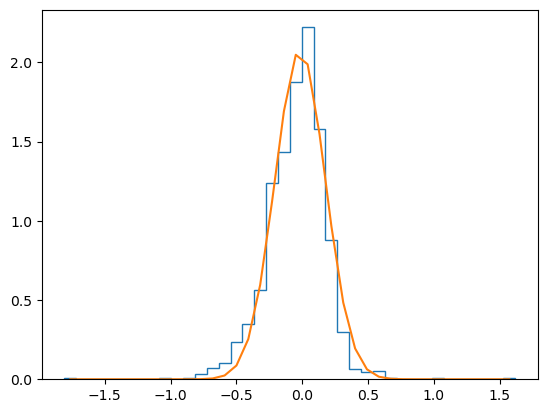

In [51]:
# fit mass diff gaussians
counts, bins = np.histogram(e_match['Mvir']- e_match['illustris_MR90'], bins=int(np.sqrt(len(e_match))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
e_m_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(e_match['Mvir']- e_match['illustris_MR90']),
                               np.std(e_match['Mvir']- e_match['illustris_MR90'])])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, e_m_params[0], e_m_params[1]))
# s_m_params = stats.norm.fit(s_match['M_R90']- s_match['illustris_MR90'])
# #fit v diff gaussians
# e_v_params = stats.norm.fit(e_match['v_eff'] - e_match['illustris_Vmax'])
# s_v_params = stats.norm.fit(s_match['V_R90'] - s_match['illustris_Vmax'])

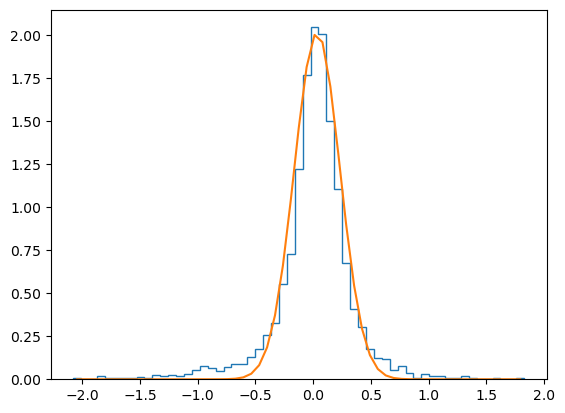

In [52]:
counts, bins = np.histogram(s_match['M_R90']- s_match['illustris_MR90'], bins=int(np.sqrt(len(s_match))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
s_m_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(s_match['M_R90']- s_match['illustris_MR90']),
                                np.std(s_match['M_R90']- s_match['illustris_MR90'])])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, s_m_params[0], s_m_params[1]))

### vel diff gaussians

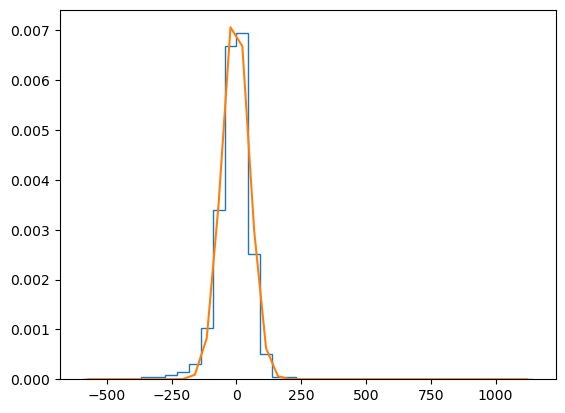

In [53]:
counts, bins = np.histogram(e_match['v_eff'] - e_match['illustris_Vmax'],bins=int(np.sqrt(len(e_match))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
e_v_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(e_match['v_eff'] - e_match['illustris_Vmax']),
                               np.std(e_match['v_eff'] - e_match['illustris_Vmax'])])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, e_v_params[0], e_v_params[1]))

(-400.0, 400.0)

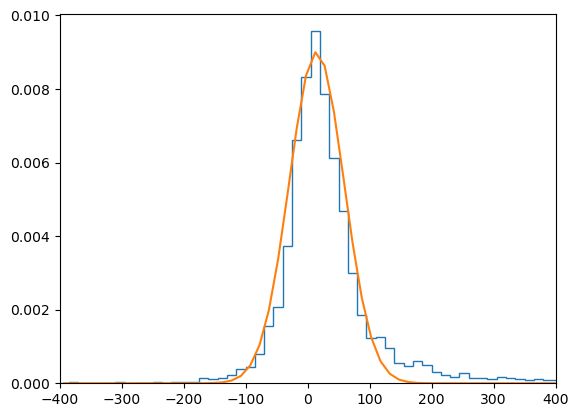

In [54]:
# counts, bins = np.histogram(s_match['v_max'] - s_match['illustris_Vmax'],bins=int(np.sqrt(len(s_match))+1), density=True)
counts, bins = np.histogram(s_match['v_max'] - s_match['illustris_Vmax'],bins=np.arange(-400,5100, 15), density=True)

bin_ctrs = (bins[1:] + bins[:-1])/2
s_v_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(s_match['v_max'] - s_match['illustris_Vmax']),
                               np.std(s_match['v_max'] - s_match['illustris_Vmax'])])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, s_v_params[0], s_v_params[1]))
plt.xlim(-400,400)

### plot

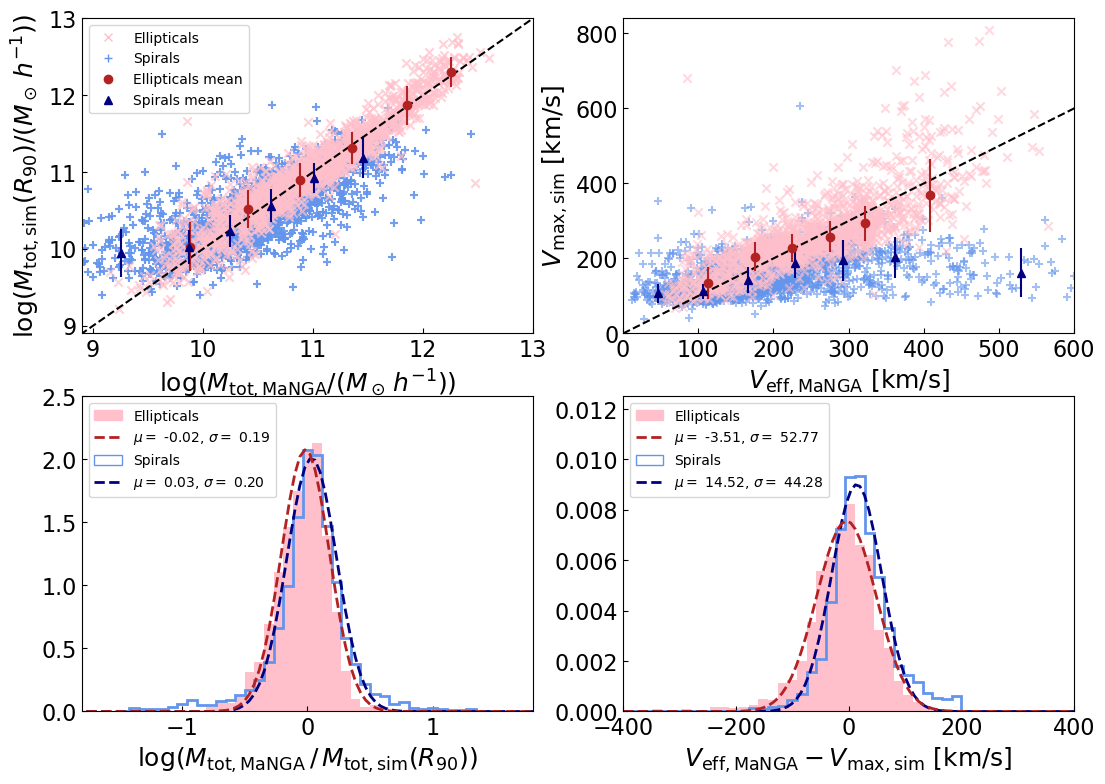

In [55]:
fig, ax = plt.subplots(2,2,
                       # sharex=True, 
                       # sharey='row', 
                       figsize=(12.8,9))


# total mass
ax[0,0].scatter(s_match['M_R90'], s_match['illustris_MR90'], color='cornflowerblue', marker='+', alpha=0.7)
ax[0,0].scatter(s_match['M_R90'], s_match['illustris_MR90'], color='cornflowerblue', marker='+', alpha=0.7)
ax[0,0].scatter(e_match['Mvir'], e_match['illustris_MR90'], color='pink', marker='x', alpha=0.7)

ax[0,0].set_xlim(8.9,13)
ax[0,0].set_ylim(8.9,13)
ax[0,0].plot([8,13], [8,13], color='k', linestyle='--')

ax[0,0].set_xlabel(r'$\log(M_{\rm tot, MaNGA}/(M_\odot\, h^{-1}))$', fontsize=18)
ax[0,0].set_ylabel(r'$\log(M_{\rm tot, sim}(R_{90})/(M_\odot\, h^{-1}))$', fontsize=18)


# add means
ax[0,0].errorbar(mtot_comp_ctrs,mtot_tng_avg, yerr = mtot_tng_sig, marker='o', color='firebrick', linestyle='none')
ax[0,0].errorbar(s_mtot_comp_ctrs, s_mtot_tng_avg, yerr=s_mtot_tng_sig, marker='^', color='navy', linestyle='none')



ax[1,0].hist(e_match['Mvir']- e_match['illustris_MR90'], bins=np.linspace(-1.5,1.5,40), color='pink',  
             #weights=1/len(e_match) * np.ones(len(e_match))
            density=True
            )
ax[1,0].hist(s_match['M_R90']- s_match['illustris_MR90'], bins=np.linspace(-1.5,1.5,40), color='cornflowerblue', 
             #weights=1/len(s_match) * np.ones(len(s_match)),
             density=True,
            histtype='step', linewidth=2)
ax[1,0].set_xlabel(r'$\log(M_{\rm tot, MaNGA}\, /\, M_{\rm tot, sim}(R_{90}))$', fontsize=18)
ax[1,0].set_xlim(-1.8,1.8)

ax[1,0].plot(np.linspace(-2,2,100), gaussian(np.linspace(-2,2,100), s_m_params[0], s_m_params[1]), linestyle='--', color='navy',
            linewidth=2)
ax[1,0].plot(np.linspace(-2,2,100), gaussian(np.linspace(-2,2,100), e_m_params[0], e_m_params[1]), linestyle='--', color='firebrick',
            linewidth=2)


# rot vel
ax[0,1].scatter(s_match['v_max'], s_match['illustris_Vmax'], marker='+', color='cornflowerblue', alpha=0.6)
ax[0,1].scatter(e_match['v_eff'], e_match['illustris_Vmax'], marker='x', color='pink', alpha=0.6)

ax[0,1].plot([0,800],[0,800], color='k', linestyle='--')
ax[0,1].set_xlim(0,600)
ax[0,1].set_ylim(0,840)
ax[0,1].set_xlabel(r'$V_{\rm eff, MaNGA}$ [km/s]', fontsize=18)
ax[0,1].set_ylabel(r'$V_{\rm max, sim}$ [km/s]', fontsize=18)

# add means
ax[0,1].errorbar(veff_comp_ctrs, veff_tng_avg, yerr=veff_tng_sig, marker='o', color='firebrick', linestyle='none')
ax[0,1].errorbar(s_veff_comp_ctrs, s_veff_tng_avg, yerr=s_veff_tng_sig, marker='^', color='navy', linestyle='none')


ax[1,1].hist(e_match['v_eff'] - e_match['illustris_Vmax'], bins=np.linspace(-400,200,36), color='pink', 
            #weights=1/len(e_match) * np.ones(len(e_match))
            density=True)
ax[1,1].hist(s_match['v_max'] - s_match['illustris_Vmax'], bins=np.linspace(-400,200,36), color='cornflowerblue', 
             #weights=1/len(s_match) * np.ones(len(s_match)),
             density=True,
            histtype='step', linewidth=2)


ax[1,1].plot(np.linspace(-400,400,100), gaussian(np.linspace(-400,400,100), s_v_params[0], s_v_params[1]), linestyle='--', color='navy',
            linewidth=2)
ax[1,1].plot(np.linspace(-400,400,100), gaussian(np.linspace(-400,400,100), e_v_params[0], e_v_params[1]), linestyle='--', color='firebrick',
            linewidth=2)

ax[1,1].set_xlabel(r'$V_{\rm eff, MaNGA} - V_{\rm max, sim}$ [km/s]', fontsize=18)
ax[1,1].set_xlim(-400,400)



for i in range(2):
    for j in range(2):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)

# fig.subplots_adjust(wspace=0.1, hspace=0.1)
# fig.tight_layout()


legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                   Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)
                  ]
ax[0,0].legend(handles=legend_elements,)




legend_elements = [Patch(facecolor='pink', edgecolor='pink',
                         label=fr'Ellipticals'),
                   Line2D([0], [0], marker='none', color='firebrick', 
                          label=fr'$\mu =$ {e_m_params[0]:.2f}, $\sigma =$ {e_m_params[1]:.2f}',
                          linestyle='--', linewidth=2),
                  Patch(facecolor='none', edgecolor='cornflowerblue',
                         label=fr'Spirals'),
                Line2D([0], [0], marker='none', color='navy', 
                          label=fr'$\mu =$ {s_m_params[0]:.2f}, $\sigma =$ {s_m_params[1]:.2f}',
                          linestyle='--', linewidth=2)]
                  
ax[1,0].legend(handles=legend_elements,loc='upper left')
ax[1,0].set_ylim(0,2.5)

legend_elements = [Patch(facecolor='pink', edgecolor='pink',
                       label=fr'Ellipticals'),
                    Line2D([0], [0], marker='none', color='firebrick', 
                          label=fr'$\mu =$ {e_v_params[0]:.2f}, $\sigma =$ {e_v_params[1]:.2f}',
                          linestyle='--', linewidth=2),
                  Patch(facecolor='none', edgecolor='cornflowerblue',
                         label=fr'Spirals'),
                Line2D([0], [0], marker='none', color='navy', 
                          label=fr'$\mu =$ {s_v_params[0]:.2f}, $\sigma =$ {s_v_params[1]:.2f}',
                          linestyle='--', linewidth=2)]
                  
ax[1,1].legend(handles=legend_elements,loc='upper left')
ax[1,1].set_ylim(0,0.0125)

plt.savefig(plot_dir + 'TNGmatch/mass_vel_comparison_spirals_2x2_refit.png', bbox_inches='tight')


### top plots binned in opposite direction

In [37]:
mtot_comp_bins = np.linspace(np.min(e_match['illustris_MR90']), np.max(e_match['illustris_MR90'])+0.01, 8)
veff_comp_bins = np.linspace(np.min(e_match['illustris_Vmax']), np.max(e_match['illustris_Vmax'])+0.01, 8)

In [47]:
# ellipticals
mtot_comp_ctrs = []
tng_mtot = []
e_mtot_tng_bins = mtot_comp_bins
e_mtot_tng_bins = np.concatenate((mtot_comp_bins[:1], mtot_comp_bins[2:]))

indices = np.digitize(e_match['illustris_MR90'], e_mtot_tng_bins, right=True)

for i in range(1,len(e_mtot_tng_bins)):
    
    tng_mtot.append(e_match['Mvir'][indices==i])
    mtot_comp_ctrs.append(np.mean(e_match['illustris_MR90'][indices==i]))


mtot_tng_avg, mtot_tng_sig = fit_to_gaussian(tng_mtot, plot_dir = plot_dir + '/TNGmatch/mtot_comp_flip/', 
                                               plot_name='mtot_comp', xlab=r'$M_{\rm tot, sim}$',
                                        plot_bins=e_mtot_tng_bins, bin_lab=r'$M_{\rm tot, MaNGA}$')

# fit da lines

mtot_tng_popt, mtot_tng_pcov = curve_fit(lin_fit, mtot_comp_ctrs, 
                                       mtot_tng_avg, sigma=mtot_tng_sig)

print(mtot_tng_popt, np.sqrt(mtot_tng_pcov[0,0]), np.sqrt(mtot_tng_pcov[1,1]))

[0.90435846 1.0148629 ] 0.03617528995627889 0.4180698488441871


In [71]:
# ellipticals
veff_comp_ctrs = []
tng_veff = []
# e_veff_tng_bins = np.concatenate((np.array([np.min(e_match['illustris_Vmax'])]), np.linspace(150,350,5), np.array([np.max(e_match['illustris_Vmax'])])))
e_veff_tng_bins = np.concatenate((np.linspace(np.min(e_match['illustris_Vmax']),400,7), np.array([np.max(e_match['illustris_Vmax'])])))

indices = np.digitize(e_match['illustris_Vmax'], e_veff_tng_bins, right=True)

for i in range(1,len(e_veff_tng_bins)):
    
    tng_veff.append(e_match['v_eff'][indices==i])
    veff_comp_ctrs.append(np.mean(e_match['illustris_Vmax'][indices==i]))


veff_tng_avg, veff_tng_sig = fit_to_gaussian(tng_veff, plot_dir = plot_dir + '/TNGmatch/veff_comp_flip/', 
                                               plot_name='veff_comp', xlab=r'$V_{\rm max}$',
                                        plot_bins=e_veff_tng_bins, bin_lab=r'$V_{\rm eff}$')

# fit da lines

veff_tng_popt, veff_tng_pcov = curve_fit(lin_fit, veff_comp_ctrs, 
                                       veff_tng_avg, sigma=veff_tng_sig)

print(veff_tng_popt, np.sqrt(veff_tng_pcov[0,0]), np.sqrt(veff_tng_pcov[1,1]))

[ 0.84322356 22.17617547] 0.06925993230377252 17.43955556272523


In [50]:
s_mtot_comp_bins = np.linspace(np.min(s_match['illustris_MR90']), np.max(s_match['illustris_MR90'])+0.01, 12)
s_veff_comp_bins = np.linspace(np.min(s_match['illustris_Vmax']), np.max(s_match['illustris_Vmax'])+0.01, 12)

In [52]:
s_mtot_comp_ctrs = []
s_tng_mtot = []
s_mtot_tng_bins = s_mtot_comp_bins
s_mtot_tng_bins = np.concatenate((s_mtot_comp_bins[:1], s_mtot_comp_bins[4:-2], s_mtot_comp_bins[-1:]))

indices = np.digitize(s_match['illustris_MR90'], s_mtot_tng_bins, right=True)

for i in range(1,len(s_mtot_tng_bins)):
    
    s_tng_mtot.append(s_match['M_R90'][indices==i])
    s_mtot_comp_ctrs.append(np.mean(s_match['illustris_MR90'][indices==i]))


s_mtot_tng_avg, s_mtot_tng_sig = fit_to_gaussian(s_tng_mtot, plot_dir = plot_dir + '/TNGmatch/s_mtot_comp_flip/', 
                                               plot_name='mtot_comp', xlab=r'$M_{\rm tot, sim}$',
                                        plot_bins=s_mtot_tng_bins, bin_lab=r'$M_{\rm tot, MaNGA}$')

# fit da lines

s_mtot_tng_popt, s_mtot_tng_pcov = curve_fit(lin_fit, s_mtot_comp_ctrs, 
                                       s_mtot_tng_avg, sigma=s_mtot_tng_sig)

print(s_mtot_tng_popt, np.sqrt(s_mtot_tng_pcov[0,0]), np.sqrt(s_mtot_tng_pcov[1,1]))

[0.96462917 0.40670367] 0.013644349955368753 0.1460636734950706


In [56]:
# spirals
s_veff_comp_ctrs = []
s_tng_veff = []
s_veff_tng_bins = s_veff_comp_bins
s_veff_tng_bins = np.linspace(0,1000,7)

indices = np.digitize(s_match['illustris_Vmax'], s_veff_comp_bins, right=True)

for i in range(1,len(s_veff_tng_bins)):
    
    s_tng_veff.append(s_match['v_max'][indices==i])
    s_veff_comp_ctrs.append(np.mean(s_match['illustris_Vmax'][indices==i]))


s_veff_tng_avg, s_veff_tng_sig = fit_to_gaussian(s_tng_veff, plot_dir = plot_dir + '/TNGmatch/s_veff_comp_flip/', 
                                               plot_name='veff_comp', xlab=r'$V_{\rm max}$',
                                        plot_bins=s_veff_tng_bins, bin_lab=r'$V(R_{90})$')

# fit da lines

s_veff_tng_popt, s_veff_tng_pcov = curve_fit(lin_fit, s_veff_comp_ctrs, 
                                       s_veff_tng_avg, sigma=s_veff_tng_sig)

print(veff_tng_popt, np.sqrt(veff_tng_pcov[0,0]), np.sqrt(veff_tng_pcov[1,1]))

[ 0.57022082 81.46339695] 0.10988288902049284 43.511297374319774


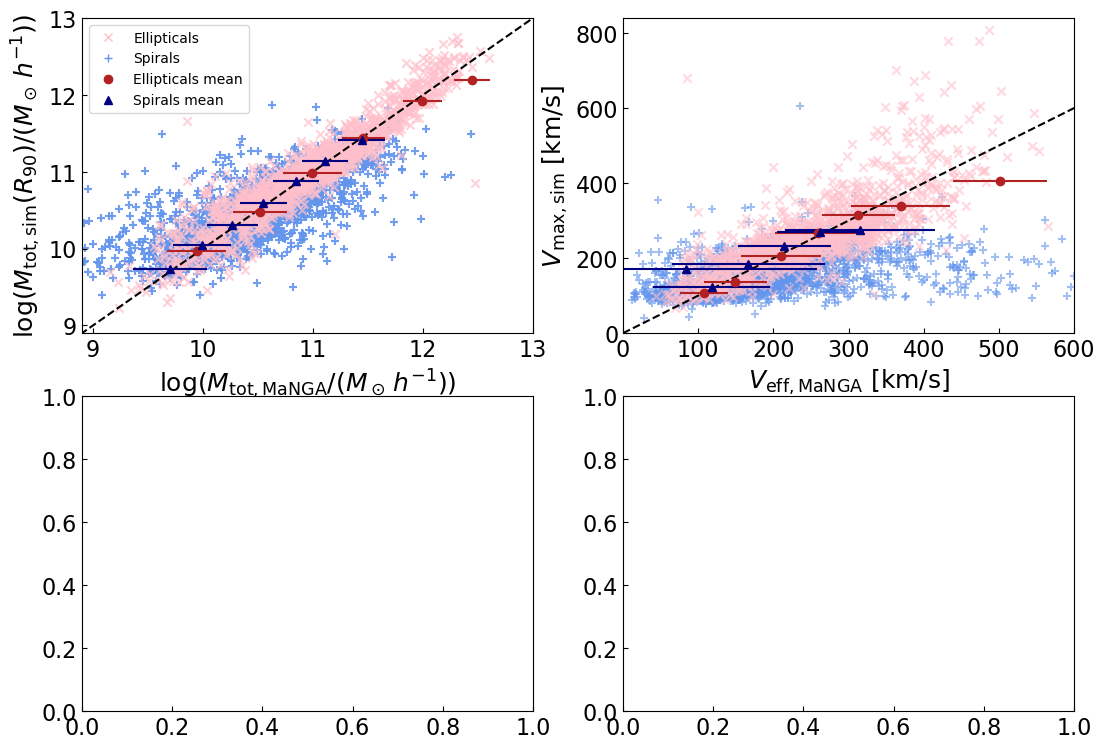

In [73]:
fig, ax = plt.subplots(2,2,
                       # sharex=True, 
                       # sharey='row', 
                       figsize=(12.8,9))


# total mass
ax[0,0].scatter(s_match['M_R90'], s_match['illustris_MR90'], color='cornflowerblue', marker='+', alpha=0.7)
ax[0,0].scatter(s_match['M_R90'], s_match['illustris_MR90'], color='cornflowerblue', marker='+', alpha=0.7)
ax[0,0].scatter(e_match['Mvir'], e_match['illustris_MR90'], color='pink', marker='x', alpha=0.7)

ax[0,0].set_xlim(8.9,13)
ax[0,0].set_ylim(8.9,13)
ax[0,0].plot([8,13], [8,13], color='k', linestyle='--')

ax[0,0].set_xlabel(r'$\log(M_{\rm tot, MaNGA}/(M_\odot\, h^{-1}))$', fontsize=18)
ax[0,0].set_ylabel(r'$\log(M_{\rm tot, sim}(R_{90})/(M_\odot\, h^{-1}))$', fontsize=18)


# add means
ax[0,0].errorbar(mtot_comp_ctrs,mtot_tng_avg, xerr = mtot_tng_sig, marker='o', color='firebrick', linestyle='none')
ax[0,0].errorbar(s_mtot_comp_ctrs, s_mtot_tng_avg, xerr=s_mtot_tng_sig, marker='^', color='navy', linestyle='none')



# ax[1,0].hist(e_match['Mvir']- e_match['illustris_MR90'], bins=np.linspace(-1.5,1.5,40), color='pink',  
#              #weights=1/len(e_match) * np.ones(len(e_match))
#             density=True
#             )
# ax[1,0].hist(s_match['M_R90']- s_match['illustris_MR90'], bins=np.linspace(-1.5,1.5,40), color='cornflowerblue', 
#              #weights=1/len(s_match) * np.ones(len(s_match)),
#              density=True,
#             histtype='step', linewidth=2)
# ax[1,0].set_xlabel(r'$\log(M_{\rm tot, MaNGA}\, /\, M_{\rm tot, sim}(R_{90}))$', fontsize=18)
# ax[1,0].set_xlim(-1.8,1.8)

# ax[1,0].plot(np.linspace(-2,2,100), gaussian(np.linspace(-2,2,100), s_m_params[0], s_m_params[1]), linestyle='--', color='navy',
#             linewidth=2)
# ax[1,0].plot(np.linspace(-2,2,100), gaussian(np.linspace(-2,2,100), e_m_params[0], e_m_params[1]), linestyle='--', color='firebrick',
#             linewidth=2)


# rot vel
ax[0,1].scatter(s_match['v_max'], s_match['illustris_Vmax'], marker='+', color='cornflowerblue', alpha=0.6)
ax[0,1].scatter(e_match['v_eff'], e_match['illustris_Vmax'], marker='x', color='pink', alpha=0.6)

ax[0,1].plot([0,800],[0,800], color='k', linestyle='--')
ax[0,1].set_xlim(0,600)
ax[0,1].set_ylim(0,840)
ax[0,1].set_xlabel(r'$V_{\rm eff, MaNGA}$ [km/s]', fontsize=18)
ax[0,1].set_ylabel(r'$V_{\rm max, sim}$ [km/s]', fontsize=18)

# add means
ax[0,1].errorbar(veff_comp_ctrs, veff_tng_avg, xerr=veff_tng_sig, marker='o', color='firebrick', linestyle='none')
ax[0,1].errorbar(s_veff_comp_ctrs, s_veff_tng_avg, xerr=s_veff_tng_sig, marker='^', color='navy', linestyle='none')


# ax[1,1].hist(e_match['v_eff'] - e_match['illustris_Vmax'], bins=np.linspace(-400,200,36), color='pink', 
#             #weights=1/len(e_match) * np.ones(len(e_match))
#             density=True)
# ax[1,1].hist(s_match['v_max'] - s_match['illustris_Vmax'], bins=np.linspace(-400,200,36), color='cornflowerblue', 
#              #weights=1/len(s_match) * np.ones(len(s_match)),
#              density=True,
#             histtype='step', linewidth=2)


# ax[1,1].plot(np.linspace(-400,400,100), gaussian(np.linspace(-400,400,100), s_v_params[0], s_v_params[1]), linestyle='--', color='navy',
#             linewidth=2)
# ax[1,1].plot(np.linspace(-400,400,100), gaussian(np.linspace(-400,400,100), e_v_params[0], e_v_params[1]), linestyle='--', color='firebrick',
#             linewidth=2)

# ax[1,1].set_xlabel(r'$V_{\rm eff, MaNGA} - V_{\rm max, sim}$ [km/s]', fontsize=18)
# ax[1,1].set_xlim(-400,400)



for i in range(2):
    for j in range(2):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)

# fig.subplots_adjust(wspace=0.1, hspace=0.1)
# fig.tight_layout()


legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                   Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)
                  ]
ax[0,0].legend(handles=legend_elements,)




# legend_elements = [Patch(facecolor='pink', edgecolor='pink',
#                          label=fr'Ellipticals'),
#                    Line2D([0], [0], marker='none', color='firebrick', 
#                           label=fr'$\mu =$ {e_m_params[0]:.2f}, $\sigma =$ {e_m_params[1]:.2f}',
#                           linestyle='--', linewidth=2),
#                   Patch(facecolor='none', edgecolor='cornflowerblue',
#                          label=fr'Spirals'),
#                 Line2D([0], [0], marker='none', color='navy', 

#                           label=fr'$\mu =$ {s_m_params[0]:.2f}, $\sigma =$ {s_m_params[1]:.2f}',
#                           linestyle='--', linewidth=2)]
                  
# ax[1,0].legend(handles=legend_elements,loc='upper left')
# ax[1,0].set_ylim(0,2.5)

# legend_elements = [Patch(facecolor='pink', edgecolor='pink',
#                        label=fr'Ellipticals'),
#                     Line2D([0], [0], marker='none', color='firebrick', 
#                           label=fr'$\mu =$ {e_v_params[0]:.2f}, $\sigma =$ {e_v_params[1]:.2f}',
#                           linestyle='--', linewidth=2),
#                   Patch(facecolor='none', edgecolor='cornflowerblue',
#                          label=fr'Spirals'),
#                 Line2D([0], [0], marker='none', color='navy', 
#                           label=fr'$\mu =$ {s_v_params[0]:.2f}, $\sigma =$ {s_v_params[1]:.2f}',
#                           linestyle='--', linewidth=2)]
                  
# ax[1,1].legend(handles=legend_elements,loc='upper left')
# ax[1,1].set_ylim(0,0.0125)

# plt.savefig(plot_dir + 'TNGmatch/mass_vel_comparison_spirals_2x2_refit.png', bbox_inches='tight')


### testing spiral params as function of match dist

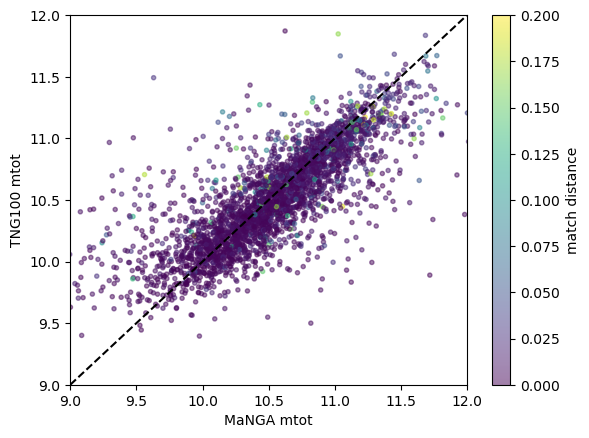

In [46]:
plt.scatter(s_match['M_R90'], s_match['illustris_MR90'], c=s_match['illustris_dist'],marker='.', vmin=0, vmax=0.2, alpha=0.5)
plt.colorbar(label='match distance')
plt.xlim(9,12)
plt.ylim(9,12)
plt.xlabel('MaNGA mtot')
plt.ylabel('TNG100 mtot')
plt.plot([9,12],[9,12], color='k', linestyle='--')

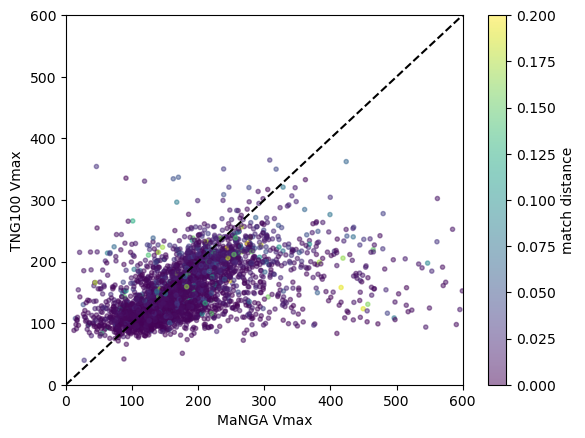

In [45]:
plt.scatter(s_match['v_max'], s_match['illustris_Vmax'], c=s_match['illustris_dist'],marker='.', vmin=0, vmax=0.2, alpha=0.5)
plt.colorbar(label='match distance')
plt.xlim(0,600)
plt.ylim(0,600)
plt.xlabel('MaNGA Vmax')
plt.ylabel('TNG100 Vmax')
plt.plot([0,600],[0,600], color='k', linestyle='--')

## fig 8 mstar vs mtot for manga/tng

In [59]:
min_mstar = np.min([np.min(s_match['sphd_M_star_h']), np.min(e_match['sphd_M_star_h']),
                    np.min(s_match['illustris_Mstar_Sal']), np.max(e_match['illustris_Mstar_Sal'])])
max_mstar = np.max([np.max(s_match['sphd_M_star_h']), np.max(e_match['sphd_M_star_h']),
                    np.max(s_match['illustris_Mstar_Sal']), np.max(e_match['illustris_Mstar_Sal'])])

mstar_bins = np.linspace(min_mstar, max_mstar+0.01, 15)

### manga ellipticals

In [60]:
# ellipticals
e_mstar_ctrs = []
e_mtot = []
e_mstar_bins = mstar_bins
e_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[8:]))

indices = np.digitize(e_match['sphd_M_star_h'], e_mstar_bins, right=True)

for i in range(1,len(e_mstar_bins)):
    
    e_mtot.append(e_match['Mvir'][indices==i])
    e_mstar_ctrs.append(np.mean(e_match['sphd_M_star_h'][indices==i]))


e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir + '/TNGmatch/e_mtot_mstar_manga/', plot_name='e_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                        plot_bins=e_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mstar_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[ 1.10558032 -0.92344885] 0.05201354810699796 0.5497673200682766


In [61]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/e_mtot_mstar_manga/data.txt', 'x')
f.write('e_mstar_centers \n')
f.write(str(e_mstar_ctrs) + '\n')
f.write('e_mstar_mtot_avgs \n')
f.write(str(e_mtot_avg)+ '\n')
f.write('e_mstar_mtot_sigs \n')
f.write(str(e_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(e_mtot_popt[0]) + ' +- ' + str(np.sqrt(e_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(e_mtot_popt[1]) + ' +- ' + str(np.sqrt(e_mtot_pcov[1,1]))+ '\n')
f.close()



### tng ellipticals

In [62]:
# ellipticals
ie_mstar_ctrs = []
ie_mtot = []
ie_mstar_bins = mstar_bins
ie_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[8:]))

indices = np.digitize(e_match['illustris_Mstar_Sal'], ie_mstar_bins, right=True)

for i in range(1,len(ie_mstar_bins)):
    
    ie_mtot.append(e_match['illustris_MR90'][indices==i])
    ie_mstar_ctrs.append(np.mean(e_match['illustris_Mstar_Sal'][indices==i]))


ie_mtot_avg, ie_mtot_sig = fit_to_gaussian(ie_mtot, plot_dir = plot_dir + '/TNGmatch/e_mtot_mstar_tng/', plot_name='e_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                          plot_bins=e_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

ie_mtot_popt, ie_mtot_pcov = curve_fit(lin_fit, ie_mstar_ctrs, 
                                       ie_mtot_avg, sigma=ie_mtot_sig)

print(ie_mtot_popt, np.sqrt(ie_mtot_pcov[0,0]), np.sqrt(ie_mtot_pcov[1,1]))

[ 1.18223722 -1.68781654] 0.06325374806047251 0.6830638607142911


In [63]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/e_mtot_mstar_tng/data.txt', 'x')
f.write('ie_mstar_centers \n')
f.write(str(ie_mstar_ctrs) + '\n')
f.write('ie_mstar_mtot_avgs \n')
f.write(str(ie_mtot_avg)+ '\n')
f.write('ie_mstar_mtot_sigs \n')
f.write(str(ie_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(ie_mtot_popt[0]) + ' +- ' + str(np.sqrt(ie_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(ie_mtot_popt[1]) + ' +- ' + str(np.sqrt(ie_mtot_pcov[1,1]))+ '\n')
f.close()


### manga spiral

In [88]:
# spirals
s_mstar_ctrs = []
s_mtot = []
s_mstar_bins = mstar_bins
s_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[7:-3], mstar_bins[-1:]))

indices = np.digitize(s_match['sphd_M_star_h'], s_mstar_bins, right=True)

for i in range(1,len(s_mstar_bins)):
    
    s_mtot.append(s_match['M_R90'][indices==i])
    s_mstar_ctrs.append(np.mean(s_match['sphd_M_star_h'][indices==i]))


s_mtot_avg, s_mtot_sig = fit_to_gaussian(s_mtot, plot_dir = plot_dir + '/TNGmatch/s_mtot_mstar_manga/refit/', plot_name='s_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                        plot_bins=s_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

s_mtot_popt, s_mtot_pcov = curve_fit(lin_fit, s_mstar_ctrs, 
                                       s_mtot_avg, sigma=s_mtot_sig)

print(s_mtot_popt, np.sqrt(s_mtot_pcov[0,0]), np.sqrt(s_mtot_pcov[1,1]))

[0.75139599 3.05101749] 0.04743136425529463 0.48425543935835175


In [89]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/s_mtot_mstar_manga/refit/data.txt', 'x')
f.write('s_mstar_centers \n')
f.write(str(s_mstar_ctrs) + '\n')
f.write('s_mstar_mtot_avgs \n')
f.write(str(s_mtot_avg)+ '\n')
f.write('s_mstar_mtot_sigs \n')
f.write(str(s_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(s_mtot_popt[0]) + ' +- ' + str(np.sqrt(s_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(s_mtot_popt[1]) + ' +- ' + str(np.sqrt(s_mtot_pcov[1,1]))+ '\n')
f.close()



### tng spirals 

In [90]:
# spirals
is_mstar_ctrs = []
is_mtot = []
is_mstar_bins = mstar_bins
is_mstar_bins = np.concatenate((mstar_bins[:1], mstar_bins[7:-3], mstar_bins[-1:]))

indices = np.digitize(s_match['illustris_Mstar_Sal'], is_mstar_bins, right=True)

for i in range(1,len(is_mstar_bins)):
    
    is_mtot.append(s_match['illustris_MR90'][indices==i])
    is_mstar_ctrs.append(np.mean(s_match['illustris_Mstar_Sal'][indices==i]))


is_mtot_avg, is_mtot_sig = fit_to_gaussian(is_mtot, plot_dir = plot_dir + '/TNGmatch/s_mtot_mstar_tng/refit/', plot_name='s_Mtot_Mstar', xlab=r'$M_{\rm tot}$',
                                          plot_bins=is_mstar_bins, bin_lab=r'$M_*$')

# fit da lines

is_mtot_popt, is_mtot_pcov = curve_fit(lin_fit, is_mstar_ctrs, 
                                       is_mtot_avg, sigma=is_mtot_sig)

print(is_mtot_popt, np.sqrt(is_mtot_pcov[0,0]), np.sqrt(is_mtot_pcov[1,1]))

[0.73131377 3.22658794] 0.03729860970697334 0.38114474893058065


In [91]:
# write data to a file 
f = open(plot_dir + '/TNGmatch/s_mtot_mstar_tng/refit/data.txt', 'x')
f.write('is_mstar_centers \n')
f.write(str(is_mstar_ctrs) + '\n')
f.write('is_mstar_mtot_avgs \n')
f.write(str(is_mtot_avg)+ '\n')
f.write('is_mstar_mtot_sigs \n')
f.write(str(is_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(is_mtot_popt[0]) + ' +- ' + str(np.sqrt(is_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(is_mtot_popt[1]) + ' +- ' + str(np.sqrt(is_mtot_pcov[1,1]))+ '\n')
f.close()



### plot

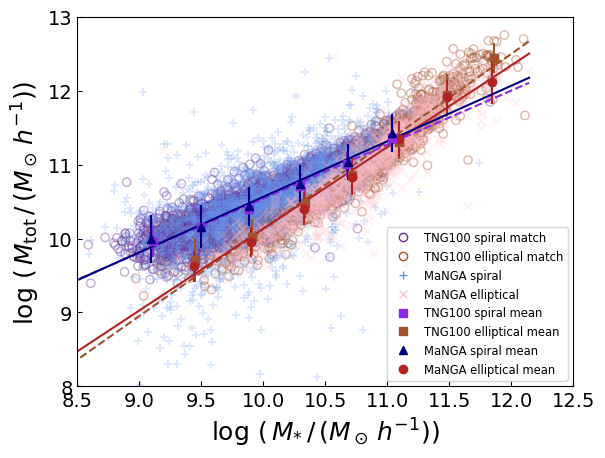

In [92]:
plt.scatter(s_match['illustris_Mstar_Sal'], s_match['illustris_MR90'],
           color='rebeccapurple', alpha=0.4, marker='o', facecolor='none')
plt.scatter(e_match['illustris_Mstar_Sal'], e_match['illustris_MR90'],
           color='sienna', alpha=0.4, marker='o', facecolor='none')
plt.scatter(s_match['sphd_M_star_h'], s_match['M_R90'],
           color='cornflowerblue',marker='+', alpha=0.2)
plt.scatter(e_match['sphd_M_star_h'], e_match['Mvir'],
           color='pink',marker='x', alpha=0.2)

plt.xlim(8.5,12.5)
# plt.plot([7,14],[7,14], linestyle='--', color='k', alpha=0.4)
plt.ylim(8,13)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='TNG100 spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='TNG100 elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='TNG100 spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='TNG100 elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6)]

# plot fits

plt.errorbar(ie_mstar_ctrs, ie_mtot_avg, yerr=ie_mtot_sig, linestyle='none', marker='s', color='sienna')
plt.errorbar(e_mstar_ctrs, e_mtot_avg, yerr=e_mtot_sig, linestyle='none', marker='o', color='firebrick')

plt.plot(mstar_bins, mstar_bins*ie_mtot_popt[0] + ie_mtot_popt[1], linestyle='--', color='sienna')
plt.plot(mstar_bins, mstar_bins*e_mtot_popt[0] + e_mtot_popt[1], linestyle='-', color='firebrick')


plt.errorbar(is_mstar_ctrs, is_mtot_avg, yerr=is_mtot_sig, linestyle='none', marker='s', color='blueviolet')
plt.errorbar(s_mstar_ctrs, s_mtot_avg, yerr=s_mtot_sig, linestyle='none', marker='^', color='navy')

plt.plot(mstar_bins, mstar_bins*is_mtot_popt[0] + is_mtot_popt[1], linestyle='--', color='blueviolet')
plt.plot(mstar_bins, mstar_bins*s_mtot_popt[0] + s_mtot_popt[1], linestyle='-', color='navy')

plt.tick_params( axis='both', direction='in',labelsize=14)



plt.ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$', fontsize=18)
plt.xlabel(r'$\log\,(\,M_{*}\,/\,(M_\odot\,h^{-1}))$', fontsize=18)

plt.legend(handles=legend_elements, fontsize='small')
plt.savefig(plot_dir + '/TNGmatch/mtot_mstar_illustris_refit.png', bbox_inches='tight')

## fig 9 hi spirals in manga/tng

In [64]:
# HI_spirals_gas = np.log10(10**HI_spirals['logHI_h'] + 10**HI_spirals['param_H2_h'] + 10**HI_spirals['param_He_h'])
HI_spirals_tng_gas = np.log10(10**HI_spirals['illustris_MH'] + 10**HI_spirals['illustris_MHe'])



# good_gas = HI_spirals_tng_gas >= 0

good_gas = HI_spirals_tng_gas > 0
HI_spirals_manga_gas = np.log10(10**HI_spirals['logHI_h'] + 10**HI_spirals['param_H2_h'] + 10**HI_spirals['param_He_h'])[good_gas]
HI_spirals_tng_gas = HI_spirals_tng_gas[good_gas]

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_76808/331689536.py:2: RuntimeWarning: divide by zero encountered in log10
  HI_spirals_tng_gas = np.log10(10**HI_spirals['illustris_MH'] + 10**HI_spirals['illustris_MHe'])


In [65]:
gas_bins = np.linspace(np.min(HI_spirals_manga_gas), 
                       np.max(HI_spirals_manga_gas), 
                       15)

In [97]:
gas_ctrs = []
tng_gas = []
gas_bins_custom = gas_bins
gas_bins_custom = np.concatenate((gas_bins[:1], gas_bins[5:-3], gas_bins[-1:]))

indices = np.digitize(HI_spirals_manga_gas, gas_bins_custom, right=True)

for i in range(1,len(gas_bins_custom)):

    tng_gas.append(HI_spirals_tng_gas[indices==i])
    gas_ctrs.append(np.mean(HI_spirals_manga_gas[indices==i]))

tng_gas_avg, tng_gas_sig = fit_to_gaussian(tng_gas, plot_dir = plot_dir + 'TNGmatch/spiral_gas/refit/', 
                                                     plot_name='spiral_gas_global', 
                                                     xlab=r'$M_{\rm gas, sim}$', 
                                                     plot_bins=gas_bins_custom, bin_lab=r'$M_{\rm gas, MaNGA}$',
                                          )

tng_gas_popt, tng_gas_pcov = curve_fit(lin_fit, gas_ctrs, 
                                       tng_gas_avg, sigma=tng_gas_sig)

print(tng_gas_popt, np.sqrt(tng_gas_pcov[0,0]), np.sqrt(tng_gas_pcov[1,1]))


[0.44735374 4.83340491] 0.025400867669446926 0.243331943308828


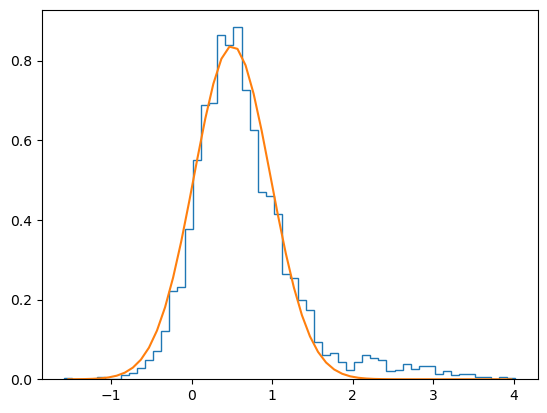

In [98]:
counts, bins = np.histogram(HI_spirals_manga_gas - HI_spirals_tng_gas,bins=int(np.sqrt(len(HI_spirals_manga_gas))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
s_gas_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(HI_spirals_manga_gas - HI_spirals_tng_gas),
                               np.std(HI_spirals_manga_gas - HI_spirals_tng_gas)])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, s_gas_params[0], s_gas_params[1]))

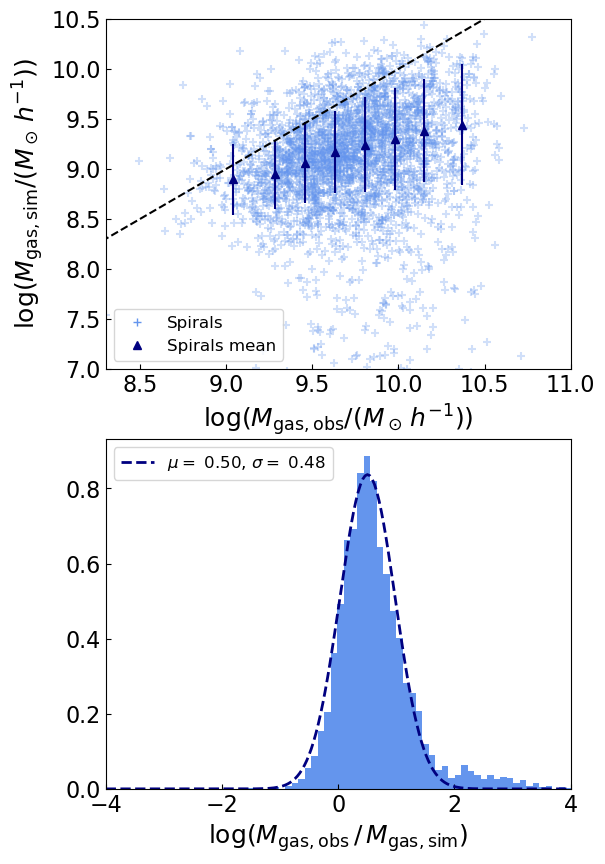

In [99]:
fig,ax = plt.subplots(2,1, figsize=(6,10))
ax[0].scatter(HI_spirals_manga_gas, HI_spirals_tng_gas, marker='+', alpha=0.3, color='cornflowerblue')
ax[0].errorbar(gas_ctrs, tng_gas_avg, yerr=tng_gas_sig, linestyle='none', marker='^', color='navy')
ax[0].plot([8,12],[8,12], color='k', linestyle='--')
ax[0].set_xlabel(r'$\log(M_{\rm gas, obs}/(M_\odot\, h^{-1}))$', fontsize=18)
ax[0].set_ylabel(r'$\log(M_{\rm gas, sim}/(M_\odot\, h^{-1}))$', fontsize=18)

ax[1].plot(np.linspace(-4,4,200), gaussian(np.linspace(-4,4,200), s_gas_params[0], s_gas_params[1]),
          color='navy', linestyle='--', linewidth=2)

ax[1].hist(HI_spirals_manga_gas - HI_spirals_tng_gas, bins=50, color='cornflowerblue', 
          # weights=1/len(HI_spirals_manga_gas) * np.ones(len(HI_spirals_manga_gas)),
          density=True)
ax[1].set_xlabel(r'$\log(M_{\rm gas, obs}\, / \, M_{\rm gas, sim})$', fontsize=18)

ax[0].tick_params( axis='both', direction='in', labelsize=16)
ax[1].tick_params( axis='both', direction='in', labelsize=16)


legend_elements = [Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                   Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  ]

ax[0].legend(handles=legend_elements, fontsize='large')

legend_elements = [
                    #Patch(facecolor='cornflowerblue', edgecolor='cornflowerblue',
                     #  label=fr'$\mu =$ {s_gas_params[0]:.2f}, $\sigma =$ {s_gas_params[1]:.2f}'),
                  Line2D([0], [0], marker='none', color='navy', label=fr'$\mu =$ {s_gas_params[0]:.2f}, $\sigma =$ {s_gas_params[1]:.2f}',
                          markeredgecolor='none', markerfacecolor='none', markersize=6,
                        linestyle='--', linewidth=2),
                    ]

ax[1].legend(handles=legend_elements, fontsize='large')

ax[0].set_xlim(8.3,11)
ax[0].set_ylim(7,10.5)
ax[1].set_xlim(-4,4)
plt.savefig(plot_dir + '/TNGmatch/spiral_gas/global_gas_compare_refit.png', bbox_inches='tight')

## fig 10 components vs mr 3x3

In [100]:
mr_bins =  np.linspace(np.min([np.min(HI_spirals['rabsmag']), np.min(ellipticals['rabsmag'])])-0.01,
                  np.max([np.max(HI_spirals['rabsmag']), np.max(ellipticals['rabsmag'])]), 15)

### ellipticals mstar

In [102]:
e_mr_mstar_ctrs = []
e_mstar = []
e_mr_mstar_bins = mr_bins
e_mr_mstar_bins = np.concatenate((mr_bins[0:7], mr_bins[-1:]))

indices = np.digitize(ellipticals['rabsmag'], e_mr_mstar_bins, right=True)

for i in range(1,len(e_mr_mstar_bins)):

    e_mstar.append(ellipticals['e_M_star_R90_h'][indices==i])
    e_mr_mstar_ctrs.append(np.mean(ellipticals['rabsmag'][indices==i]))

e_mstar_avg, e_mstar_sig = fit_to_gaussian(e_mstar, plot_dir = plot_dir + 'HI_spirals/ellipticals_mr_mstar90/refit/', plot_name='ellipticals_Mstar90_Mr', xlab=r'$M_*$', plot_bins=e_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
e_mstar_popt, e_mstar_pcov = curve_fit(lin_fit, e_mr_mstar_ctrs, 
                                       e_mstar_avg, sigma=e_mstar_sig)
print(e_mstar_popt, np.sqrt(e_mstar_pcov[0,0]), np.sqrt(e_mstar_pcov[1,1]))


[-0.38377372  2.88814701] 0.005383509730173696 0.11508556369981966


In [103]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/ellipticals_mr_mstar90/refit/data.txt', 'x')
f.write('e_mr_centers \n')
f.write(str(e_mr_mstar_ctrs) + '\n')
f.write('e_mr_mstar_avgs \n')
f.write(str(e_mstar_avg)+ '\n')
f.write('e_mr_mstar_sigs \n')
f.write(str(e_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(e_mstar_popt[0]) + ' +- ' + str(np.sqrt(e_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(e_mstar_popt[1]) + ' +- ' + str(np.sqrt(e_mstar_pcov[1,1]))+ '\n')
f.close()



### ellipticals mtot

In [105]:
# ellipticals
e_mr_mtot_ctrs = []
e_mtot = []
e_mr_mtot_bins = mr_bins
e_mr_mtot_bins = np.concatenate((mr_bins[0:9], mr_bins[-1:]))

indices = np.digitize(ellipticals['rabsmag'], e_mr_mtot_bins, right=True)

for i in range(1,len(e_mr_mtot_bins)):

    e_mtot.append(ellipticals['Mvir'][indices==i])
    e_mr_mtot_ctrs.append(np.mean(ellipticals['rabsmag'][indices==i]))

e_mtot_avg, e_mtot_sig = fit_to_gaussian(e_mtot, plot_dir = plot_dir + 'HI_spirals/ellipticals_mr_mtot/refit/', plot_name='ellipticals_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=e_mr_mtot_bins, bin_lab=r'$M_r$',  bin_order='flip')

# fit da lines

e_mtot_popt, e_mtot_pcov = curve_fit(lin_fit, e_mr_mtot_ctrs, 
                                       e_mtot_avg, sigma=e_mtot_sig)

print(e_mtot_popt, np.sqrt(e_mtot_pcov[0,0]), np.sqrt(e_mtot_pcov[1,1]))

[-0.50366454  0.69081094] 0.010950369803771696 0.2285272679782403


In [106]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/ellipticals_mr_mtot/refit/data.txt', 'x')
f.write('e_mr_centers \n')
f.write(str(e_mr_mtot_ctrs) + '\n')
f.write('e_mr_mtot_avgs \n')
f.write(str(e_mtot_avg)+ '\n')
f.write('e_mr_mtot_sigs \n')
f.write(str(e_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(e_mtot_popt[0]) + ' +- ' + str(np.sqrt(e_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(e_mtot_popt[1]) + ' +- ' + str(np.sqrt(e_mtot_pcov[1,1]))+ '\n')
f.close()



### blue spiral mstar

In [107]:
blue_HI_spirals = HI_spirals[HI_spirals['CMD_class'] == 1]

bs_mr_mstar_ctrs = []
bs_mstar = []
bs_mr_mstar_bins = mr_bins
bs_mr_mstar_bins = np.concatenate((mr_bins[:0], mr_bins[3:-5], mr_bins[-1:]))

indices = np.digitize(blue_HI_spirals['rabsmag'], bs_mr_mstar_bins, right=True)

for i in range(1,len(bs_mr_mstar_bins)):

    bs_mstar.append(blue_HI_spirals['M90_disk_h'][indices==i])
    bs_mr_mstar_ctrs.append(np.mean(blue_HI_spirals['rabsmag'][indices==i]))

bs_mstar_avg, bs_mstar_sig = fit_to_gaussian(bs_mstar, plot_dir = plot_dir + 'HI_spirals/bspiral_mr_mstar90/refit/', plot_name='bspiral_Mstar90_Mr', xlab=r'$M_*$', plot_bins=bs_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
bs_mstar_popt, bs_mstar_pcov = curve_fit(lin_fit, bs_mr_mstar_ctrs, 
                                       bs_mstar_avg, sigma=bs_mstar_sig)
print(bs_mstar_popt, np.sqrt(bs_mstar_pcov[0,0]), np.sqrt(bs_mstar_pcov[1,1]))


[-0.4441768   1.36892873] 0.004263691081336371 0.08346458459478033


In [108]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/bspiral_mr_mstar90/refit/data.txt', 'x')
f.write('bs_mr_centers \n')
f.write(str(bs_mr_mstar_ctrs) + '\n')
f.write('bs_mr_mstar_avgs \n')
f.write(str(bs_mstar_avg)+ '\n')
f.write('bs_mr_mstar_sigs \n')
f.write(str(bs_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(bs_mstar_popt[0]) + ' +- ' + str(np.sqrt(bs_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(bs_mstar_popt[1]) + ' +- ' + str(np.sqrt(bs_mstar_pcov[1,1]))+ '\n')
f.close()



### bspiral mtot

In [110]:
bs_mr_mtot_ctrs = []
bs_mtot = []
bs_mr_mtot_bins = mr_bins
bs_mr_mtot_bins = np.concatenate((mr_bins[:0], mr_bins[3:-4], mr_bins[-1:]))

indices = np.digitize(blue_HI_spirals['rabsmag'], bs_mr_mtot_bins, right=True)

for i in range(1,len(bs_mr_mtot_bins)):

    bs_mtot.append(blue_HI_spirals['M_R90'][indices==i])
    bs_mr_mtot_ctrs.append(np.mean(blue_HI_spirals['rabsmag'][indices==i]))

bs_mtot_avg, bs_mtot_sig = fit_to_gaussian(bs_mtot, plot_dir = plot_dir + 'HI_spirals/bspiral_mr_mtot/refit/', plot_name='bspiral_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=bs_mr_mtot_bins, bin_lab=r'$M_r$', bin_order='flip')
bs_mtot_popt, bs_mtot_pcov = curve_fit(lin_fit, bs_mr_mtot_ctrs, 
                                       bs_mtot_avg, sigma=bs_mtot_sig)
print(bs_mtot_popt, np.sqrt(bs_mtot_pcov[0,0]), np.sqrt(bs_mtot_pcov[1,1]))


[-0.33223132  4.13659497] 0.0045381828790099785 0.08907511179364977


In [111]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/bspiral_mr_mtot/refit/data.txt', 'x')
f.write('bs_mr_centers \n')
f.write(str(bs_mr_mtot_ctrs) + '\n')
f.write('bs_mr_mtot_avgs \n')
f.write(str(bs_mtot_avg)+ '\n')
f.write('bs_mr_mtot_sigs \n')
f.write(str(bs_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(bs_mtot_popt[0]) + ' +- ' + str(np.sqrt(bs_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(bs_mtot_popt[1]) + ' +- ' + str(np.sqrt(bs_mtot_pcov[1,1]))+ '\n')
f.close()



### bspiral mbar

In [116]:
 #recalculate the components

HI_spirals['logHI_R90_h'] = np.zeros(len(HI_spirals))
HI_spirals['param_He90_h'] = np.zeros(len(HI_spirals))
HI_spirals_H290 = np.zeros(len(HI_spirals))


for i in range(len(HI_spirals)):

    HI_spirals['logHI_R90_h'][i] = HI_spirals['logHI_R90'][i] + np.log10(0.7)
    
    if HI_spirals['CMD_class'][i] == 1:
        HI_spirals_H290[i] = -0.4*HI_spirals['rabsmag'][i] +1.12
    elif HI_spirals['CMD_class'][i] == 2 or HI_spirals['CMD_class'][i] == 3:
        HI_spirals_H290[i] = -0.27*HI_spirals['rabsmag'][i] + 3.62

    HI_spirals['param_He90_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_spirals['logHI_R90_h'][i] + 10**HI_spirals_H290[i])

HI_spirals_mbar = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_R90_h'] + 10**HI_spirals_H290 + 10**HI_spirals['param_He90_h'])

In [118]:
blue_spirals_mbar = HI_spirals_mbar[HI_spirals['CMD_class']==1]

bs_mr_mbar_ctrs = []
bs_mbar = []
bs_mr_mbar_bins = mr_bins
bs_mr_mbar_bins = np.concatenate((mr_bins[:1], mr_bins[4:-4], mr_bins[-1:]))



indices = np.digitize(blue_HI_spirals['rabsmag'], bs_mr_mbar_bins, right=True)

for i in range(1,len(bs_mr_mbar_bins)):

    bs_mbar.append(blue_spirals_mbar[indices==i])
    bs_mr_mbar_ctrs.append(np.mean(blue_HI_spirals['rabsmag'][indices==i]))

bs_mbar_avg, bs_mbar_sig = fit_to_gaussian(bs_mbar, plot_dir = plot_dir + 'HI_spirals/bspiral_mr_mbar90/refit/', 
                                                     plot_name='bspiral_Mstar90_Mr', 
                                                     xlab=r'$M_* + M_{\rm HI} + M_*{\rm He} + M_{\rm H_2}$', 
                                                     plot_bins=bs_mr_mbar_bins, bin_lab=r'$M_r$', bin_order='flip',
                                          use_custom_bins=True, 
                                           custom_bins=[np.concatenate((np.linspace(10,11.5,12), np.array([15]))),
                                                        np.concatenate((np.linspace(10,11.5,12), np.array([15]))),
                                                        np.concatenate((np.linspace(9.5,11.5,12), np.array([15]))),
                                                        np.concatenate((np.linspace(9.5,11.5,12), np.array([15]))),
                                                        np.concatenate((np.linspace(9,11.5,12), np.array([15]))),
                                                        np.concatenate((np.linspace(9,11,12), np.array([15]))),
                                                        np.concatenate((np.linspace(8.5,10.5,12), np.array([15]))),
                                                        np.concatenate((np.linspace(8,10.2,7), np.array([15])))]
                                                        )
bs_mbar_popt, bs_mbar_pcov = curve_fit(lin_fit, bs_mr_mbar_ctrs, 
                                       bs_mbar_avg, sigma=bs_mbar_sig)
print(bs_mbar_popt, np.sqrt(bs_mbar_pcov[0,0]), np.sqrt(bs_mbar_pcov[1,1]))


[-0.40324018  2.29122004] 0.004598939359914615 0.08860905546812556


In [119]:
f = open(plot_dir + 'HI_spirals/bspiral_mr_mbar90/refit/data.txt', 'x')
f.write('bs_mr_centers \n')
f.write(str(bs_mr_mbar_ctrs) + '\n')
f.write('bs_mr_mbar_avgs \n')
f.write(str(bs_mbar_avg)+ '\n')
f.write('bs_mr_mbar_sigs \n')
f.write(str(bs_mbar_sig)+ '\n')

f.write('slope \n')
f.write(str(bs_mbar_popt[0]) + ' +- ' + str(np.sqrt(bs_mbar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(bs_mbar_popt[1]) + ' +- ' + str(np.sqrt(bs_mbar_pcov[1,1]))+ '\n')
f.close()


### green spiral mstar`

In [120]:
green_HI_spirals = HI_spirals[HI_spirals['CMD_class']==2]

gs_mr_mstar_ctrs = []
gs_mstar = []
gs_mr_mstar_bins = mr_bins
gs_mr_mstar_bins = np.concatenate((mr_bins[:1], mr_bins[3:-6], mr_bins[-1:]))

indices = np.digitize(green_HI_spirals['rabsmag'], gs_mr_mstar_bins, right=True)

for i in range(1,len(gs_mr_mstar_bins)):

    gs_mstar.append(green_HI_spirals['M90_disk_h'][indices==i])
    gs_mr_mstar_ctrs.append(np.mean(green_HI_spirals['rabsmag'][indices==i]))

gs_mstar_avg, gs_mstar_sig = fit_to_gaussian(gs_mstar, plot_dir = plot_dir + 'HI_spirals/gspiral_mr_mstar90/refit/', plot_name='gspiral_Mstar90_Mr', xlab=r'$M_*$', plot_bins=gs_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
gs_mstar_popt, gs_mstar_pcov = curve_fit(lin_fit, gs_mr_mstar_ctrs, 
                                       gs_mstar_avg, sigma=gs_mstar_sig)
print(gs_mstar_popt, np.sqrt(gs_mstar_pcov[0,0]), np.sqrt(gs_mstar_pcov[1,1]))


[-0.42742946  1.86124546] 0.012259432698251154 0.2494532369356974


In [121]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/gspiral_mr_mstar90/refit/data.txt', 'x')
f.write('gs_mr_centers \n')
f.write(str(gs_mr_mstar_ctrs) + '\n')
f.write('gs_mr_mstar_avgs \n')
f.write(str(gs_mstar_avg)+ '\n')
f.write('gs_mr_mstar_sigs \n')
f.write(str(gs_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(gs_mstar_popt[0]) + ' +- ' + str(np.sqrt(gs_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(gs_mstar_popt[1]) + ' +- ' + str(np.sqrt(gs_mstar_pcov[1,1]))+ '\n')
f.close()



### green spiral mtot

In [122]:
gs_mr_mtot_ctrs = []
gs_mtot = []
gs_mr_mtot_bins = mr_bins
gs_mr_mtot_bins = np.concatenate((mr_bins[:0], mr_bins[2:-6], mr_bins[-1:]))

indices = np.digitize(green_HI_spirals['rabsmag'], gs_mr_mtot_bins, right=True)

for i in range(1,len(gs_mr_mtot_bins)):

    gs_mtot.append(green_HI_spirals['M_R90'][indices==i])
    gs_mr_mtot_ctrs.append(np.mean(green_HI_spirals['rabsmag'][indices==i]))

gs_mtot_avg, gs_mtot_sig = fit_to_gaussian(gs_mtot, plot_dir = plot_dir + 'HI_spirals/gspiral_mr_mtot/refit/', plot_name='gspiral_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=gs_mr_mtot_bins, bin_lab=r'$M_r$', bin_order='flip')
gs_mtot_popt, gs_mtot_pcov = curve_fit(lin_fit, gs_mr_mtot_ctrs, 
                                       gs_mtot_avg, sigma=gs_mtot_sig)
print(gs_mtot_popt, np.sqrt(gs_mtot_pcov[0,0]), np.sqrt(gs_mtot_pcov[1,1]))


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


[-0.38606072  3.13327251] 0.013057729615058201 0.2645567105589034


In [123]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/gspiral_mr_mtot/refit/data.txt', 'x')
f.write('gs_mr_centers \n')
f.write(str(gs_mr_mtot_ctrs) + '\n')
f.write('gs_mr_mtot_avgs \n')
f.write(str(gs_mtot_avg)+ '\n')
f.write('gs_mr_mtot_sigs \n')
f.write(str(gs_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(gs_mtot_popt[0]) + ' +- ' + str(np.sqrt(gs_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(gs_mtot_popt[1]) + ' +- ' + str(np.sqrt(gs_mtot_pcov[1,1]))+ '\n')
f.close()



### green spiral mbar

In [128]:
green_spirals_mbar = HI_spirals_mbar[HI_spirals['CMD_class']==2]

gs_mr_mbar_ctrs = []
gs_mbar = []
gs_mr_mbar_bins = mr_bins
gs_mr_mbar_bins = np.concatenate((mr_bins[:1], mr_bins[4:-5], mr_bins[-1:]))



indices = np.digitize(green_HI_spirals['rabsmag'], gs_mr_mbar_bins, right=True)

for i in range(1,len(gs_mr_mbar_bins)):

    gs_mbar.append(green_spirals_mbar[indices==i])
    gs_mr_mbar_ctrs.append(np.mean(green_HI_spirals['rabsmag'][indices==i]))

gs_mbar_avg, gs_mbar_sig = fit_to_gaussian(gs_mbar, plot_dir = plot_dir + 'HI_spirals/gspiral_mr_mbar90/refit/', 
                                                     plot_name='gspiral_Mstar90_Mr', 
                                                     xlab=r'$M_* + M_{\rm HI} + M_*{\rm He} + M_{\rm H_2}$', 
                                                     plot_bins=gs_mr_mbar_bins, bin_lab=r'$M_r$', bin_order='flip',
                                          use_custom_bins=True,
                                          custom_bins=[int(np.sqrt(len(gs_mbar[0])) + 1), #0
                                                        np.concatenate((np.linspace(10,11.5,8), np.array([13.5]))), #1
                                                        np.concatenate((np.linspace(10,11,11), np.array([15]))), #2
                                                        np.concatenate((np.linspace(9.5,11,9), np.array([15]))), #3
                                                        np.concatenate((np.linspace(9.5,11,11), np.array([15]))), #4
                                                        np.concatenate((np.linspace(9,10.5,9), np.array([15]))), #5
                                                        np.concatenate((np.linspace(8.5,10.5,8), np.array([15])))]
                                           #6
                                                        )

gs_mbar_popt, gs_mbar_pcov = curve_fit(lin_fit, gs_mr_mbar_ctrs, 
                                       gs_mbar_avg, sigma=gs_mbar_sig)
print(gs_mbar_popt, np.sqrt(gs_mbar_pcov[0,0]), np.sqrt(gs_mbar_pcov[1,1]))


[-0.42446141  1.9857701 ] 0.01389257645250385 0.2711386668460276


In [129]:
f = open(plot_dir + 'HI_spirals/gspiral_mr_mbar90/refit/data.txt', 'x')
f.write('gs_mr_centers \n')
f.write(str(gs_mr_mbar_ctrs) + '\n')
f.write('gs_mr_mbar_avgs \n')
f.write(str(gs_mbar_avg)+ '\n')
f.write('gs_mr_mbar_sigs \n')
f.write(str(gs_mbar_sig)+ '\n')

f.write('slope \n')
f.write(str(gs_mbar_popt[0]) + ' +- ' + str(np.sqrt(gs_mbar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(gs_mbar_popt[1]) + ' +- ' + str(np.sqrt(gs_mbar_pcov[1,1]))+ '\n')
f.close()


### red spiral mstar

In [130]:
red_HI_spirals = HI_spirals[HI_spirals['CMD_class']==3]

rs_mr_mstar_ctrs = []
rs_mstar = []
rs_mr_mstar_bins = mr_bins
rs_mr_mstar_bins = np.concatenate((mr_bins[:1], mr_bins[4:-8], mr_bins[-1:]))

indices = np.digitize(red_HI_spirals['rabsmag'], rs_mr_mstar_bins, right=True)

for i in range(1,len(rs_mr_mstar_bins)):

    rs_mstar.append(red_HI_spirals['M90_disk_h'][indices==i])
    rs_mr_mstar_ctrs.append(np.mean(red_HI_spirals['rabsmag'][indices==i]))

rs_mstar_avg, rs_mstar_sig = fit_to_gaussian(rs_mstar, plot_dir = plot_dir + 'HI_spirals/rspiral_mr_mstar90/refit/', plot_name='rspiral_Mstar90_Mr', xlab=r'$M_*$', plot_bins=rs_mr_mstar_bins, bin_lab=r'$M_r$', bin_order='flip')
rs_mstar_popt, rs_mstar_pcov = curve_fit(lin_fit, rs_mr_mstar_ctrs, 
                                       rs_mstar_avg, sigma=rs_mstar_sig)
print(rs_mstar_popt, np.sqrt(rs_mstar_pcov[0,0]), np.sqrt(rs_mstar_pcov[1,1]))


[-0.37432524  2.97328825] 0.019966122334427475 0.4044891711899745


In [131]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/rspiral_mr_mstar90/refit/data.txt', 'x')
f.write('rs_mr_centers \n')
f.write(str(rs_mr_mstar_ctrs) + '\n')
f.write('rs_mr_mstar_avgs \n')
f.write(str(rs_mstar_avg)+ '\n')
f.write('rs_mr_mstar_sigs \n')
f.write(str(rs_mstar_sig)+ '\n')

f.write('slope \n')
f.write(str(rs_mstar_popt[0]) + ' +- ' + str(np.sqrt(rs_mstar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(rs_mstar_popt[1]) + ' +- ' + str(np.sqrt(rs_mstar_pcov[1,1]))+ '\n')
f.close()



### red spiral mtot

In [132]:
rs_mr_mtot_ctrs = []
rs_mtot = []
rs_mr_mtot_bins = mr_bins
rs_mr_mtot_bins = np.concatenate((mr_bins[:0], mr_bins[4:-8], mr_bins[-1:]))

indices = np.digitize(red_HI_spirals['rabsmag'], rs_mr_mtot_bins, right=True)

for i in range(1,len(rs_mr_mtot_bins)):

    rs_mtot.append(red_HI_spirals['M_R90'][indices==i])
    rs_mr_mtot_ctrs.append(np.mean(red_HI_spirals['rabsmag'][indices==i]))

rs_mtot_avg, rs_mtot_sig = fit_to_gaussian(rs_mtot, plot_dir = plot_dir + 'HI_spirals/rspiral_mr_mtot/refit/', plot_name='rspiral_Mtot_Mr', xlab=r'$M_{\rm tot}$', plot_bins=rs_mr_mtot_bins, bin_lab=r'$M_r$', bin_order='flip')
rs_mtot_popt, rs_mtot_pcov = curve_fit(lin_fit, rs_mr_mtot_ctrs, 
                                       rs_mtot_avg, sigma=rs_mtot_sig)
print(rs_mtot_popt, np.sqrt(rs_mtot_pcov[0,0]), np.sqrt(rs_mtot_pcov[1,1]))


/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


[-0.38758044  3.08782713] 0.003227925915100515 0.0645732495249034


In [133]:
# write data to a file 
f = open(plot_dir + 'HI_spirals/rspiral_mr_mtot/refit/data.txt', 'x')
f.write('rs_mr_centers \n')
f.write(str(rs_mr_mtot_ctrs) + '\n')
f.write('rs_mr_mtot_avgs \n')
f.write(str(rs_mtot_avg)+ '\n')
f.write('rs_mr_mtot_sigs \n')
f.write(str(rs_mtot_sig)+ '\n')

f.write('slope \n')
f.write(str(rs_mtot_popt[0]) + ' +- ' + str(np.sqrt(rs_mtot_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(rs_mtot_popt[1]) + ' +- ' + str(np.sqrt(rs_mtot_pcov[1,1]))+ '\n')
f.close()



### red spiral mbar

In [134]:
red_spirals_mbar = HI_spirals_mbar[HI_spirals['CMD_class']==3]
rs_mr_mbar_ctrs = []
rs_mbar = []
rs_mr_mbar_bins = mr_bins
rs_mr_mbar_bins = np.concatenate((mr_bins[:0], mr_bins[3:5], mr_bins[6:-8], mr_bins[-1:]))



indices = np.digitize(red_HI_spirals['rabsmag'], rs_mr_mbar_bins, right=True)

for i in range(1,len(rs_mr_mbar_bins)):

    rs_mbar.append(red_spirals_mbar[indices==i])
    rs_mr_mbar_ctrs.append(np.mean(red_HI_spirals['rabsmag'][indices==i]))

rs_mbar_avg, rs_mbar_sig = fit_to_gaussian(rs_mbar, plot_dir = plot_dir + 'HI_spirals/rspiral_mr_mbar90/refit/', 
                                                     plot_name='rspiral_Mstar90_Mr', 
                                                     xlab=r'$M_* + M_{\rm HI} + M_*{\rm He} + M_{\rm H_2}$', 
                                                     plot_bins=rs_mr_mbar_bins, bin_lab=r'$M_r$', bin_order='flip',
                                          use_custom_bins=True, 
                                           custom_bins=[int(np.sqrt(len(rs_mbar[0])) + 1), #0
                                                        np.concatenate((np.linspace(10,12,9), np.array([15]))), #1
                                                        np.concatenate((np.linspace(9,11,8), np.array([15]))), #2
                                                                    ]
                                          )
rs_mbar_popt, rs_mbar_pcov = curve_fit(lin_fit, rs_mr_mbar_ctrs, 
                                       rs_mbar_avg, sigma=rs_mbar_sig)
print(rs_mbar_popt, np.sqrt(rs_mbar_pcov[0,0]), np.sqrt(rs_mbar_pcov[1,1]))


[-0.37964405  2.883947  ] 0.026049894516107976 0.5329691933800804


In [135]:
f = open(plot_dir + 'HI_spirals/rspiral_mr_mbar90/refit/data.txt', 'x')
f.write('rs_mr_centers \n')
f.write(str(rs_mr_mbar_ctrs) + '\n')
f.write('rs_mr_mbar_avgs \n')
f.write(str(rs_mbar_avg)+ '\n')
f.write('rs_mr_mbar_sigs \n')
f.write(str(rs_mbar_sig)+ '\n')

f.write('slope \n')
f.write(str(rs_mbar_popt[0]) + ' +- ' + str(np.sqrt(rs_mbar_pcov[0,0]))+ '\n')
f.write('y-int \n')
f.write(str(rs_mbar_popt[1]) + ' +- ' + str(np.sqrt(rs_mbar_pcov[1,1]))+ '\n')
f.close()


### plot

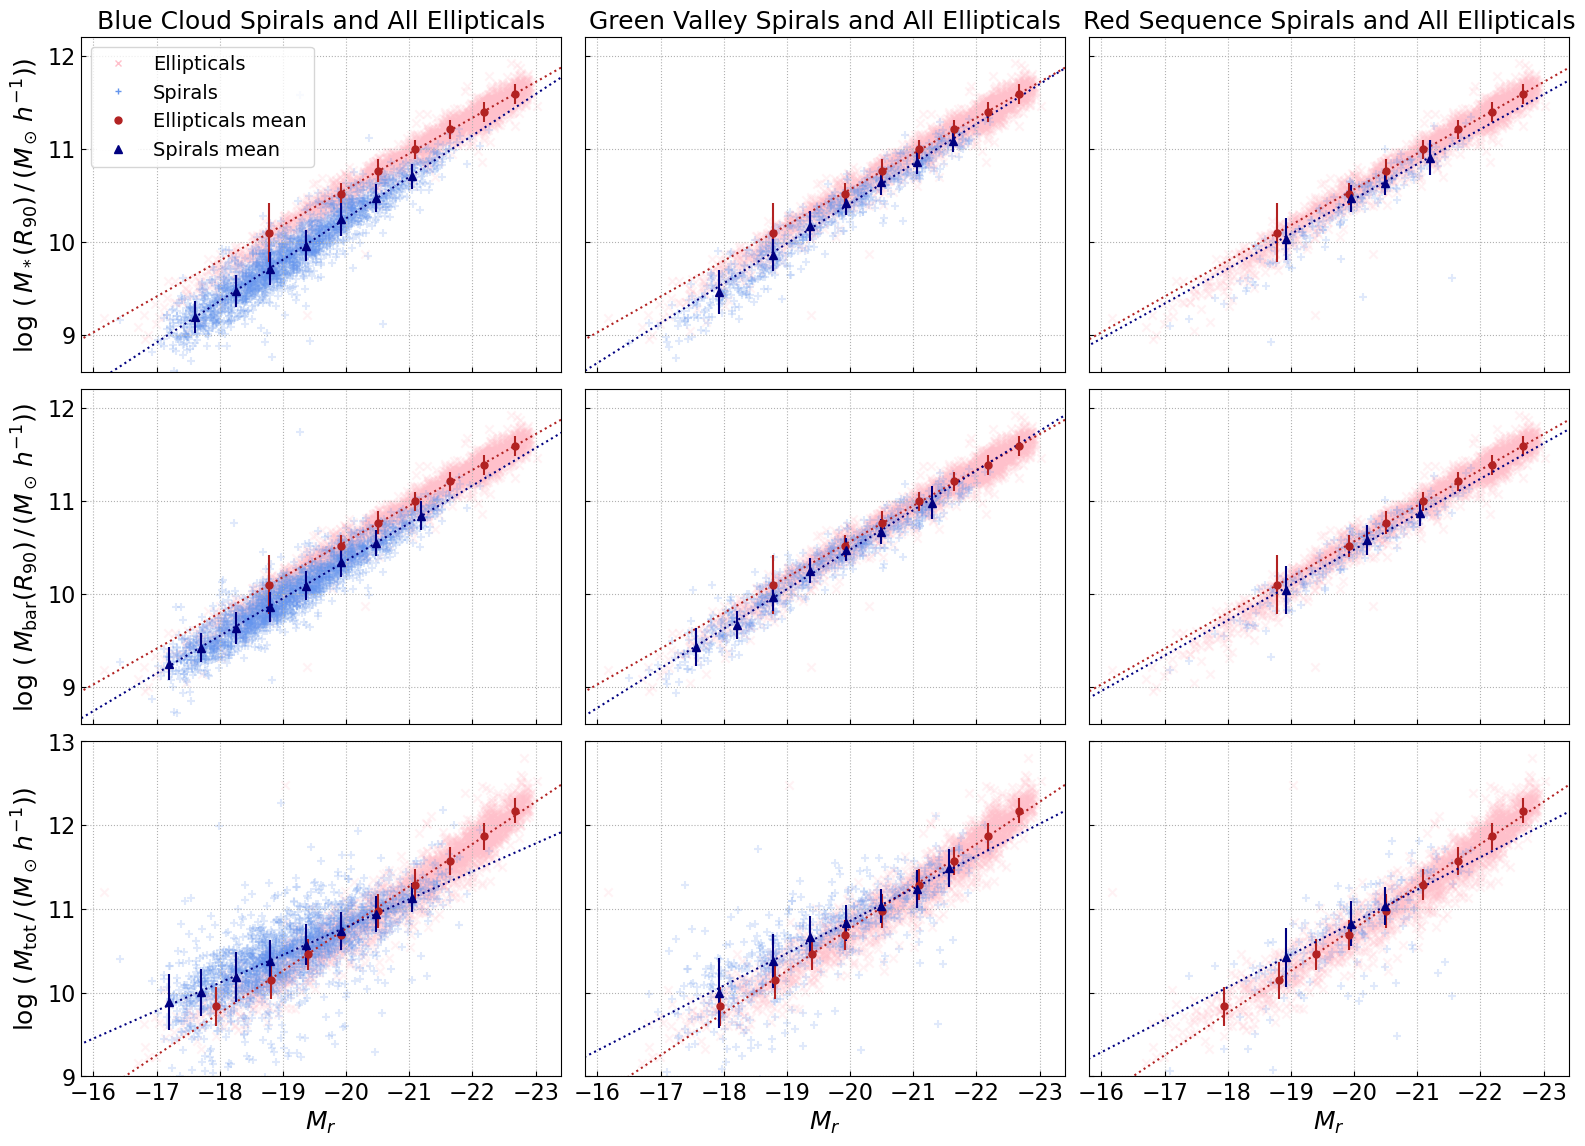

In [136]:
fig, ax = plt.subplots(3,3,sharex=True, sharey='row', figsize=(19.2,13.5))
mrs=np.linspace(-25, -15,1000)

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[2,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm bar}(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)


ax[0,0].set_yticks(np.arange(9,13,1))
ax[2,0].set_yticks(np.arange(9,14,1))
ax[2,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(8.6, 12.2)

# rs = np.linspace(-23.2,-17.2,100)


for i in range(0,3):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[2,i].set_xlabel(r'$M_r$', fontsize=18)
    
    ax[2,i].set_xticks(np.arange(-23,-15,1))
    ax[2,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[0,i].errorbar(e_mr_mstar_ctrs, e_mstar_avg, color='firebrick', yerr=e_mstar_sig, 
                 marker='o', linestyle='none', markersize=5, )
    ax[0,i].plot(mrs, e_mstar_popt[0]*mrs + e_mstar_popt[1], color='firebrick', linestyle=':')

    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[1,i].errorbar(e_mr_mstar_ctrs, e_mstar_avg, color='firebrick', yerr=e_mstar_sig, 
                 marker='o', linestyle='none', markersize=5, )
    ax[1,i].plot(mrs, e_mstar_popt[0]*mrs + e_mstar_popt[1], color='firebrick', linestyle=':')

    
    ax[2,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.2)
    ax[2,i].errorbar(e_mr_mtot_ctrs,e_mtot_avg, color='firebrick', yerr=e_mtot_sig, 
                 marker='o',linestyle='none', markersize=5, )
    ax[2,i].plot(mrs, e_mtot_popt[0]*mrs + e_mtot_popt[1], color='firebrick', linestyle=':')




legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_HI_spirals['rabsmag'], blue_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,0].errorbar(bs_mr_mstar_ctrs, bs_mstar_avg, color='navy', yerr=bs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,0].plot(mrs, bs_mstar_popt[0]*mrs + bs_mstar_popt[1], color='navy', linestyle=':')




ax[0,1].scatter(green_HI_spirals['rabsmag'], green_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,1].errorbar(gs_mr_mstar_ctrs, gs_mstar_avg, color='navy', yerr=gs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,1].plot(mrs, gs_mstar_popt[0]*mrs + gs_mstar_popt[1], color='navy', linestyle=':')





ax[0,2].scatter(red_HI_spirals['rabsmag'], red_HI_spirals['M90_disk_h'] , color='cornflowerblue', marker='+', alpha=0.2)
ax[0,2].errorbar(rs_mr_mstar_ctrs,rs_mstar_avg, color='navy', yerr=rs_mstar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,2].plot(mrs, rs_mstar_popt[0]*mrs + rs_mstar_popt[1], color='navy', linestyle=':')



ax[1,0].scatter(blue_HI_spirals['rabsmag'], blue_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,0].errorbar(bs_mr_mbar_ctrs, bs_mbar_avg, color='navy', yerr=bs_mbar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,0].plot(mrs, bs_mbar_popt[0]*mrs + bs_mbar_popt[1], color='navy', linestyle=':')




ax[1,1].scatter(green_HI_spirals['rabsmag'], green_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,1].errorbar(gs_mr_mbar_ctrs, gs_mbar_avg, color='navy', yerr=gs_mbar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,1].plot(mrs, gs_mbar_popt[0]*mrs + gs_mbar_popt[1], color='navy', linestyle=':')





ax[1,2].scatter(red_HI_spirals['rabsmag'], red_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,2].errorbar(rs_mr_mbar_ctrs,rs_mbar_avg, color='navy', yerr=rs_mbar_sig, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,2].plot(mrs, rs_mbar_popt[0]*mrs + rs_mbar_popt[1], color='navy', linestyle=':')



ax[2,0].scatter(blue_HI_spirals['rabsmag'], blue_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,0].errorbar(bs_mr_mtot_ctrs, bs_mtot_avg, color='navy', yerr=bs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,0].plot(mrs, bs_mtot_popt[0]*mrs + bs_mtot_popt[1], color='navy', linestyle=':')



ax[2,1].scatter(green_HI_spirals['rabsmag'], green_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,1].errorbar(gs_mr_mtot_ctrs, gs_mtot_avg, color='navy', yerr=gs_mtot_sig, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,1].plot(mrs, gs_mtot_popt[0]*mrs + gs_mtot_popt[1], color='navy', linestyle=':')



ax[2,2].scatter(red_HI_spirals['rabsmag'], red_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='red sequence spirals')
ax[2,2].errorbar(rs_mr_mtot_ctrs, rs_mtot_avg, color='navy', yerr=rs_mtot_sig, 
                 marker='^', label='red sequence spiral median',linestyle='none', markersize=6,)
ax[2,2].plot(mrs, rs_mtot_popt[0]*mrs + rs_mtot_popt[1], color='navy', linestyle=':')

fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.savefig(plot_dir + 'HI_spirals/Mtot_Mstar_Mbar_Mr_CMDspiral_ellipticals_refit.png', bbox_inches='tight')

## fig 10 from saved data

In [24]:
path_to_HI_spirals = '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/HI_spirals/'


In [25]:
bs_mr_mbar_ctrs, bs_mr_mbar_avgs, bs_mr_mbar_sigs, bs_mr_mbar_slope, bs_mr_mbar_yint = get_vals_from_txt(path_to_HI_spirals + '/bspiral_mr_mbar90/refit/data.txt')
bs_mr_star_ctrs, bs_mr_star_avgs, bs_mr_star_sigs, bs_mr_star_slope, bs_mr_star_yint = get_vals_from_txt(path_to_HI_spirals + '/bspiral_mr_mstar90/refit/data.txt')
bs_mr_tot_ctrs, bs_mr_tot_avgs, bs_mr_tot_sigs, bs_mr_tot_slope, bs_mr_tot_yint = get_vals_from_txt(path_to_HI_spirals + '/bspiral_mr_mtot/refit/data.txt')

In [26]:
gs_mr_mbar_ctrs, gs_mr_mbar_avgs, gs_mr_mbar_sigs, gs_mr_mbar_slope, gs_mr_mbar_yint = get_vals_from_txt(path_to_HI_spirals + '/gspiral_mr_mbar90/refit/data.txt')
gs_mr_star_ctrs, gs_mr_star_avgs, gs_mr_star_sigs, gs_mr_star_slope, gs_mr_star_yint = get_vals_from_txt(path_to_HI_spirals + '/gspiral_mr_mstar90/refit/data.txt')
gs_mr_tot_ctrs, gs_mr_tot_avgs, gs_mr_tot_sigs, gs_mr_tot_slope, gs_mr_tot_yint = get_vals_from_txt(path_to_HI_spirals + '/gspiral_mr_mtot/refit/data.txt')

In [27]:
rs_mr_mbar_ctrs, rs_mr_mbar_avgs, rs_mr_mbar_sigs, rs_mr_mbar_slope, rs_mr_mbar_yint = get_vals_from_txt(path_to_HI_spirals + '/rspiral_mr_mbar90/refit/data.txt')
rs_mr_star_ctrs, rs_mr_star_avgs, rs_mr_star_sigs, rs_mr_star_slope, rs_mr_star_yint = get_vals_from_txt(path_to_HI_spirals + '/rspiral_mr_mstar90/refit/data.txt')
rs_mr_tot_ctrs, rs_mr_tot_avgs, rs_mr_tot_sigs, rs_mr_tot_slope, rs_mr_tot_yint = get_vals_from_txt(path_to_HI_spirals + '/rspiral_mr_mtot/refit/data.txt')

In [28]:
# e_mr_mbar_ctrs, e_mr_mbar_avgs, e_mr_mbar_sigs, e_mr_mbar_slope, e_mr_mbar_yint = get_vals_from_txt(path_to_HI_spirals + '/rspiral_mr_mbar90/refit/data.txt')
e_mr_star_ctrs, e_mr_star_avgs, e_mr_star_sigs, e_mr_star_slope, e_mr_star_yint = get_vals_from_txt(path_to_HI_spirals + '/ellipticals_mr_mstar90/refit/data.txt')
e_mr_tot_ctrs, e_mr_tot_avgs, e_mr_tot_sigs, e_mr_tot_slope, e_mr_tot_yint = get_vals_from_txt(path_to_HI_spirals + '/ellipticals_mr_mtot/refit/data.txt')

In [29]:
blue_HI_spirals = HI_spirals[HI_spirals['CMD_class'] == 1]
green_HI_spirals = HI_spirals[HI_spirals['CMD_class'] == 2]
red_HI_spirals = HI_spirals[HI_spirals['CMD_class'] == 3]


In [30]:
 #recalculate the components

HI_spirals['logHI_R90_h'] = np.zeros(len(HI_spirals))
HI_spirals['param_He90_h'] = np.zeros(len(HI_spirals))
HI_spirals_H290 = np.zeros(len(HI_spirals))


for i in range(len(HI_spirals)):

    HI_spirals['logHI_R90_h'][i] = HI_spirals['logHI_R90'][i] + np.log10(0.7)
    
    if HI_spirals['CMD_class'][i] == 1:
        HI_spirals_H290[i] = -0.4*HI_spirals['rabsmag'][i] +1.12
    elif HI_spirals['CMD_class'][i] == 2 or HI_spirals['CMD_class'][i] == 3:
        HI_spirals_H290[i] = -0.27*HI_spirals['rabsmag'][i] + 3.62

    HI_spirals['param_He90_h'][i] = np.log10(0.7) -np.log10(3) + np.log10(10**HI_spirals['logHI_R90_h'][i] + 10**HI_spirals_H290[i])

HI_spirals_mbar = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_R90_h'] + 10**HI_spirals_H290 + 10**HI_spirals['param_He90_h'])

In [31]:
blue_spirals_mbar = HI_spirals_mbar[HI_spirals['CMD_class'] == 1]
green_spirals_mbar = HI_spirals_mbar[HI_spirals['CMD_class'] == 2]
red_spirals_mbar = HI_spirals_mbar[HI_spirals['CMD_class'] == 3]

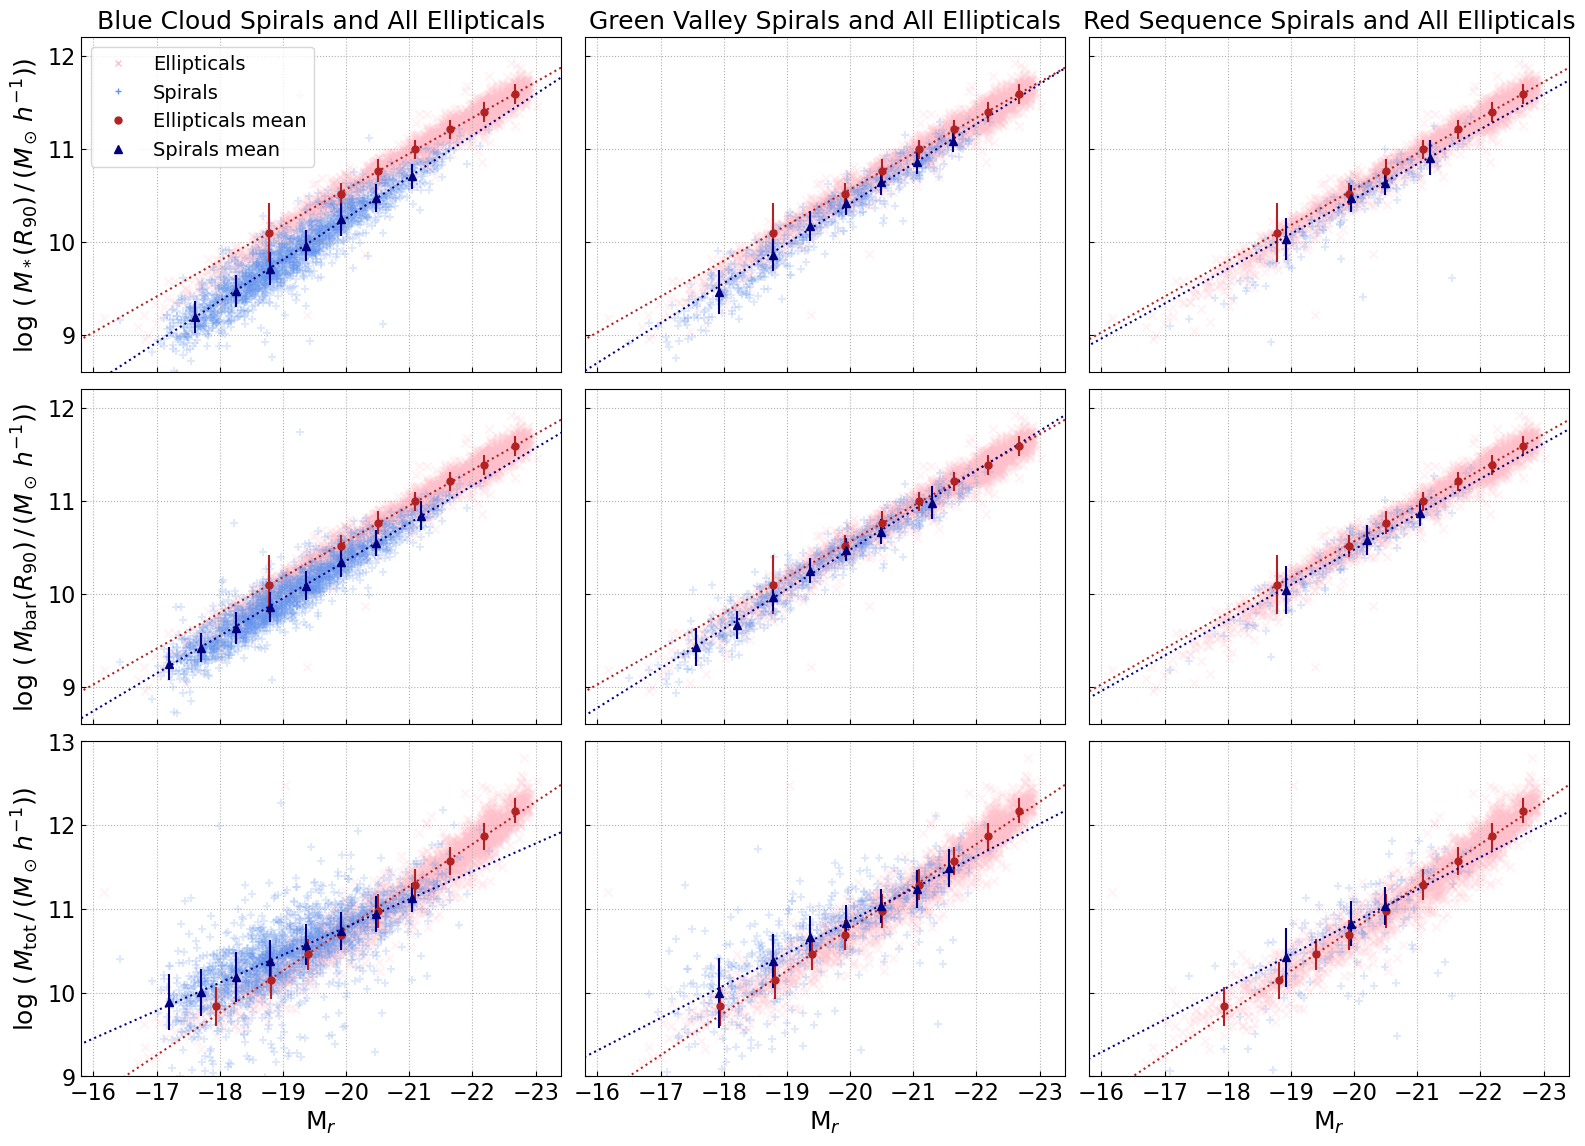

In [32]:
fig, ax = plt.subplots(3,3,sharex=True, sharey='row', figsize=(19.2,13.5))
mrs=np.linspace(-25, -15,1000)

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[2,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm bar}(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)


ax[0,0].set_yticks(np.arange(9,13,1))
ax[2,0].set_yticks(np.arange(9,14,1))
ax[2,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(8.6, 12.2)

# rs = np.linspace(-23.2,-17.2,100)


for i in range(0,3):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[2,i].set_xlabel(r'M$_r$', fontsize=18)
    
    ax[2,i].set_xticks(np.arange(-23,-15,1))
    ax[2,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[0,i].errorbar(e_mr_star_ctrs, e_mr_star_avgs, color='firebrick', yerr=e_mr_star_sigs, 
                 marker='o', linestyle='none', markersize=5, )
    ax[0,i].plot(mrs, e_mr_star_slope*mrs + e_mr_star_yint, color='firebrick', linestyle=':')

    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[1,i].errorbar(e_mr_star_ctrs, e_mr_star_avgs, color='firebrick', yerr=e_mr_star_sigs, 
                 marker='o', linestyle='none', markersize=5, )
    ax[1,i].plot(mrs, e_mr_star_slope*mrs + e_mr_star_yint, color='firebrick', linestyle=':')

    
    ax[2,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.2)
    ax[2,i].errorbar(e_mr_tot_ctrs,e_mr_tot_avgs, color='firebrick', yerr=e_mr_tot_sigs, 
                 marker='o',linestyle='none', markersize=5, )
    ax[2,i].plot(mrs, e_mr_tot_slope*mrs + e_mr_tot_yint, color='firebrick', linestyle=':')




legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_HI_spirals['rabsmag'], blue_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,0].errorbar(bs_mr_star_ctrs, bs_mr_star_avgs, color='navy', yerr=bs_mr_star_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,0].plot(mrs, bs_mr_star_slope*mrs + bs_mr_star_yint, color='navy', linestyle=':')

ax[0,1].scatter(green_HI_spirals['rabsmag'], green_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,1].errorbar(gs_mr_star_ctrs, gs_mr_star_avgs, color='navy', yerr=gs_mr_star_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,1].plot(mrs, gs_mr_star_slope*mrs + gs_mr_star_yint, color='navy', linestyle=':')

ax[0,2].scatter(red_HI_spirals['rabsmag'], red_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,2].errorbar(rs_mr_star_ctrs, rs_mr_star_avgs, color='navy', yerr=rs_mr_star_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,2].plot(mrs, rs_mr_star_slope*mrs + rs_mr_star_yint, color='navy', linestyle=':')



ax[1,0].scatter(blue_HI_spirals['rabsmag'], blue_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,0].errorbar(bs_mr_mbar_ctrs, bs_mr_mbar_avgs, color='navy', yerr=bs_mr_mbar_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,0].plot(mrs, bs_mr_mbar_slope*mrs + bs_mr_mbar_yint, color='navy', linestyle=':')


ax[1,1].scatter(green_HI_spirals['rabsmag'], green_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,1].errorbar(gs_mr_mbar_ctrs, gs_mr_mbar_avgs, color='navy', yerr=gs_mr_mbar_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,1].plot(mrs, gs_mr_mbar_slope*mrs + gs_mr_mbar_yint, color='navy', linestyle=':')


ax[1,2].scatter(red_HI_spirals['rabsmag'], red_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,2].errorbar(rs_mr_mbar_ctrs, rs_mr_mbar_avgs, color='navy', yerr=rs_mr_mbar_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,2].plot(mrs, rs_mr_mbar_slope*mrs + rs_mr_mbar_yint, color='navy', linestyle=':')





ax[2,0].scatter(blue_HI_spirals['rabsmag'], blue_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,0].errorbar(bs_mr_tot_ctrs, bs_mr_tot_avgs, color='navy', yerr=bs_mr_tot_sigs, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,0].plot(mrs, bs_mr_tot_slope*mrs + bs_mr_tot_yint, color='navy', linestyle=':')


ax[2,1].scatter(green_HI_spirals['rabsmag'], green_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,1].errorbar(gs_mr_tot_ctrs, gs_mr_tot_avgs, color='navy', yerr=gs_mr_tot_sigs, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,1].plot(mrs, gs_mr_tot_slope*mrs + gs_mr_tot_yint, color='navy', linestyle=':')


ax[2,2].scatter(red_HI_spirals['rabsmag'], red_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,2].errorbar(rs_mr_tot_ctrs, rs_mr_tot_avgs, color='navy', yerr=rs_mr_tot_sigs, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,2].plot(mrs, rs_mr_tot_slope*mrs + rs_mr_tot_yint, color='navy', linestyle=':')


fig.subplots_adjust(wspace=0.05, hspace=0.05)
fig.savefig(plot_dir + 'HI_spirals/Mtot_Mstar_Mbar_Mr_CMDspiral_ellipticals_refit.png', bbox_inches='tight')

### plot w vertical residuals

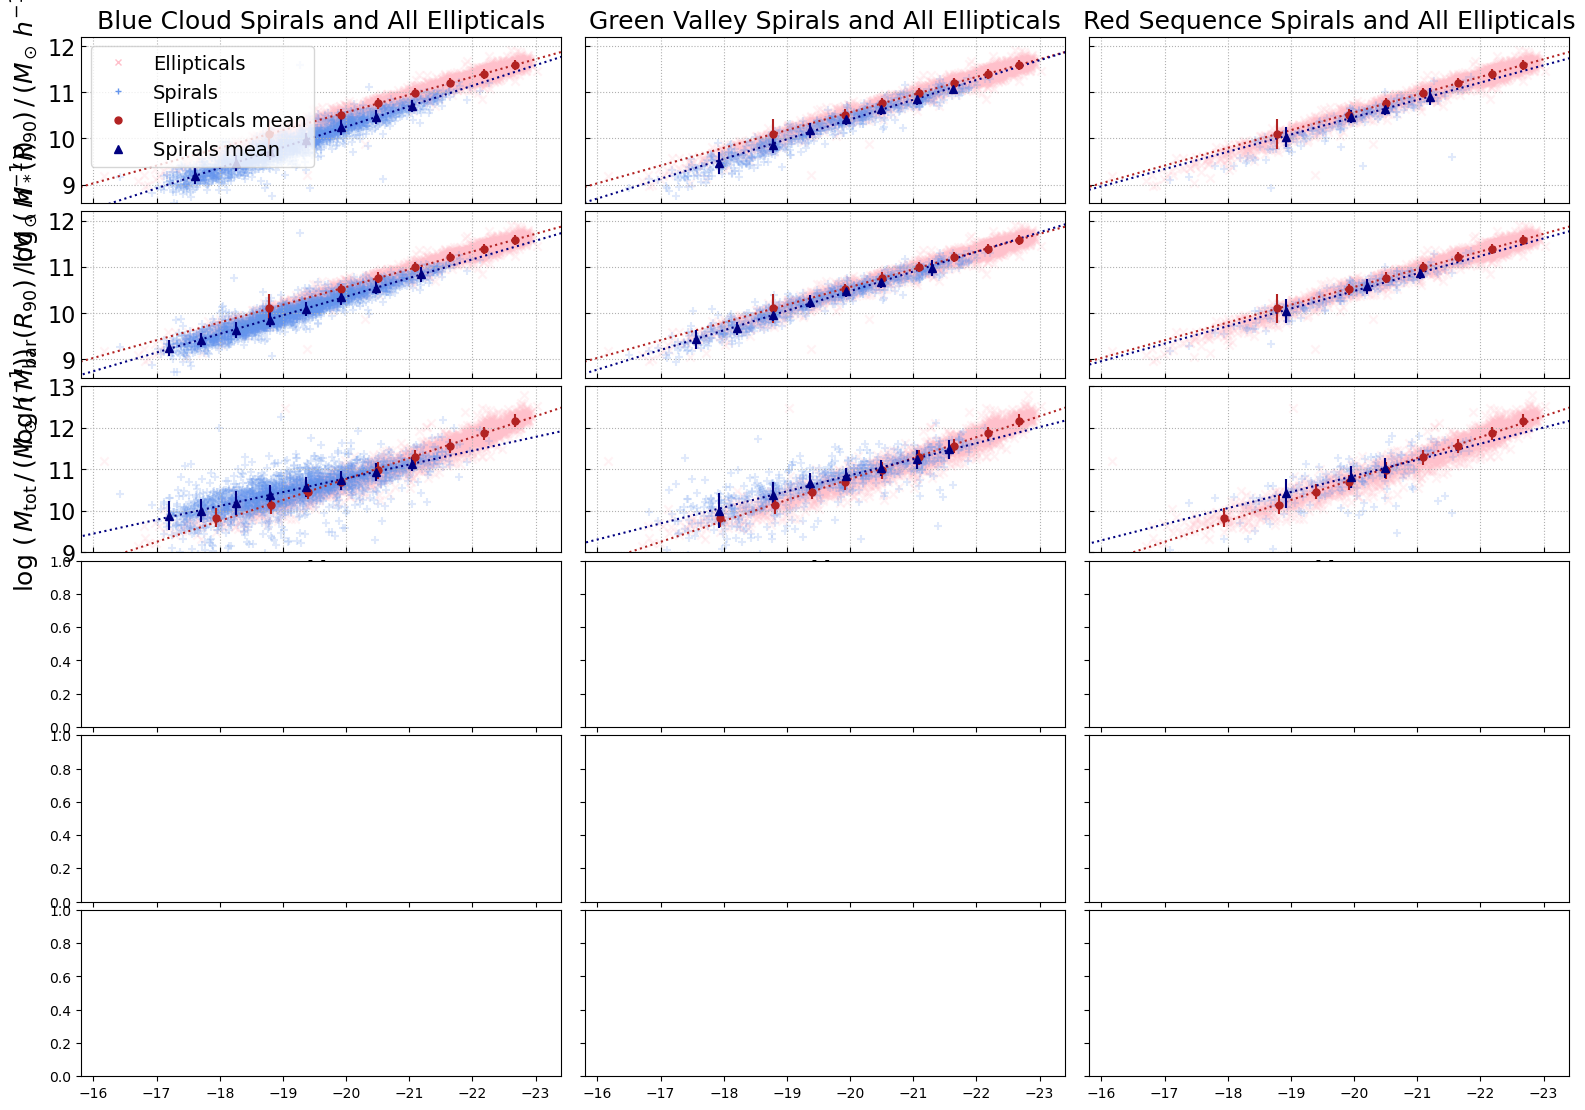

In [36]:
fig, ax = plt.subplots(6,3,sharex=True, sharey='row', figsize=(19.2,13.5))
mrs=np.linspace(-25, -15,1000)

# label plots
ax[0,0].set_title('Blue Cloud Spirals and All Ellipticals',fontsize=18)
ax[0,1].set_title('Green Valley Spirals and All Ellipticals',fontsize=18)
ax[0,2].set_title('Red Sequence Spirals and All Ellipticals', fontsize=18)
ax[0,0].set_ylabel(r'$\log\,(\,M_*(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[2,0].set_ylabel(r'$\log\,(\,M_{\rm tot}\,/\,(M_\odot\,h^{-1}))$',fontsize=18)
ax[1,0].set_ylabel(r'$\log\,(\,M_{\rm bar}(R_{90})\,/\,(M_\odot\,h^{-1}))$',fontsize=18)


ax[0,0].set_yticks(np.arange(9,13,1))
ax[2,0].set_yticks(np.arange(9,14,1))
ax[2,0].set_ylim(9,13)
ax[0,0].set_ylim(8.6, 12.2)
ax[0,0].set_yticks(np.arange(9,13,1))
ax[1,0].set_yticks(np.arange(9,14,1))
ax[1,0].set_ylim(8.6, 12.2)

# rs = np.linspace(-23.2,-17.2,100)


for i in range(0,3):
    for j in range(0,3):
        ax[i,j].tick_params( axis='both', direction='in', labelsize=16)
        ax[i,j].grid( linestyle=':')


for i in range(0,3):

    ax[2,i].set_xlabel(r'M$_r$', fontsize=18)
    
    ax[2,i].set_xticks(np.arange(-23,-15,1))
    ax[2,i].set_xlim(-15.8, -23.4)
    
    ax[0,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[0,i].errorbar(e_mr_star_ctrs, e_mr_star_avgs, color='firebrick', yerr=e_mr_star_sigs, 
                 marker='o', linestyle='none', markersize=5, )
    ax[0,i].plot(mrs, e_mr_star_slope*mrs + e_mr_star_yint, color='firebrick', linestyle=':')

    
    ax[1,i].scatter(ellipticals['rabsmag'], ellipticals['e_M_star_R90_h'], color='pink', marker='x', alpha=0.2)
    ax[1,i].errorbar(e_mr_star_ctrs, e_mr_star_avgs, color='firebrick', yerr=e_mr_star_sigs, 
                 marker='o', linestyle='none', markersize=5, )
    ax[1,i].plot(mrs, e_mr_star_slope*mrs + e_mr_star_yint, color='firebrick', linestyle=':')

    
    ax[2,i].scatter(ellipticals['rabsmag'], ellipticals['Mvir'], color='pink', marker='x', alpha=0.2)
    ax[2,i].errorbar(e_mr_tot_ctrs,e_mr_tot_avgs, color='firebrick', yerr=e_mr_tot_sigs, 
                 marker='o',linestyle='none', markersize=5, )
    ax[2,i].plot(mrs, e_mr_tot_slope*mrs + e_mr_tot_yint, color='firebrick', linestyle=':')




legend_elements = [Line2D([0], [0], marker='x', color='w', label='Ellipticals',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=5),
                   Line2D([0], [0], marker='+', color='w', label='Spirals',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=5),
                  Line2D([0], [0], marker='o', color='w', label='Ellipticals mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=5),
                  Line2D([0], [0], marker='^', color='w', label='Spirals mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6)]


ax[0,0].legend(handles=legend_elements,fontsize=14)



ax[0,0].scatter(blue_HI_spirals['rabsmag'], blue_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,0].errorbar(bs_mr_star_ctrs, bs_mr_star_avgs, color='navy', yerr=bs_mr_star_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,0].plot(mrs, bs_mr_star_slope*mrs + bs_mr_star_yint, color='navy', linestyle=':')

ax[0,1].scatter(green_HI_spirals['rabsmag'], green_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,1].errorbar(gs_mr_star_ctrs, gs_mr_star_avgs, color='navy', yerr=gs_mr_star_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,1].plot(mrs, gs_mr_star_slope*mrs + gs_mr_star_yint, color='navy', linestyle=':')

ax[0,2].scatter(red_HI_spirals['rabsmag'], red_HI_spirals['M90_disk_h'], color='cornflowerblue', marker='+', alpha=0.2)
ax[0,2].errorbar(rs_mr_star_ctrs, rs_mr_star_avgs, color='navy', yerr=rs_mr_star_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[0,2].plot(mrs, rs_mr_star_slope*mrs + rs_mr_star_yint, color='navy', linestyle=':')



ax[1,0].scatter(blue_HI_spirals['rabsmag'], blue_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,0].errorbar(bs_mr_mbar_ctrs, bs_mr_mbar_avgs, color='navy', yerr=bs_mr_mbar_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,0].plot(mrs, bs_mr_mbar_slope*mrs + bs_mr_mbar_yint, color='navy', linestyle=':')


ax[1,1].scatter(green_HI_spirals['rabsmag'], green_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,1].errorbar(gs_mr_mbar_ctrs, gs_mr_mbar_avgs, color='navy', yerr=gs_mr_mbar_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,1].plot(mrs, gs_mr_mbar_slope*mrs + gs_mr_mbar_yint, color='navy', linestyle=':')


ax[1,2].scatter(red_HI_spirals['rabsmag'], red_spirals_mbar, 
                color='cornflowerblue', marker='+', alpha=0.2)
ax[1,2].errorbar(rs_mr_mbar_ctrs, rs_mr_mbar_avgs, color='navy', yerr=rs_mr_mbar_sigs, 
                 marker='^',linestyle='none', markersize=6,)
ax[1,2].plot(mrs, rs_mr_mbar_slope*mrs + rs_mr_mbar_yint, color='navy', linestyle=':')





ax[2,0].scatter(blue_HI_spirals['rabsmag'], blue_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,0].errorbar(bs_mr_tot_ctrs, bs_mr_tot_avgs, color='navy', yerr=bs_mr_tot_sigs, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,0].plot(mrs, bs_mr_tot_slope*mrs + bs_mr_tot_yint, color='navy', linestyle=':')


ax[2,1].scatter(green_HI_spirals['rabsmag'], green_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,1].errorbar(gs_mr_tot_ctrs, gs_mr_tot_avgs, color='navy', yerr=gs_mr_tot_sigs, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,1].plot(mrs, gs_mr_tot_slope*mrs + gs_mr_tot_yint, color='navy', linestyle=':')


ax[2,2].scatter(red_HI_spirals['rabsmag'], red_HI_spirals['M_R90'], color='cornflowerblue', marker='+', alpha=0.2, label='blue cloud spirals')
ax[2,2].errorbar(rs_mr_tot_ctrs, rs_mr_tot_avgs, color='navy', yerr=rs_mr_tot_sigs, 
                 marker='^', label='blue cloud spiral median',linestyle='none', markersize=6,)
ax[2,2].plot(mrs, rs_mr_tot_slope*mrs + rs_mr_tot_yint, color='navy', linestyle=':')


fig.subplots_adjust(wspace=0.05, hspace=0.05)
# fig.savefig(plot_dir + 'HI_spirals/Mtot_Mstar_Mbar_Mr_CMDspiral_ellipticals_refit.png', bbox_inches='tight')

## fig 11 and 12 BTFR for matched samples

### set up

In [23]:
e_match_mask = np.logical_and(manga_sample['elliptical_mask'] == 1, manga_sample['illustris_match'] >= 0)
s_match_mask = HI_spirals['illustris_match'] >= 0

In [24]:
e_manga_mbar = manga_sample[e_match_mask]['sphd_M_star_h']
e_tng_mbar = manga_sample[e_match_mask]['illustris_Mstar_Sal']

In [25]:
s_match = HI_spirals[s_match_mask]
e_match = manga_sample[e_match_mask]

In [26]:
s_tng_mbar = np.zeros(len(s_match))

for i in range(len(s_match)):

    mbar = 0
    
    if s_match['illustris_Mstar_Sal'][i] >= 0:
        mbar += 10**(s_match['illustris_Mstar_Sal'][i])

    if s_match['illustris_MH'][i] >= 0:
        mbar += 10**(s_match['illustris_MH'][i])

    if s_match['illustris_MHe'][i] >= 0:
        mbar += 10**(s_match['illustris_MHe'][i])

    s_tng_mbar[i] = np.log10(mbar)

In [27]:
s_manga_mbar = np.log10(10**s_match['sphd_M_star_h'] + 10**s_match['logHI_h'] + 10**s_match['param_H2_h'] + 10**s_match['param_He_h'])

In [28]:
min_mvis = np.min([np.min(s_manga_mbar), np.min(s_tng_mbar),
                   np.min(e_tng_mbar), np.min(e_manga_mbar)])

max_mvis = np.max([np.max(s_tng_mbar), np.max(s_manga_mbar),
                   np.max(e_tng_mbar), np.max(e_manga_mbar)])

mvis_bins = np.linspace(min_mvis, max_mvis + 0.1, 15)

In [29]:
e_manga_vrot = e_match['v_eff']
e_tng_vrot = e_match['illustris_Vmax']
s_manga_vrot = s_match['v_max']
s_tng_vrot = s_match['illustris_Vmax']

### manga ellipticals

In [30]:
mvis_bins = np.concatenate((np.linspace(7.5, 12.5,15), np.array([27.2])))

In [31]:
e_veff = []
e_veff_ctr = []
e_mvis_bins = mvis_bins
e_mvis_bins = np.concatenate((mvis_bins[:0], mvis_bins[5:-4], mvis_bins[-1:]))
indices = np.digitize(e_manga_mbar, e_mvis_bins)

for i in range(1, len(e_mvis_bins)):

    e_veff.append(np.log10(e_manga_vrot)[indices==i])
    e_veff_ctr.append(np.mean(e_manga_mbar[indices==i]))

e_mvis_veff_avg, e_mvis_veff_sig = fit_to_gaussian(e_veff, plot_dir = plot_dir +'/BTFR/ellipticals_manga/', 
                                                         plot_name='e_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                  plot_bins=e_mvis_bins, xlab=r'$V_{\rm eff}$')



#### mcmc

In [32]:
plt.hist(1/x0[:,0])

NameError: name 'x0' is not defined

In [34]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(e_veff_ctr), e_mvis_veff_avg, e_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

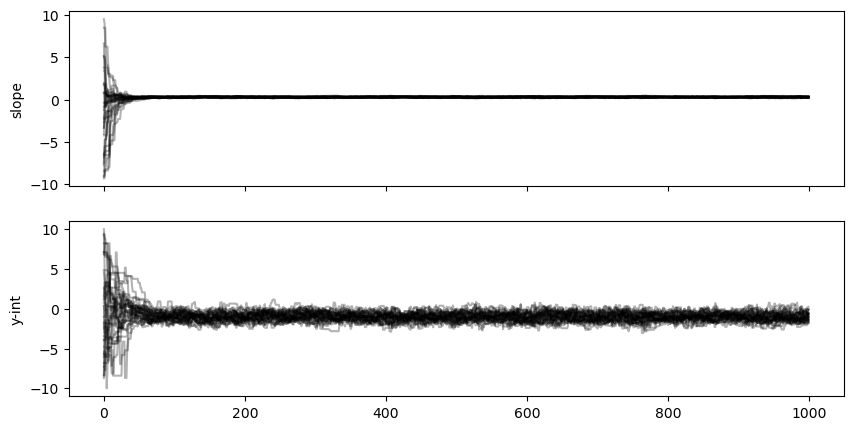

In [35]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])


In [36]:
tau = sampler.get_autocorr_time()
eflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

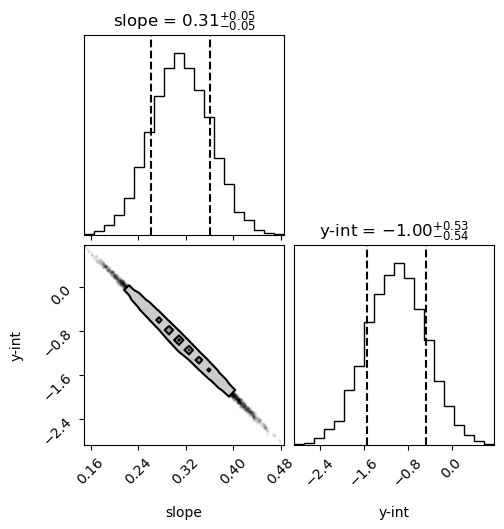

In [37]:
fig = corner.corner(eflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

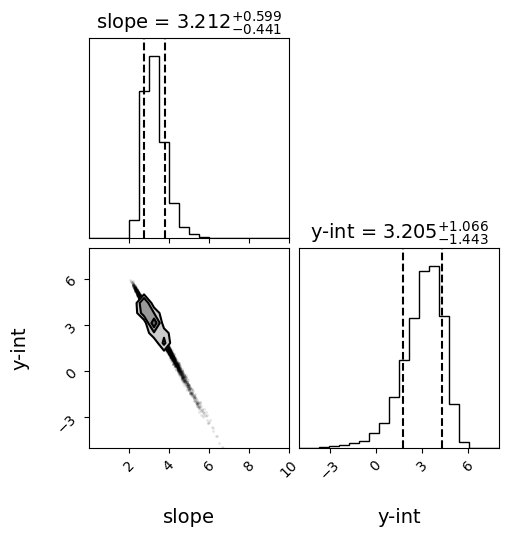

In [38]:
eflat_samples_flip = np.array([1/eflat_samples[:,0], -eflat_samples[:,1]/eflat_samples[:,0]]).transpose()
fig = corner.corner(eflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                    
                   #plot_density=1,
                    range=((0,10),(-5,8))
                    
                   )

# plt.tick_params(labelsize=14)


plt.savefig(plot_dir + '/BTFR/ellipticals_manga/' + 'manga_ellipticals_corner.png', bbox_inches='tight')

In [39]:
e_slope = np.percentile(eflat_samples_flip[:,0],50)
e_slope_bounds = [np.percentile(eflat_samples_flip[:,0],16), np.percentile(eflat_samples_flip[:,0],84)]
e_yint = np.percentile(eflat_samples_flip[:,1],50)
e_yint_bounds = [np.percentile(eflat_samples_flip[:,1],16), np.percentile(eflat_samples_flip[:,1],84)]
e_chi2 = chi2_norm(lin_fit(np.array(e_veff_ctr), np.percentile(eflat_samples[:,0],50), 
                           np.percentile(eflat_samples[:,1],50)), e_mvis_veff_avg, e_mvis_veff_sig, 2)

In [40]:
vs = np.linspace(0,5,1000)

N_samples = len(eflat_samples_flip)
ys = []
for i in range(N_samples):
    ys.append(eflat_samples_flip[:,0][i]*vs + eflat_samples_flip[:,1][i])

e_ys_array = np.asarray(ys)
e_ys_err = np.nanpercentile(e_ys_array, [16 ,84], axis=0)

In [41]:
# first sample the gaussian dist of our data pts

veff_samples = np.zeros((len(e_mvis_veff_avg), 1000))
for i in range(len(e_mvis_veff_avg)):
                             
    veff_samples[i] = np.random.normal(e_mvis_veff_avg[i], e_mvis_veff_sig[i], 1000) # want this to produce 1000 samples for each y pt

# for each set of samples, minimize residual?
bs = np.linspace(-3,3,1000)
e_yints_fixed_array = np.zeros(1000)
for i in tqdm(range(1000)):
    e_res_fixed = np.zeros(len(bs))
    for j in range(len(bs)):
            e_res_fixed[j] = np.sum((lin_fit(np.array(e_veff_ctr), 0.25, bs[j]) - veff_samples[:,i])**2)
        
    e_yints_fixed_array[i] = bs[np.argmin(e_res_fixed)]

100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 186.45it/s]


In [42]:
e_yint_fixed = np.average(e_yints_fixed_array)
e_yint_fixed_err = np.std(e_yints_fixed_array)
e_chi2_fixed_min = chi2_norm(lin_fit(np.array(e_veff_ctr), 0.25, e_yint_fixed), e_mvis_veff_avg, e_mvis_veff_sig, 1)
print(e_chi2_fixed_min)
print(e_yint_fixed)
print(e_yint_fixed_err)

0.37442570427493505
-0.34947147147147156
0.03959002764848905


In [85]:
# write data to a file 
f = open(plot_dir + '/BTFR/ellipticals_manga/data.txt', 'x')
f.write('e_veff_centers \n')
f.write(str(e_veff_ctr) + '\n')
f.write('e_mvis_avgs \n')
f.write(str(e_mvis_veff_avg)+ '\n')
f.write('e_mvis_sigs \n')
f.write(str(e_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(e_slope) + str(e_slope_bounds-e_slope)+ '\n')
f.write('y-int \n')
f.write(str(e_yint) + str(e_yint_bounds-e_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(e_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-e_yint_fixed*4) + '\n')
f.write('fixed slope 4 y-int err \n')
f.write(str(-e_yint_fixed_err*4) + '\n')
f.write('chi2 nu \n')
f.write(str(e_chi2_fixed_min))


f.close()



### tng ellipticals

In [43]:
ie_veff = []
ie_veff_ctr = []
ie_mvis_bins = mvis_bins
ie_mvis_bins = np.concatenate((mvis_bins[:0], mvis_bins[5:-4], mvis_bins[-1:]))
indices = np.digitize(e_match['illustris_Mstar_Sal'], ie_mvis_bins)

for i in range(1, len(ie_mvis_bins)):

    ie_veff.append(np.log10(e_match['v_eff'])[indices==i])
    ie_veff_ctr.append(np.mean(e_match['illustris_Mstar_Sal'][indices==i]))

ie_mvis_veff_avg, ie_mvis_veff_sig = fit_to_gaussian(ie_veff, plot_dir = plot_dir +'/BTFR/ellipticals_tng/', 
                                                         plot_name='e_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                     plot_bins=ie_mvis_bins, xlab=r'$V_{\rm eff}$')



In [44]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(ie_veff_ctr), ie_mvis_veff_avg, ie_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

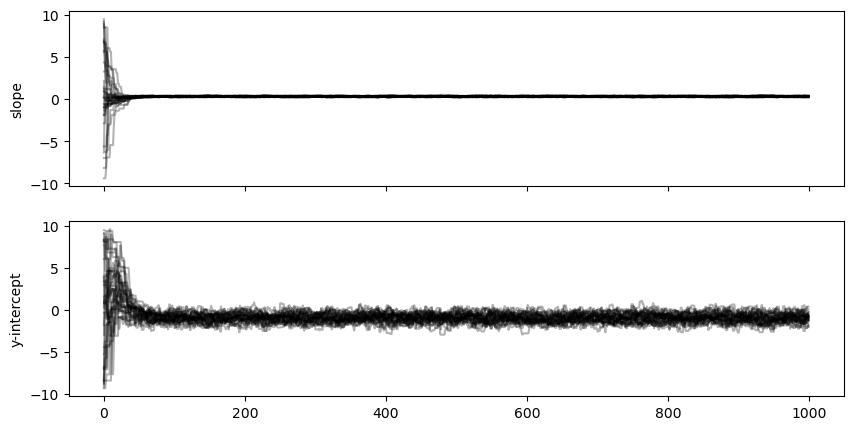

In [45]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-intercept']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])

In [46]:
tau = sampler.get_autocorr_time()
ieflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

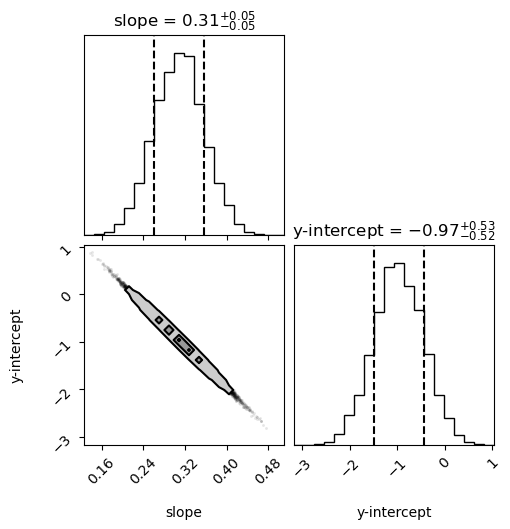

In [47]:
fig = corner.corner(ieflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

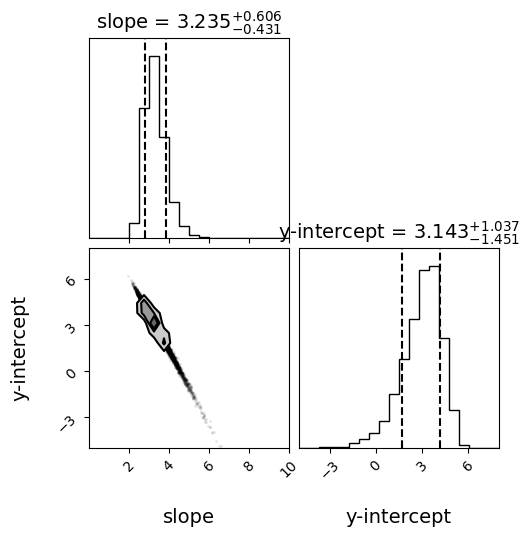

In [48]:
ieflat_samples_flip = np.array([1/ieflat_samples[:,0], -ieflat_samples[:,1]/ieflat_samples[:,0]]).transpose()
fig = corner.corner(ieflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                     range=((0,10),(-5,8))
                    
                   )

plt.savefig(plot_dir + '/BTFR/ellipticals_tng/' + 'tng_ellipticals_corner.png', bbox_inches='tight')

In [49]:
ie_slope = np.percentile(ieflat_samples_flip[:,0],50)
ie_slope_bounds = [np.percentile(ieflat_samples_flip[:,0],16), np.percentile(ieflat_samples_flip[:,0],84)]
ie_yint = np.percentile(ieflat_samples_flip[:,1],50)
ie_yint_bounds = [np.percentile(ieflat_samples_flip[:,1],16), np.percentile(ieflat_samples_flip[:,1],84)]
ie_chi2 = chi2_norm(lin_fit(np.array(ie_veff_ctr), np.percentile(ieflat_samples[:,0],50), 
                            np.percentile(ieflat_samples[:,1],50)), ie_mvis_veff_avg, ie_mvis_veff_sig, 2)

In [50]:
# first sample the gaussian dist of our data pts

veff_samples = np.zeros((len(ie_mvis_veff_avg), 1000))
for i in range(len(ie_mvis_veff_avg)):
                             
    veff_samples[i] = np.random.normal(ie_mvis_veff_avg[i], ie_mvis_veff_sig[i], 1000) # want this to produce 1000 samples for each y pt

# for each set of samples, minimize residual?
bs = np.linspace(-3,3,1000)
ie_yints_fixed_array = np.zeros(1000)
for i in tqdm(range(1000)):
    ie_res_fixed = np.zeros(len(bs))
    for j in range(len(bs)):
            ie_res_fixed[j] = np.sum((lin_fit(np.array(ie_veff_ctr), 0.25, bs[j]) - veff_samples[:,i])**2)
        
    ie_yints_fixed_array[i] = bs[np.argmin(ie_res_fixed)]

100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 185.74it/s]


In [51]:
ie_yint_fixed = np.average(ie_yints_fixed_array)
ie_yint_fixed_err = np.std(ie_yints_fixed_array)
ie_chi2_fixed_min = chi2_norm(lin_fit(np.array(ie_veff_ctr), 0.25, ie_yint_fixed), ie_mvis_veff_avg, ie_mvis_veff_sig, 1)
print(ie_chi2_fixed_min)
print(ie_yint_fixed)
print(ie_yint_fixed_err)

0.3444637674526824
-0.3464384384384384
0.03935876282748747


In [95]:
# write data to a file 
f = open(plot_dir + '/BTFR/ellipticals_tng/data.txt', 'x')
f.write('e_veff_centers \n')
f.write(str(ie_veff_ctr) + '\n')
f.write('e_mvis_avgs \n')
f.write(str(ie_mvis_veff_avg)+ '\n')
f.write('e_mvis_sigs \n')
f.write(str(ie_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(ie_slope) + str(ie_slope_bounds-ie_slope)+ '\n')
f.write('y-int \n')
f.write(str(ie_yint) + str(ie_yint_bounds-ie_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(ie_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-ie_yint_fixed*5) + '\n')
f.write('fixed slope 4 y-int err \n')
f.write(str(-ie_yint_fixed_err*4) + '\n')
f.write('chi2 nu \n')
f.write(str(ie_chi2_fixed_min))


f.close()



### ellipticals corner plot

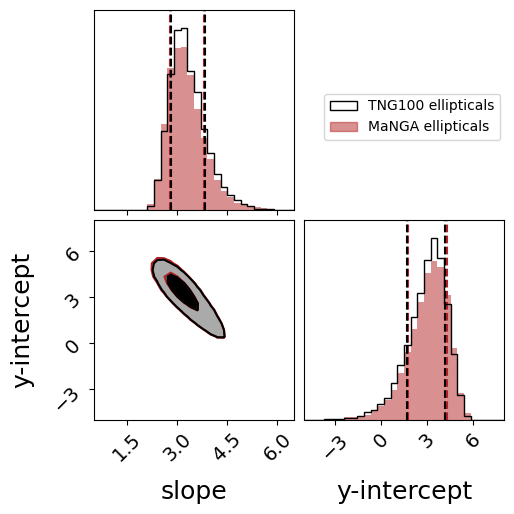

In [52]:
labels = ['slope', 'y-intercept']

fig = corner.corner(eflat_samples_flip, color='firebrick',
                   quantiles=(0.16, 0.84),
                    bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
                    hist_kwargs={'color':'firebrick', 'histtype': 'stepfilled', 'alpha':0.5},
                     range=((0.5,6.5),(-5,8)),
                smooth=1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
                   plot_datapoints=False)
                    
                   
corner.corner(ieflat_samples_flip, fig=fig, labels=labels,
             quantiles=(0.16, 0.84),
              bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
              range=((0.5,6.5),(-5,8)),
             smooth=1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             plot_datapoints=False)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=14)


legend_elements = [Patch(facecolor='none', edgecolor='k', label='TNG100 ellipticals'),
                   Patch(facecolor='firebrick', alpha=0.5, edgecolor='firebrick', label='MaNGA ellipticals')
                  ]

plt.legend(handles=legend_elements, loc=(0.1,1.4))

plt.savefig(plot_dir + '/BTFR/' + 'ellipticals_corner_refit.png', bbox_inches='tight')

### manga spirals

In [53]:
s_veff = []
s_veff_ctr = []
s_mvis_bins = mvis_bins
s_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[6:-5], mvis_bins[-1:]))
indices = np.digitize(s_manga_mbar, s_mvis_bins)

for i in range(1, len(s_mvis_bins)):

    s_veff.append(np.log10(s_manga_vrot)[indices==i])
    s_veff_ctr.append(np.mean(s_manga_mbar[indices==i]))

s_mvis_veff_avg, s_mvis_veff_sig = fit_to_gaussian(s_veff, plot_dir = plot_dir +'/BTFR/spirals_manga/', 
                                                         plot_name='s_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                  plot_bins=s_mvis_bins, xlab=r'$V_{\rm eff}$')



/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [54]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(s_veff_ctr), s_mvis_veff_avg, s_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

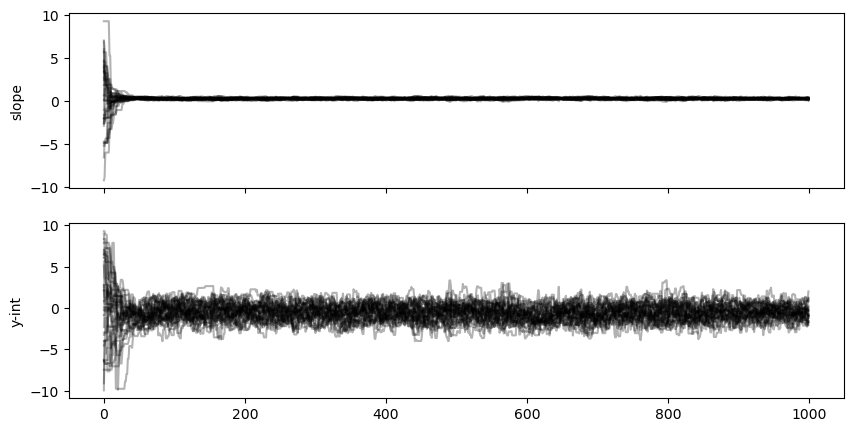

In [55]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

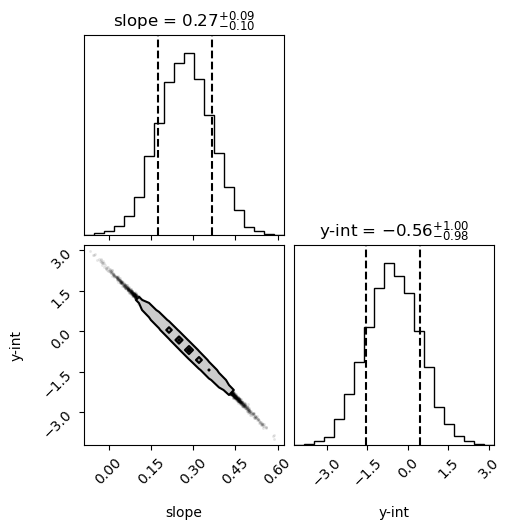

In [56]:
tau = sampler.get_autocorr_time()
sflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(sflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

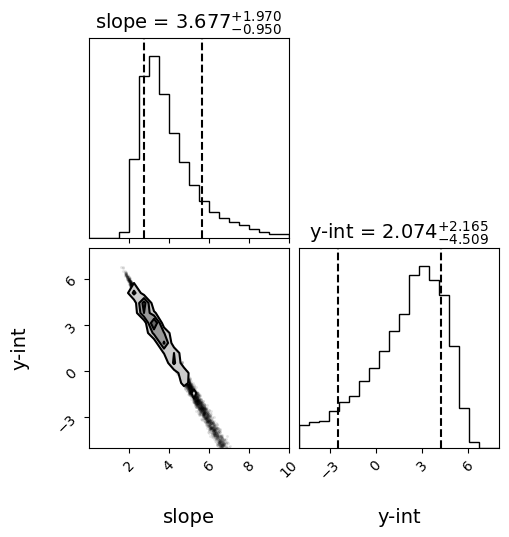

In [57]:
sflat_samples_flip = np.array([1/sflat_samples[:,0], -sflat_samples[:,1]/sflat_samples[:,0]]).transpose()
fig = corner.corner(sflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                   title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                     range=((0,10),(-5,8))
                    
                   )

plt.savefig(plot_dir + '/BTFR/spirals_manga/' + 'manga_spirals_corner.png', bbox_inches='tight')

In [58]:
s_slope = np.percentile(sflat_samples_flip[:,0],50)
s_slope_bounds = [np.percentile(sflat_samples_flip[:,0],16), np.percentile(sflat_samples_flip[:,0],84)]
s_yint = np.percentile(sflat_samples_flip[:,1],50)
s_yint_bounds = [np.percentile(sflat_samples_flip[:,1],16), np.percentile(sflat_samples_flip[:,1],84)]
s_chi2 = chi2_norm(lin_fit(np.array(s_veff_ctr), np.percentile(sflat_samples[:,0],50), 
                           np.percentile(sflat_samples[:,1],50)), s_mvis_veff_avg, s_mvis_veff_sig, 2)

In [59]:
# first sample the gaussian dist of our data pts

veff_samples = np.zeros((len(s_mvis_veff_avg), 1000))
for i in range(len(s_mvis_veff_avg)):
                             
    veff_samples[i] = np.random.normal(s_mvis_veff_avg[i], s_mvis_veff_sig[i], 1000) # want this to produce 1000 samples for each y pt

# for each set of samples, minimize residual?
bs = np.linspace(-3,3,1000)
s_yints_fixed_array = np.zeros(1000)
for i in tqdm(range(1000)):
    s_res_fixed = np.zeros(len(bs))
    for j in range(len(bs)):
            s_res_fixed[j] = np.sum((lin_fit(np.array(s_veff_ctr), 0.25, bs[j]) - veff_samples[:,i])**2)
        
    s_yints_fixed_array[i] = bs[np.argmin(s_res_fixed)]

100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 184.18it/s]


In [60]:
s_yint_fixed = np.average(s_yints_fixed_array)
s_yint_fixed_err = np.std(s_yints_fixed_array)
s_chi2_fixed_min = chi2_norm(lin_fit(np.array(s_veff_ctr), 0.25, s_yint_fixed), s_mvis_veff_avg, s_mvis_veff_sig, 1)
print(s_chi2_fixed_min)
print(s_yint_fixed)
print(s_yint_fixed_err)

0.014940076167951205
-0.3326666666666667
0.052655473306574795


In [61]:
# write data to a file 
f = open(plot_dir + '/BTFR/spirals_manga/data.txt', 'x')
f.write('s_veff_centers \n')
f.write(str(s_veff_ctr) + '\n')
f.write('s_mvis_avgs \n')
f.write(str(s_mvis_veff_avg)+ '\n')
f.write('s_mvis_sigs \n')
f.write(str(s_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(s_slope) + str(s_slope_bounds-s_slope)+ '\n')
f.write('y-int \n')
f.write(str(s_yint) + str(s_yint_bounds-s_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(s_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-s_yint_fixed*4) + '\n')
f.write('fixed slope 4 y-int err \n')
f.write(str(-s_yint_fixed_err*4) + '\n')
f.write('chi2 nu \n')
f.write(str(s_chi2_fixed_min))


f.close()



FileExistsError: [Errno 17] File exists: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax//BTFR/spirals_manga/data.txt'

### tng spirals

In [62]:
is_veff = []
is_veff_ctr = []
is_mvis_bins = mvis_bins
is_mvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[6:-6], mvis_bins[-1:]))
indices = np.digitize(s_tng_mbar, is_mvis_bins)

for i in range(1, len(is_mvis_bins)):

    is_veff.append(np.log10(s_tng_vrot)[indices==i])
    is_veff_ctr.append(np.mean(s_tng_mbar[indices==i]))

is_mvis_veff_avg, is_mvis_veff_sig = fit_to_gaussian(is_veff, plot_dir = plot_dir +'/BTFR/spirals_tng/',
                                                         plot_name='s_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                        plot_bins=is_mvis_bins, xlab=r'$V_{\rm eff}$')



In [63]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(is_veff_ctr), is_mvis_veff_avg, is_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

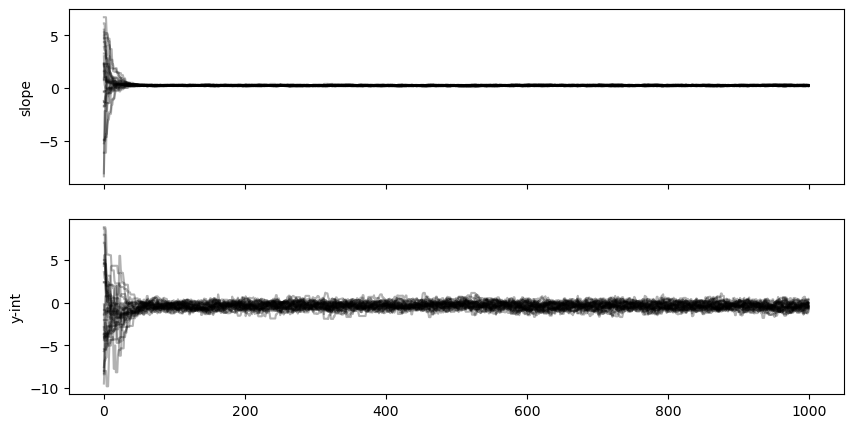

In [64]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

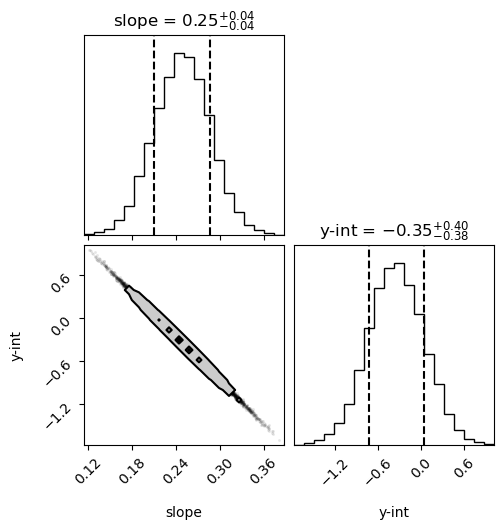

In [65]:
tau = sampler.get_autocorr_time()
isflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(isflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                     show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

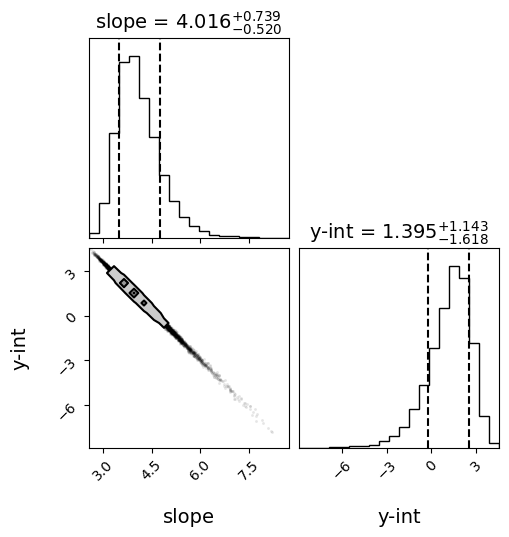

In [66]:
isflat_samples_flip = np.array([1/isflat_samples[:,0], -isflat_samples[:,1]/isflat_samples[:,0]]).transpose()
fig = corner.corner(isflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                    
                   )

plt.savefig(plot_dir + '/BTFR/spirals_tng/' + 'tng_spirals_corner.png', bbox_inches='tight')

In [67]:
is_slope = np.percentile(isflat_samples_flip[:,0],50)
is_slope_bounds = [np.percentile(isflat_samples_flip[:,0],16), np.percentile(isflat_samples_flip[:,0],84)]
is_yint = np.percentile(isflat_samples_flip[:,1],50)
is_yint_bounds = [np.percentile(isflat_samples_flip[:,1],16), np.percentile(isflat_samples_flip[:,1],84)]
is_chi2 = chi2_norm(lin_fit(np.array(is_veff_ctr), np.percentile(isflat_samples[:,0],50),
                            np.percentile(isflat_samples[:,1],50)), is_mvis_veff_avg, is_mvis_veff_sig, 2)

In [68]:
# first sample the gaussian dist of our data pts

veff_samples = np.zeros((len(is_mvis_veff_avg), 1000))
for i in range(len(is_mvis_veff_avg)):
                             
    veff_samples[i] = np.random.normal(is_mvis_veff_avg[i], is_mvis_veff_sig[i], 1000) # want this to produce 1000 samples for each y pt

# for each set of samples, minimize residual?
bs = np.linspace(-3,3,1000)
is_yints_fixed_array = np.zeros(1000)
for i in tqdm(range(1000)):
    is_res_fixed = np.zeros(len(bs))
    for j in range(len(bs)):
            is_res_fixed[j] = np.sum((lin_fit(np.array(is_veff_ctr), 0.25, bs[j]) - veff_samples[:,i])**2)
        
    is_yints_fixed_array[i] = bs[np.argmin(is_res_fixed)]

100%|██████████████████████████████████████| 1000/1000 [00:05<00:00, 188.86it/s]


In [69]:
is_yint_fixed = np.average(is_yints_fixed_array)
is_yint_fixed_err = np.std(is_yints_fixed_array)
is_chi2_fixed_min = chi2_norm(lin_fit(np.array(is_veff_ctr), 0.25, is_yint_fixed), is_mvis_veff_avg, is_mvis_veff_sig, 1)
print(is_chi2_fixed_min)
print(is_yint_fixed)
print(is_yint_fixed_err)

0.06271324652065613
-0.3551351351351352
0.01892520987926896


In [ ]:
# write data to a file 
f = open(plot_dir + '/BTFR/spirals_tng/data.txt', 'x')
f.write('s_veff_centers \n')
f.write(str(is_veff_ctr) + '\n')
f.write('s_mvis_avgs \n')
f.write(str(is_mvis_veff_avg)+ '\n')
f.write('s_mvis_sigs \n')
f.write(str(is_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(is_slope) + str(is_slope_bounds-is_slope)+ '\n')
f.write('y-int \n')
f.write(str(is_yint) + str(is_yint_bounds-is_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(is_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-is_yint_fixed*4) + '\n')
f.write('fixed slope 4 y-int err \n')
f.write(str(-is_yint_fixed_err*4) + '\n')
f.write('chi2 nu \n')
f.write(str(is_chi2_fixed_min))


f.close()



### spirals corner plot

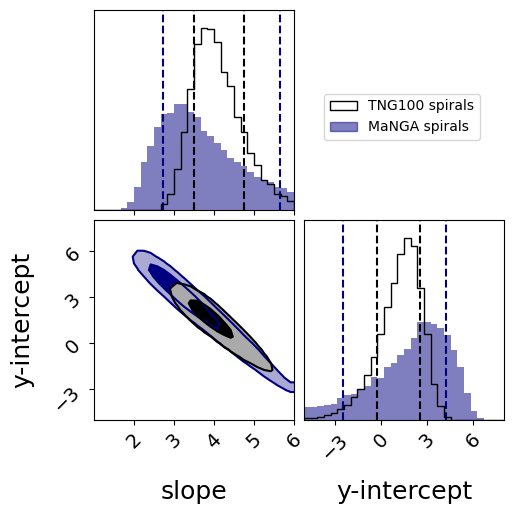

In [70]:
labels = ['slope', 'y-intercept']

fig = corner.corner(sflat_samples_flip, color='navy',
                   quantiles=(0.16, 0.84),
                    bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
                    hist_kwargs={'color':'navy', 'histtype': 'stepfilled', 'alpha':0.5},
                     range=((1,6),(-5,8)),
                    smooth=1,
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)),
                    plot_datapoints=False
                    
                   )
corner.corner(isflat_samples_flip, fig=fig, labels=labels,
             quantiles=(0.16, 0.84),
              bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
               range=((1,6),(-5,8)),
             smooth=1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
             plot_datapoints=False)

for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=14)


legend_elements = [Patch(facecolor='none', edgecolor='k', label='TNG100 spirals'),
                   Patch(facecolor='navy', alpha=0.5, edgecolor='navy', label='MaNGA spirals')
                  ]

plt.legend(handles=legend_elements, loc=(0.1,1.4))


    
plt.savefig(plot_dir + '/BTFR/' + 'spirals_corner_refit.png', bbox_inches='tight')

### BTFR scatter plot

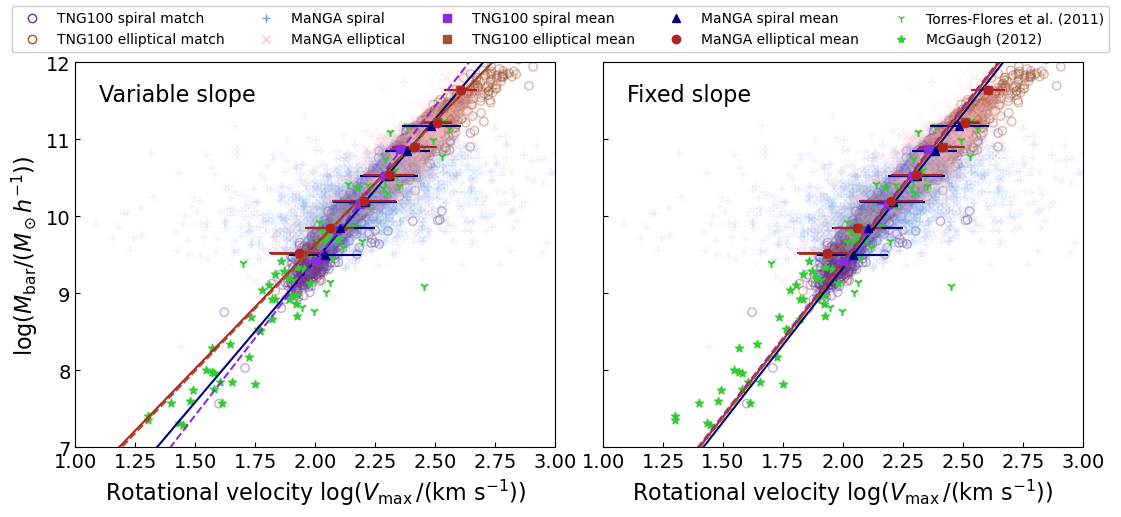

In [71]:
fig, ax  = plt.subplots(1,2, figsize=(13,5), sharey=True)

for i in range(2):

    ax[i].scatter(np.log10(s_tng_vrot), s_tng_mbar, marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4, label='Spirals')
    ax[i].scatter(np.log10(e_tng_vrot), e_tng_mbar, marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
    ax[i].scatter(np.log10(s_manga_vrot), s_manga_mbar, marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')
    
    ax[i].scatter(np.log10(e_manga_vrot), e_manga_mbar, marker='x', color='pink', alpha=0.1, label='Ellipticals')


    ax[i].errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig, linestyle='none',
                marker='s', color='blueviolet')
    ax[i].errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig, linestyle='none',
                marker='s', color='sienna')
    ax[i].errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
                marker='^', color='navy')
    ax[i].errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
                marker='o', color='firebrick')
    ax[i].set_xlim(1,3)
    ax[i].set_ylim(7,12)
    ax[i].tick_params( axis='both', direction='in', labelsize=14)
    ax[i].set_xlabel(r'Rotational velocity $\log(V_{\rm max}\,/(\text{km s}^{-1}))$', fontsize=16)

    ax[i].scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='*', color='limegreen', label='McGaugh (2012)')
    ax[i].scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='1', color='limegreen', s=40, label='Torres-Flores et al. (2011)')





ax[0].plot(vs, vs*s_slope + s_yint, color='navy')
ax[0].plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='--')
ax[0].plot(vs, vs*e_slope + e_yint, color='firebrick')
ax[0].plot(vs, vs*ie_slope + ie_yint, color='sienna', linestyle='--')

ms=np.linspace(5,15,100)

ax[1].plot(ms*0.25 + s_yint_fixed, ms, color='navy')
ax[1].plot(ms*0.25 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
ax[1].plot(ms*0.25 + e_yint_fixed, ms, color='firebrick')
ax[1].plot(ms*0.25 + ie_yint_fixed, ms, color='sienna', linestyle='--')

# ax[1].plot(vs, vs*4 + s_yint_fixed, color='navy')
# ax[1].plot(vs , vs*4 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
# ax[1].plot(vs, vs*4+ e_yint_fixed, ms, color='firebrick')
# ax[1].plot(vs, vs*4 + ie_yint_fixed, ms, color='sienna', linestyle='--')

ax[0].set_ylabel(r'$\log(M_{\rm bar}/(M_\odot h^{-1}))$', fontsize=16)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='TNG100 spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='TNG100 elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='TNG100 spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='TNG100 elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  
                  Line2D([0], [0], marker='1', color='w', label='Torres-Flores et al. (2011)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),
                  
                  Line2D([0], [0], marker='*', color='w', label='McGaugh (2012)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),]

fig.legend(handles=legend_elements, loc='upper center', framealpha=1, ncols=5)
fig.subplots_adjust(wspace=0.1, hspace=0.05)


ax[0].text(1.1,11.5, 'Variable slope', fontsize=16)
ax[1].text(1.1,11.5, 'Fixed slope', fontsize=16)


# plt.tight_layout()
plt.savefig(plot_dir + 'BTFR/BTFR_mstarhi_illustris_combined_refit.png', bbox_inches='tight')

### distance to best-fit btfr

In [72]:
ie_dist = (ie_yint + ie_slope*np.log10(e_match['illustris_Vmax']) - e_match['illustris_Mstar_Sal']) / np.sqrt(1 + ie_slope**2)

e_dist = (e_yint + e_slope*np.log10(e_match['v_eff']) -  e_match['sphd_M_star_h'] )/ np.sqrt(1 + e_slope**2)



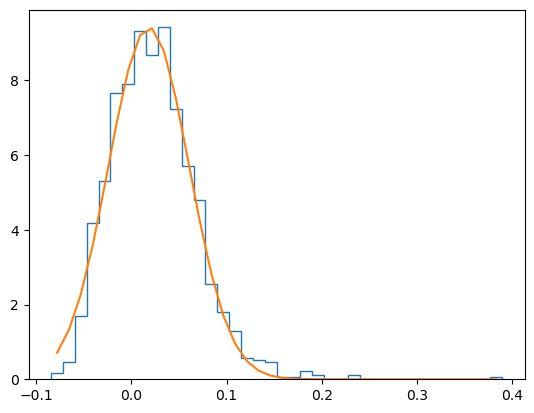

In [73]:
counts, bins = np.histogram(ie_dist,bins=int(np.sqrt(len(ie_dist))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
ie_dist_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(ie_dist),
                               np.std(ie_dist)])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, ie_dist_params[0], ie_dist_params[1]))

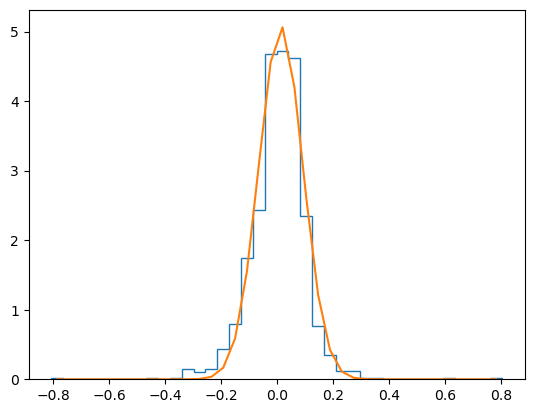

In [74]:
counts, bins = np.histogram(e_dist,bins=int(np.sqrt(len(e_dist))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
e_dist_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(e_dist),
                               np.std(e_dist)])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, e_dist_params[0], e_dist_params[1]))

In [75]:
print(r'data $\sigma_{\rm BTFR}$: ', e_dist_params[1])
print(r'sim $\sigma_{\rm BTFR}$: ', ie_dist_params[1])
print(r'$\sigma_{\rm measurement}$: ', np.sqrt(e_dist_params[1]**2  - ie_dist_params[1]**2))


data $\sigma_{\rm BTFR}$:  0.07860157233727344
sim $\sigma_{\rm BTFR}$:  0.04232948673122927
$\sigma_{\rm measurement}$:  0.06623006663866733


In [76]:
is_dist = (is_yint + is_slope*np.log10(s_tng_vrot) - s_tng_mbar) / np.sqrt(1 + is_slope**2)


s_dist = (s_yint + s_slope*np.log10(s_manga_vrot) -  s_manga_mbar)/ np.sqrt(1 + s_slope**2)



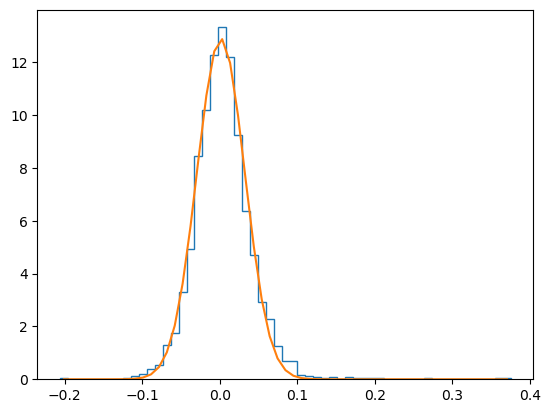

In [77]:
counts, bins = np.histogram(is_dist,bins=int(np.sqrt(len(is_dist))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
is_dist_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(is_dist),
                               np.std(is_dist)])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, is_dist_params[0], is_dist_params[1]))

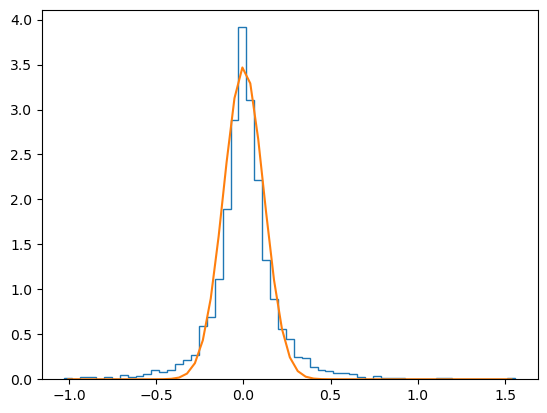

In [78]:
counts, bins = np.histogram(s_dist,bins=int(np.sqrt(len(s_dist))+1), density=True)
bin_ctrs = (bins[1:] + bins[:-1])/2
s_dist_params, _ = curve_fit(gaussian, bin_ctrs, counts, 
                          p0 = [np.mean(s_dist),
                               np.std(s_dist)])
plt.stairs(counts, bins)
plt.plot(bin_ctrs, gaussian(bin_ctrs, s_dist_params[0], s_dist_params[1]))

In [79]:
print(r'data $\sigma_{\rm BTFR}$: ', s_dist_params[1])
print(r'sim $\sigma_{\rm BTFR}$: ', is_dist_params[1])
print(r'$\sigma_{\rm measurement}$: ', np.sqrt(s_dist_params[1]**2  - is_dist_params[1]**2))


data $\sigma_{\rm BTFR}$:  0.11480054505856177
sim $\sigma_{\rm BTFR}$:  0.030950795752146897
$\sigma_{\rm measurement}$:  0.11054959696015068


### plot residuals

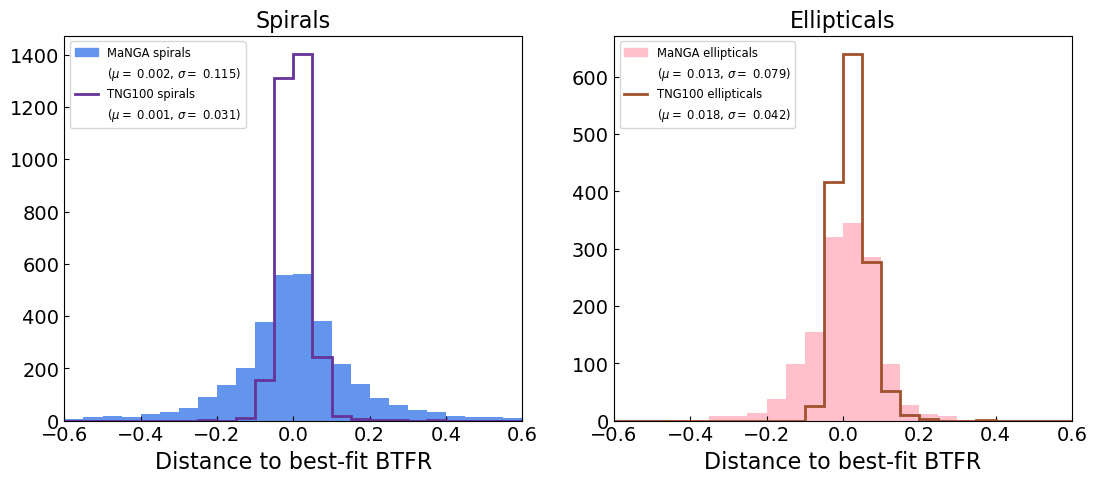

In [80]:

fig, ax  = plt.subplots(1,2, figsize=(13,5), sharey=0)


ax[0].hist(is_dist,  histtype='step', bins=np.arange(-0.8,0.8,0.05), color='rebeccapurple', linewidth=2)
ax[0].hist(s_dist, bins=np.arange(-0.8,0.8,0.05), color='cornflowerblue', linewidth=2)
ax[0].set_title('Spirals', fontsize=16)

for i in range(2):
    ax[i].set_xlim(-0.6, 0.6)
    ax[i].set_xlabel('Distance to best-fit BTFR', fontsize=16)
    ax[i].tick_params( axis='both', direction='in', labelsize=14)


legend_elements = [Patch(facecolor='cornflowerblue', edgecolor='cornflowerblue',
                         label=fr'MaNGA spirals'),
                   Patch(facecolor='w', edgecolor='w',
                         label=fr'($\mu =$ {s_dist_params[0]:.3f}, $\sigma =$ {s_dist_params[1]:.3f})'),
                  Line2D([0], [0], marker='none', color='rebeccapurple', label='TNG100 spirals',
                         linewidth=2),
                   Patch(facecolor='w', edgecolor='w',
                         label=fr'($\mu =$ {is_dist_params[0]:.3f}, $\sigma =$ {is_dist_params[1]:.3f})')]

ax[0].legend(handles=legend_elements, loc='upper left', fontsize='small')

# ax[0].text(-0.55,1200, 'Variable slope', fontsize=16)
# ax[1].text(-0.55,1200, 'Fixed slope', fontsize=16)

ax[1].hist(ie_dist,  histtype='step', bins=np.arange(-0.8,0.8,0.05), color='sienna', linewidth=2)
ax[1].hist(e_dist, bins=np.arange(-0.8,0.8,0.05), color='pink', linewidth=2)


# for i in range(2):
#     ax[i].set_xlim(-0.45, 0.45)
#     ax[i].set_xlabel('Distance to best-fit BTFR', fontsize=16)
#     ax[i].tick_params( axis='both', direction='in', labelsize=14)


legend_elements = [Patch(facecolor='pink', edgecolor='pink',
                         label=fr'MaNGA ellipticals'),
                    Patch(facecolor='w', edgecolor='w',
                         label=fr'($\mu =$ {e_dist_params[0]:.3f}, $\sigma =$ {e_dist_params[1]:.3f})'),
                  Line2D([0], [0], marker='none', color='sienna', label='TNG100 ellipticals',
                         linewidth=2),
                    Patch(facecolor='w', edgecolor='w',
                         label=fr'($\mu =$ {ie_dist_params[0]:.3f}, $\sigma =$ {ie_dist_params[1]:.3f})')]

ax[1].legend(handles=legend_elements, fontsize='small', loc='upper left')

ax[1].set_title('Ellipticals', fontsize=16)

# ax[0].text(-0.4,500, 'Variable slope', fontsize=16)


plt.savefig(plot_dir + 'BTFR/BTFR_mstarhi_illustris_combined_refit_perpdist_var_slope.png', bbox_inches='tight')

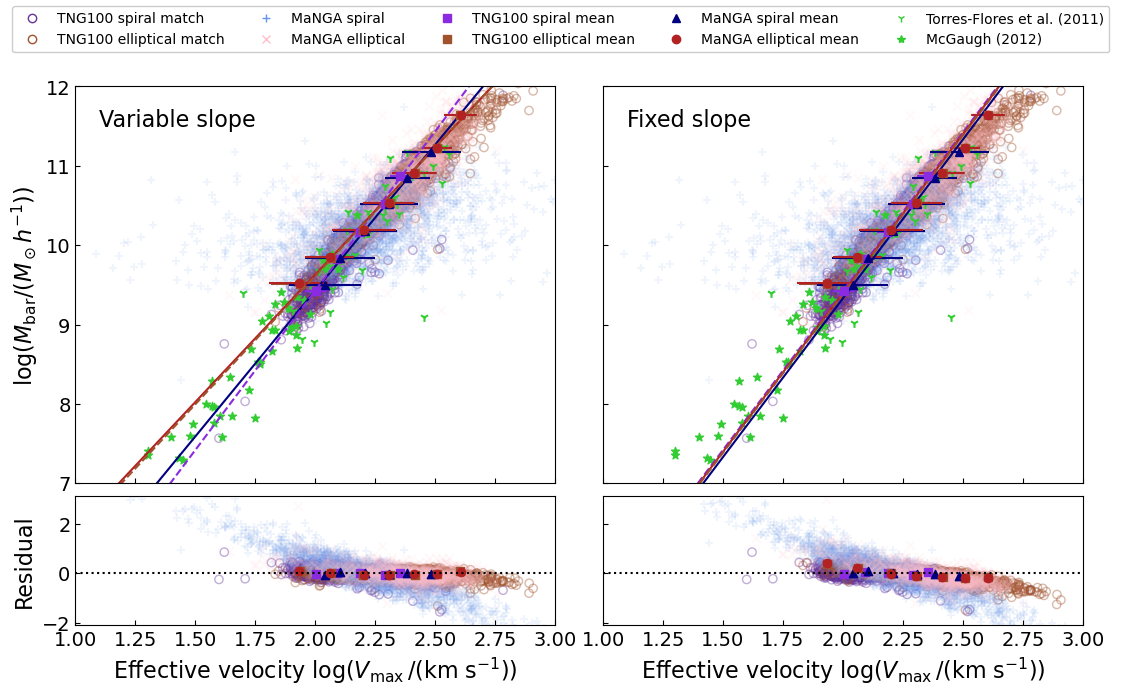

In [83]:
fig, ax  = plt.subplots(2,2, figsize=(13,7), sharex=True, height_ratios=(4,1.3), sharey='row')

# fig, ax = plt.subplots(3,1,sharex=True, height_ratios=(4,1.3, 4), figsize=(6.4,12))


for i in range(2):

    ax[0,i].scatter(np.log10(s_tng_vrot), s_tng_mbar, marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4, label='Spirals')
    ax[0,i].scatter(np.log10(e_tng_vrot), e_tng_mbar, marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
    ax[0,i].scatter(np.log10(s_manga_vrot), s_manga_mbar, marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')
    
    ax[0,i].scatter(np.log10(e_manga_vrot), e_manga_mbar, marker='x', color='pink', alpha=0.1, label='Ellipticals')


    ax[0,i].errorbar(is_mvis_veff_avg, is_veff_ctr, xerr=is_mvis_veff_sig, linestyle='none',
                marker='s', color='blueviolet')
    ax[0,i].errorbar(ie_mvis_veff_avg, ie_veff_ctr, xerr=ie_mvis_veff_sig, linestyle='none',
                marker='s', color='sienna')
    ax[0,i].errorbar(s_mvis_veff_avg, s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none',
                marker='^', color='navy')
    ax[0,i].errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none',
                marker='o', color='firebrick')
    ax[0,i].set_xlim(1,3)
    ax[0,i].set_ylim(7,12)
    ax[0,i].tick_params( axis='both', direction='in', labelsize=14)
    ax[1,i].tick_params( axis='both', direction='in', labelsize=14)

    ax[1,i].set_xlabel(r'Effective velocity $\log(V_{\rm max}\,/(\text{km s}^{-1}))$', fontsize=16)

    ax[0,i].scatter(np.log10(mcg['V_f']), np.log10(10**mcg['Mstar'] + 10**mcg['Mg']) +np.log10(0.73), 
            marker='*', color='limegreen', label='McGaugh (2012)')
    ax[0,i].scatter(np.log10(torflor['V_TF']), torflor['Mbar'] +np.log10(0.73), marker='1', color='limegreen', s=40, label='Torres-Flores et al. (2011)')





ax[0,0].plot(vs, vs*s_slope + s_yint, color='navy')
ax[0,0].plot(vs, vs*is_slope + is_yint, color='blueviolet', linestyle='--')
ax[0,0].plot(vs, vs*e_slope + e_yint, color='firebrick')
ax[0,0].plot(vs, vs*ie_slope + ie_yint, color='sienna', linestyle='--')

ms=np.linspace(5,15,100)

ax[0,1].plot(ms*0.25 + s_yint_fixed, ms, color='navy')
ax[0,1].plot(ms*0.25 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
ax[0,1].plot(ms*0.25 + e_yint_fixed, ms, color='firebrick')
ax[0,1].plot(ms*0.25 + ie_yint_fixed, ms, color='sienna', linestyle='--')

# ax[1].plot(vs, vs*4 + s_yint_fixed, color='navy')
# ax[1].plot(vs , vs*4 + is_yint_fixed, ms, color='blueviolet',linestyle='--')
# ax[1].plot(vs, vs*4+ e_yint_fixed, ms, color='firebrick')
# ax[1].plot(vs, vs*4 + ie_yint_fixed, ms, color='sienna', linestyle='--')

ax[0,0].set_ylabel(r'$\log(M_{\rm bar}/(M_\odot h^{-1}))$', fontsize=16)


legend_elements = [Line2D([0], [0], marker='o', color='w', label='TNG100 spiral match',
                          markeredgecolor='rebeccapurple', markerfacecolor='none', markersize=6),
                   Line2D([0], [0], marker='o', color='w', label='TNG100 elliptical match',
                          markeredgecolor='sienna', markerfacecolor='none', markersize=6),
                  Line2D([0], [0], marker='+', color='w', label='MaNGA spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='MaNGA elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='TNG100 spiral mean',
                          markeredgecolor='blueviolet', markerfacecolor='blueviolet', markersize=6),
                   Line2D([0], [0], marker='s', color='w', label='TNG100 elliptical mean',
                          markeredgecolor='sienna', markerfacecolor='sienna', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='MaNGA spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='MaNGA elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  
                  Line2D([0], [0], marker='1', color='w', label='Torres-Flores et al. (2011)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),
                  
                  Line2D([0], [0], marker='*', color='w', label='McGaugh (2012)',
                          markeredgecolor='limegreen', markerfacecolor='limegreen', markersize=6),]

fig.legend(handles=legend_elements, loc='upper center', framealpha=1, ncols=5)
fig.subplots_adjust(wspace=0.1, hspace=0.05)


ax[0,0].text(1.1,11.5, 'Variable slope', fontsize=16)
ax[0,1].text(1.1,11.5, 'Fixed slope', fontsize=16)


ax[1,0].scatter(np.log10(s_tng_vrot), s_tng_mbar-(np.log10(s_tng_vrot)*is_slope + is_yint), marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4,)
ax[1,0].scatter(np.log10(e_tng_vrot), e_tng_mbar-(np.log10(e_tng_vrot)*ie_slope + ie_yint), marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
ax[1,0].scatter(np.log10(s_manga_vrot), s_manga_mbar-(np.log10(s_manga_vrot)*s_slope + s_yint), marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')

ax[1,0].scatter(np.log10(e_manga_vrot), e_manga_mbar-(np.log10(e_manga_vrot)*e_slope + e_yint), marker='x', color='pink', alpha=0.1, label='Ellipticals')



ax[1,0].scatter(is_mvis_veff_avg, is_veff_ctr-(is_mvis_veff_avg*is_slope + is_yint), marker='s', color='blueviolet')
ax[1,0].scatter(ie_mvis_veff_avg, ie_veff_ctr-(ie_mvis_veff_avg*ie_slope + ie_yint), marker='s', color='sienna')
ax[1,0].scatter(s_mvis_veff_avg, s_veff_ctr-(s_mvis_veff_avg*s_slope + s_yint), marker='^', color='navy')

ax[1,0].scatter(e_mvis_veff_avg, e_veff_ctr-(e_mvis_veff_avg*e_slope + e_yint), marker='o', color='firebrick')




ax[1,1].scatter(np.log10(s_tng_vrot), s_tng_mbar-(np.log10(s_tng_vrot)*4 - is_yint_fixed*4), marker='o', facecolor='none',
                color='rebeccapurple', alpha=0.4,)
ax[1,1].scatter(np.log10(e_tng_vrot), e_tng_mbar-(np.log10(e_tng_vrot)*4 - ie_yint_fixed*4), marker='o', facecolor='none',
                color='sienna', alpha=0.4, label='Spirals')
ax[1,1].scatter(np.log10(s_manga_vrot), s_manga_mbar-(np.log10(s_manga_vrot)*4 - s_yint_fixed*4), marker='+', color='cornflowerblue', alpha=0.1, label='Spirals')

ax[1,1].scatter(np.log10(e_manga_vrot), e_manga_mbar-(np.log10(e_manga_vrot)*4 - e_yint_fixed*4), marker='x', color='pink', alpha=0.1, label='Ellipticals')



ax[1,1].scatter(is_mvis_veff_avg, is_veff_ctr-(is_mvis_veff_avg*4 -is_yint_fixed*4), marker='s', color='blueviolet')
ax[1,1].scatter(ie_mvis_veff_avg, ie_veff_ctr-(ie_mvis_veff_avg*4 -ie_yint_fixed*4), marker='s', color='sienna')
ax[1,1].scatter(s_mvis_veff_avg, s_veff_ctr-(s_mvis_veff_avg*4 + -s_yint_fixed*4), marker='^', color='navy')

ax[1,1].scatter(e_mvis_veff_avg, e_veff_ctr-(e_mvis_veff_avg*4 + -e_yint_fixed*4), marker='o', color='firebrick')







ax[1,0].axhline(0, linestyle=':', color='k')
# ax[1,0].set_ylim(-2.1,2.1)
ax[1,1].axhline(0, linestyle=':', color='k')
ax[1,1].set_ylim(-2.1,3.1)
ax[1,0].set_ylabel('Residual', fontsize=16)
# plt.tight_layout()
fig.subplots_adjust(hspace=0.05)
# fig.subplots_adjust(wspace=0.1)

plt.savefig(plot_dir + 'BTFR/BTFR_mstarhi_illustris_combined_refit_res.png', bbox_inches='tight')

### sigma vs velocity

In [36]:
f = open(plot_dir + 'BTFR/ellipticals_tng/data.txt', mode='r')
text = f.read()
f.close()

text = text.replace('\n', ' ')
text = text.replace('  ', ' ')


idx = text.find('avgs')
text=text[idx:]

text=text.replace(' ', ',')
idx = text.find('[')
idx2 = text.find(']')
ie_avgs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)
text=text.split(']',1)[1]



idx = text.find('sigs')
text=text[idx:]

idx = text.find('[')
idx2 = text.find(']')
ie_sigs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)

In [38]:
f = open(plot_dir + 'BTFR/spirals_manga/data.txt', mode='r')
text = f.read()
f.close()

text = text.replace('\n', ' ')
text = text.replace('  ', ' ')


idx = text.find('avgs')
text=text[idx:]

text=text.replace(' ', ',')
idx = text.find('[')
idx2 = text.find(']')
s_avgs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)
text=text.split(']',1)[1]



idx = text.find('sigs')
text=text[idx:]

idx = text.find('[')
idx2 = text.find(']')
s_sigs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)

In [39]:


f = open(plot_dir + 'BTFR/spirals_tng/data.txt', mode='r')
text = f.read()
f.close()

text = text.replace('\n', ' ')
text = text.replace('  ', ' ')


idx = text.find('avgs')
text=text[idx:]

text=text.replace(' ', ',')
idx = text.find('[')
idx2 = text.find(']')
is_avgs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)
text=text.split(']',1)[1]



idx = text.find('sigs')
text=text[idx:]

idx = text.find('[')
idx2 = text.find(']')
is_sigs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)




In [40]:
f = open(plot_dir + 'BTFR/ellipticals_manga/data.txt', mode='r')
text = f.read()
f.close()

text = text.replace('\n', ' ')
text = text.replace('  ', ' ')


idx = text.find('avgs')
text=text[idx:]

text=text.replace(' ', ',')
idx = text.find('[')
idx2 = text.find(']')
e_avgs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)
text=text.split(']',1)[1]



idx = text.find('sigs')
text=text[idx:]

idx = text.find('[')
idx2 = text.find(']')
e_sigs = np.array(text[idx+1:idx2].split(',',-1)).astype(float)




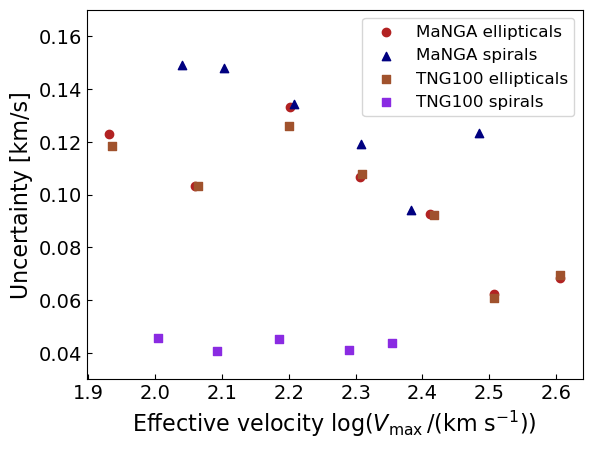

In [58]:
plt.scatter(e_avgs, e_sigs, marker='o', color='firebrick', label='MaNGA ellipticals')
plt.scatter(s_avgs, s_sigs, marker='^', color='navy', label='MaNGA spirals')
plt.scatter(ie_avgs, ie_sigs, marker='s', color='sienna', label='TNG100 ellipticals')
plt.scatter(is_avgs, is_sigs, marker='s', color='blueviolet', label='TNG100 spirals')
plt.xlabel(r'Effective velocity $\log(V_{\rm max}\,/(\text{km s}^{-1}))$', fontsize=16)
plt.ylabel(r'Uncertainty [km/s]', fontsize=16)
plt.tick_params(axis='both', direction='in', labelsize=14)
plt.legend(fontsize='large')
plt.ylim(0.03,0.17)
# plt.xlim(1,3)
plt.savefig(plot_dir + '/BTFR/velocity_sigma.png', bbox_inches='tight')

## fig 13 full MaNGA btfr

### ellipticals

In [23]:
e_veff = []
e_veff_ctr = []
ellipticals_mvis_bins = np.concatenate((np.linspace(8.9,12,9), np.array([17.1])))
e_mvis_bins = np.concatenate((np.array([ellipticals_mvis_bins[0]]), ellipticals_mvis_bins[2:-3], ellipticals_mvis_bins[-1:]))
indices = np.digitize(ellipticals['sphd_M_star_h'], e_mvis_bins)

for i in range(1, len(e_mvis_bins)):

    e_veff.append(np.log10(ellipticals['v_eff'])[indices==i])
    e_veff_ctr.append(np.mean(ellipticals['sphd_M_star_h'][indices==i]))

e_mvis_veff_avg, e_mvis_veff_sig = fit_to_gaussian(e_veff, plot_dir = plot_dir +'/BTFR/all_ellipticals_manga/', 
                                                         plot_name='e_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                  plot_bins=e_mvis_bins, xlab=r'$V_{\rm eff}$')



In [24]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(e_veff_ctr), e_mvis_veff_avg, e_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

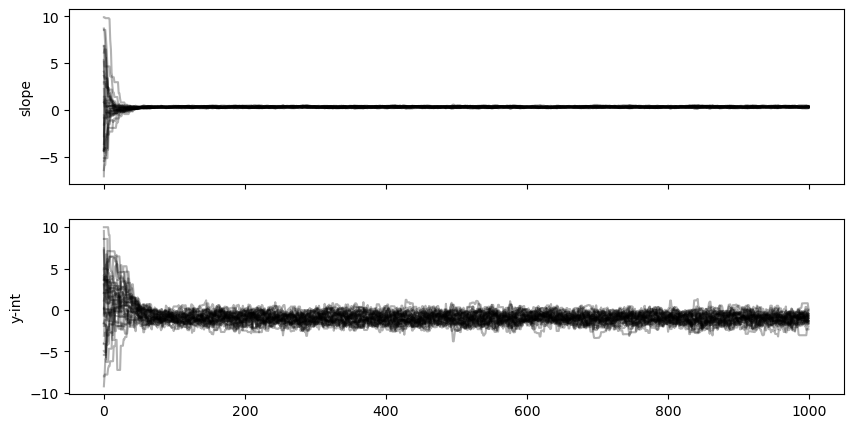

In [167]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])


In [168]:
tau = sampler.get_autocorr_time()
eflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)

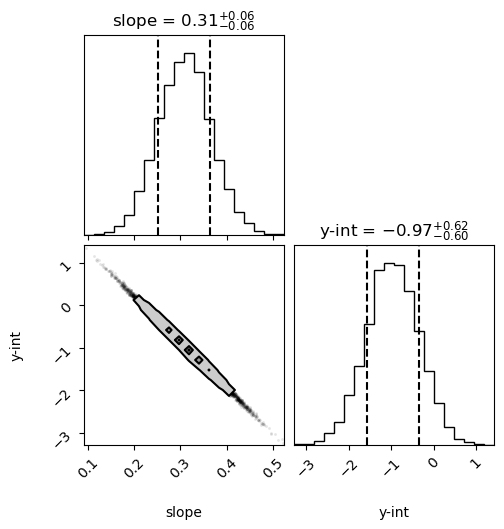

In [169]:
fig = corner.corner(eflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

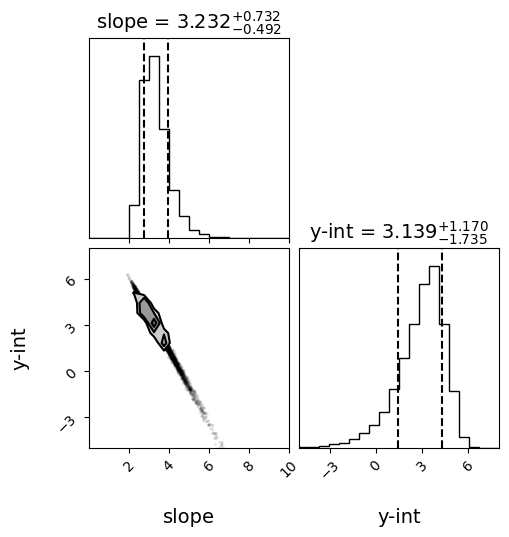

In [170]:
eflat_samples_flip = np.array([1/eflat_samples[:,0], -eflat_samples[:,1]/eflat_samples[:,0]]).transpose()
fig = corner.corner(eflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                    
                   #plot_density=1,
                    range=((0,10),(-5,8))
                    
                   )

# plt.tick_params(labelsize=14)


plt.savefig(plot_dir + '/BTFR/all_ellipticals_manga/' + 'manga_ellipticals_corner.png', bbox_inches='tight')

In [171]:
e_slope = np.percentile(eflat_samples_flip[:,0],50)
e_slope_bounds = [np.percentile(eflat_samples_flip[:,0],16), np.percentile(eflat_samples_flip[:,0],84)]
e_yint = np.percentile(eflat_samples_flip[:,1],50)
e_yint_bounds = [np.percentile(eflat_samples_flip[:,1],16), np.percentile(eflat_samples_flip[:,1],84)]
e_chi2 = chi2_norm(lin_fit(np.array(e_veff_ctr), np.percentile(eflat_samples[:,0],50), 
                           np.percentile(eflat_samples[:,1],50)), e_mvis_veff_avg, e_mvis_veff_sig, 2)

In [172]:
# write data to a file 
f = open(plot_dir + '/BTFR/all_ellipticals_manga/data.txt', 'x')
f.write('e_veff_centers \n')
f.write(str(e_veff_ctr) + '\n')
f.write('e_mvis_avgs \n')
f.write(str(e_mvis_veff_avg)+ '\n')
f.write('e_mvis_sigs \n')
f.write(str(e_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(e_slope) + str(e_slope_bounds-e_slope)+ '\n')
f.write('y-int \n')
f.write(str(e_yint) + str(e_yint_bounds-e_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(e_chi2) + '\n')

f.write('fixed slope 4 y-int \n')
f.write(str(-e_yint_fixed*4) + '\n')
f.write('fixed slope 4 y-int err \n')
f.write(str(-e_yint_fixed_err*4) + '\n')
f.write('chi2 nu \n')
f.write(str(e_chi2_fixed_min))


f.close()



### spirals

In [34]:
HI_spirals_mbar = np.log10(10**HI_spirals['sphd_M_star_h'] + 10**HI_spirals['logHI_h'] \
                      + 10**HI_spirals['param_H2_h'] + 10**HI_spirals['param_He_h'])

In [174]:
s_veff = []
s_veff_ctr = []
spiral_mvis_bins = np.linspace(8,12,12)
s_mvis_bins = spiral_mvis_bins
s_mvis_bins = np.concatenate((spiral_mvis_bins[:1], spiral_mvis_bins[4:-3], spiral_mvis_bins[-1:]))
indices = np.digitize(HI_spirals_mbar, s_mvis_bins)

for i in range(1, len(s_mvis_bins)):

    s_veff.append(np.log10(HI_spirals['v_max'])[indices==i])
    s_veff_ctr.append(np.mean(HI_spirals_mbar[indices==i]))

s_mvis_veff_avg, s_mvis_veff_sig = fit_to_gaussian(s_veff, plot_dir = plot_dir +'/BTFR/all_spirals_manga/', 
                                                         plot_name='s_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                  plot_bins=s_mvis_bins, xlab=r'$V_{\rm eff}$')



/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [175]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(s_veff_ctr), s_mvis_veff_avg, s_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

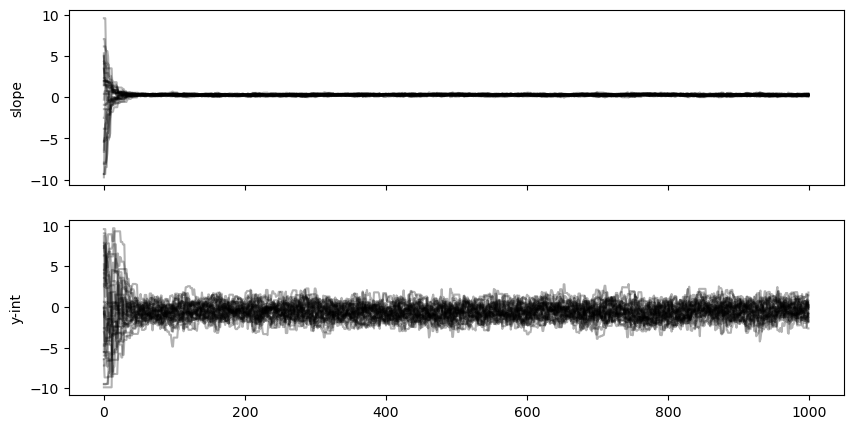

In [176]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

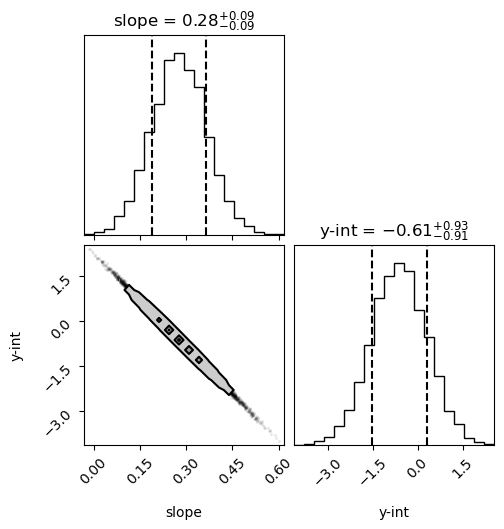

In [177]:
tau = sampler.get_autocorr_time()
sflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(sflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

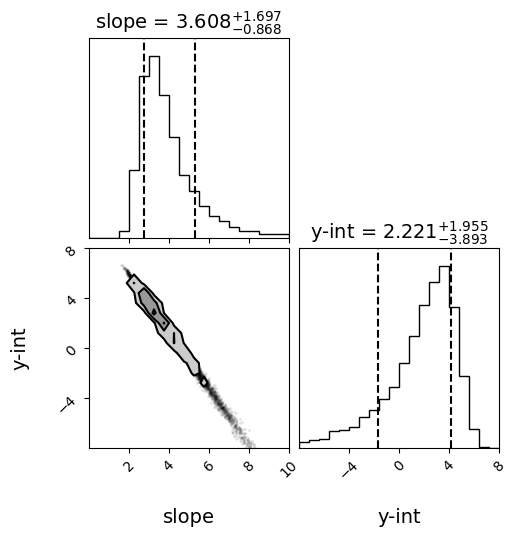

In [178]:
sflat_samples_flip = np.array([1/sflat_samples[:,0], -sflat_samples[:,1]/sflat_samples[:,0]]).transpose()
fig = corner.corner(sflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                   title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                     range=((0,10),(-8,8))
                    
                   )

plt.savefig(plot_dir + '/BTFR/all_spirals_manga/' + 'manga_spirals_corner.png', bbox_inches='tight')

In [179]:
s_slope = np.percentile(sflat_samples_flip[:,0],50)
s_slope_bounds = [np.percentile(sflat_samples_flip[:,0],16), np.percentile(sflat_samples_flip[:,0],84)]
s_yint = np.percentile(sflat_samples_flip[:,1],50)
s_yint_bounds = [np.percentile(sflat_samples_flip[:,1],16), np.percentile(sflat_samples_flip[:,1],84)]
s_chi2 = chi2_norm(lin_fit(np.array(s_veff_ctr), np.percentile(sflat_samples[:,0],50), 
                           np.percentile(sflat_samples[:,1],50)), s_mvis_veff_avg, s_mvis_veff_sig, 2)

In [180]:
# write data to a file 
f = open(plot_dir + '/BTFR/all_spirals_manga/data.txt', 'x')
f.write('s_veff_centers \n')
f.write(str(s_veff_ctr) + '\n')
f.write('s_mvis_avgs \n')
f.write(str(s_mvis_veff_avg)+ '\n')
f.write('s_mvis_sigs \n')
f.write(str(s_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(s_slope) + str(s_slope_bounds-s_slope)+ '\n')
f.write('y-int \n')
f.write(str(s_yint) + str(s_yint_bounds-s_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(s_chi2) + '\n')


f.close()



### spiral elliptical combined corner plot

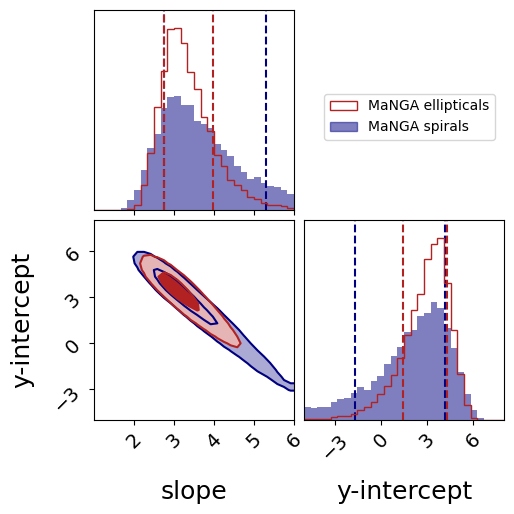

In [181]:
labels = ['slope', 'y-intercept']

fig = corner.corner(sflat_samples_flip, color='navy',
                   quantiles=(0.16, 0.84),
                    bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
                    hist_kwargs={'color':'navy', 'histtype': 'stepfilled', 'alpha':0.5},
                     range=((1,6),(-5,8)),
                    smooth=1,
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)),
                    plot_datapoints=False
                    
                   )
corner.corner(eflat_samples_flip, fig=fig, labels=labels, 
              color='firebrick',
                   quantiles=(0.16, 0.84),
                    bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                    title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
                    # hist_kwargs={'color':'firebrick', 'histtype': 'stepfilled', 'alpha':0.5},
                     range=((1,6),(-5,8)),
                    smooth=1,
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)),
                    plot_datapoints=False
                    
                   )

# corner.corner(isflat_samples_flip, fig=fig, labels=labels,
#              quantiles=(0.16, 0.84),
#               bins=30,
#                    fill_contours=1,
#                     # show_titles=1,
#                     title_quantiles = [0.16,0.5,0.84],
#                     title_fmt='.3f',
#                     label_kwargs={'fontsize':18},
#                     title_kwargs={'fontsize':14},
#                range=((1,6),(-5,8)),
#              smooth=1,
#              levels=(1-np.exp(-0.5), 1-np.exp(-2)),
#              plot_datapoints=False)



for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=14)


legend_elements = [Patch(facecolor='none', edgecolor='firebrick', label='MaNGA ellipticals'),
                   Patch(facecolor='navy', alpha=0.5, edgecolor='navy', label='MaNGA spirals')
                  ]

plt.legend(handles=legend_elements, loc=(0.1,1.4))


    
plt.savefig(plot_dir + '/BTFR/' + 'spirals_ellipticals_allmanga.png', bbox_inches='tight')

### full sample

In [182]:
manga_vrot = np.concatenate((HI_spirals['v_max'], ellipticals['v_eff']))
manga_mbar = np.concatenate((HI_spirals_mbar, ellipticals['sphd_M_star_h']))

(array([8.000e+00, 1.175e+03, 2.718e+03, 1.794e+03, 3.700e+01, 5.000e+00,
        2.000e+00, 2.000e+00, 1.000e+00, 1.000e+00]),
 array([ 8.30630433,  9.17834326, 10.05038219, 10.92242111, 11.79446004,
        12.66649897, 13.53853789, 14.41057682, 15.28261575, 16.15465467,
        17.0266936 ]),
 <BarContainer object of 10 artists>)

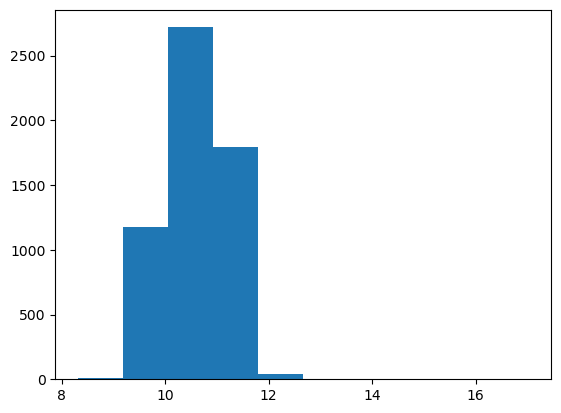

In [183]:
plt.hist(manga_mbar)

In [184]:
manga_mbar_bins = np.concatenate((np.linspace(8, 12, 11), np.array([17.2])))

In [185]:
a_veff = []
a_veff_ctr = []
a_mvis_bins = manga_mbar_bins
a_mvis_bins = np.concatenate((manga_mbar_bins[:1], manga_mbar_bins[4:-2], manga_mbar_bins[-1:]))
indices = np.digitize(manga_mbar, a_mvis_bins)

for i in range(1, len(a_mvis_bins)):

    a_veff.append(np.log10(manga_vrot)[indices==i])
    a_veff_ctr.append(np.mean(manga_mbar[indices==i]))

a_mvis_veff_avg, a_mvis_veff_sig = fit_to_gaussian(a_veff, plot_dir = plot_dir +'/BTFR/all_manga/', 
                                                         plot_name='s_v_eff_mvis', bin_lab=r'$M_{\rm bar}$',
                                                  plot_bins=a_mvis_bins, xlab=r'$V_{\rm eff}$')



/Users/nityaravi/miniforge3/envs/RotationCurves/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [186]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(a_veff_ctr), a_mvis_veff_avg, a_mvis_veff_sig))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

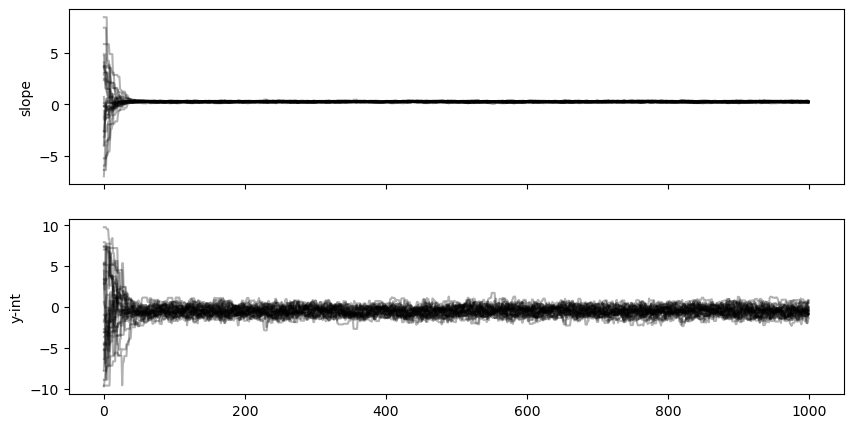

In [187]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

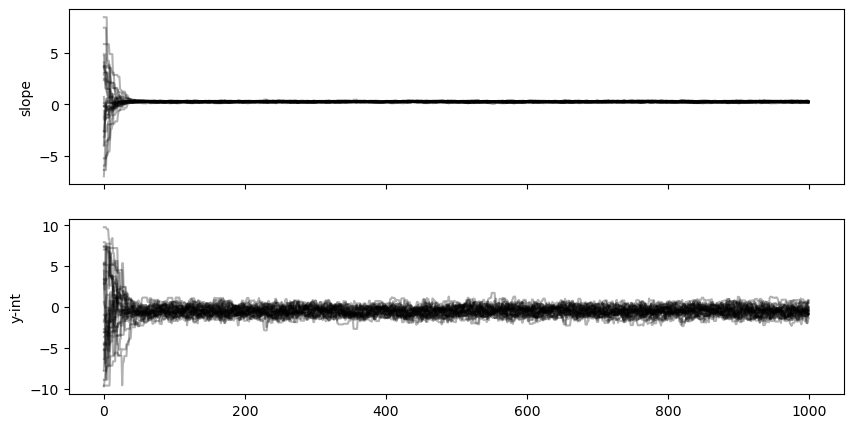

In [188]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

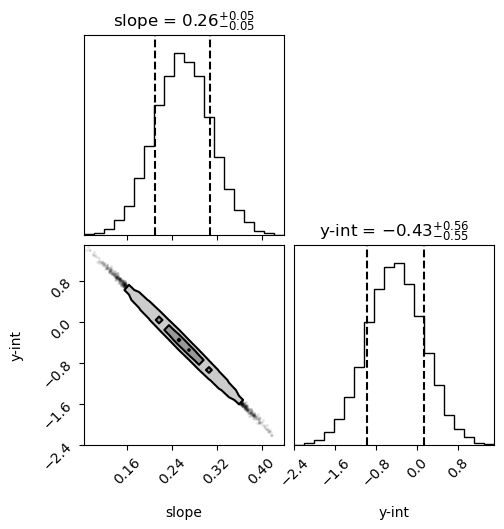

In [189]:
tau = sampler.get_autocorr_time()
aflat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(aflat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )

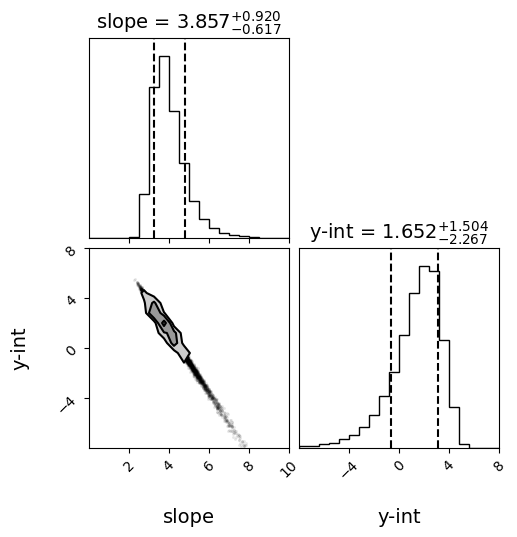

In [190]:
aflat_samples_flip = np.array([1/aflat_samples[:,0], -aflat_samples[:,1]/aflat_samples[:,0]]).transpose()
fig = corner.corner(aflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                   title_fmt='.3f',
                    label_kwargs={'fontsize':14},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                     range=((0,10),(-8,8))
                    
                   )

plt.savefig(plot_dir + '/BTFR/all_manga/' + 'manga_all_corner.png', bbox_inches='tight')

In [191]:
a_slope = np.percentile(aflat_samples_flip[:,0],50)
a_slope_bounds = [np.percentile(aflat_samples_flip[:,0],16), np.percentile(aflat_samples_flip[:,0],84)]
a_yint = np.percentile(aflat_samples_flip[:,1],50)
a_yint_bounds = [np.percentile(aflat_samples_flip[:,1],16), np.percentile(aflat_samples_flip[:,1],84)]
a_chi2 = chi2_norm(lin_fit(np.array(a_veff_ctr), np.percentile(aflat_samples[:,0],50), 
                           np.percentile(aflat_samples[:,1],50)), a_mvis_veff_avg, a_mvis_veff_sig, 2)

In [192]:
# write data to a file 
f = open(plot_dir + '/BTFR/all_manga/data.txt', 'x')
f.write('s_veff_centers \n')
f.write(str(a_veff_ctr) + '\n')
f.write('s_mvis_avgs \n')
f.write(str(a_mvis_veff_avg)+ '\n')
f.write('s_mvis_sigs \n')
f.write(str(a_mvis_veff_sig)+ '\n')

f.write('MCMC slope \n')
f.write(str(a_slope) + str(a_slope_bounds-a_slope)+ '\n')
f.write('y-int \n')
f.write(str(a_yint) + str(a_yint_bounds-a_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(a_chi2) + '\n')



f.close()



### nice all corner plot

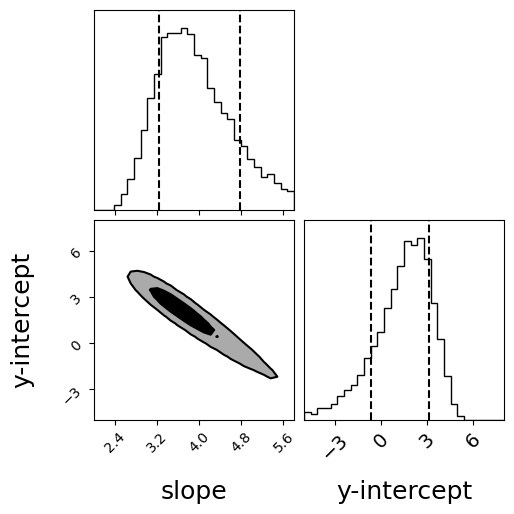

In [195]:
labels = ['slope', 'y-intercept']

fig = corner.corner(aflat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                    bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                   title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
                   # plot_density=1
                     range=((2,5.8),(-5,8)),
                    smooth=1,
                    levels=(1-np.exp(-0.5), 1-np.exp(-2)),
                    plot_datapoints=False
                    
                   )

plt.tick_params(axis='both', labelsize=14)


# plt.legend(handles=legend_elements, loc=(0.1,1.4))

plt.savefig(plot_dir + '/BTFR/all_manga/' + 'manga_all_corner_v2.png', bbox_inches='tight')

### scatter plot

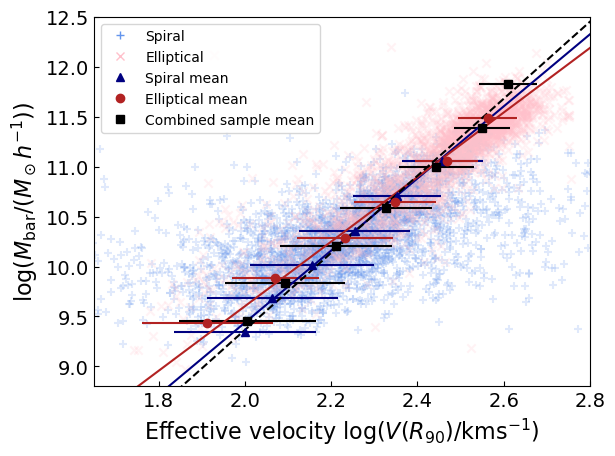

In [196]:
plt.scatter(np.log10(HI_spirals['v_max']), HI_spirals_mbar, marker='+', color='cornflowerblue', alpha=0.2)
plt.scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)

plt.errorbar(s_mvis_veff_avg,s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none', marker='^', color='navy')
plt.errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none', marker='o', color='firebrick')

plt.errorbar(a_mvis_veff_avg, a_veff_ctr, xerr=a_mvis_veff_sig, linestyle='none', marker='s', color='k')

vs = np.linspace(1,3,100)
ms = np.linspace(8,14,100)


plt.plot(vs, vs*s_slope + s_yint, color='navy')
plt.plot(vs, vs*e_slope + e_yint, color='firebrick')
plt.plot(vs, vs*a_slope + a_yint, color='k', linestyle='--')

plt.xlim(1.65,2.8)
plt.ylim(8.8,12.5)


legend_elements = [
                  Line2D([0], [0], marker='+', color='w', label='Spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='Elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='Spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='Elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='Combined sample mean',
                          markeredgecolor='k', markerfacecolor='k', markersize=6),]

plt.legend(handles=legend_elements, loc='upper left')

plt.xlabel(r'Effective velocity $\log(V(R_{90})/\rm km s^{-1})$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm bar}/(M_\odot h^{-1}))$', fontsize=16)

plt.tick_params( axis='both', direction='in', labelsize=14)


plt.savefig(plot_dir + 'BTFR/BTFR_fullmanga_combined.png', bbox_inches='tight')

### w residuals

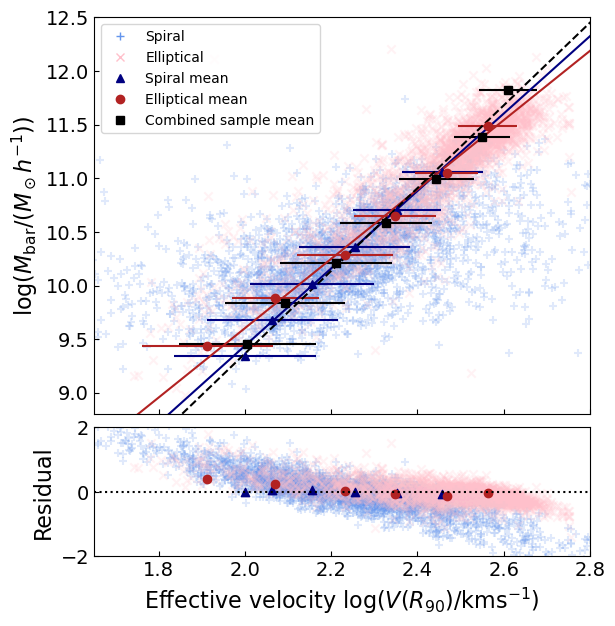

In [278]:
fig, ax = plt.subplots(2,1, figsize=(6.4,7), sharex=True, height_ratios=(4,1.3))

ax[0].scatter(np.log10(HI_spirals['v_max']), HI_spirals_mbar, marker='+', color='cornflowerblue', alpha=0.2)
ax[0].scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)

ax[0].errorbar(s_mvis_veff_avg,s_veff_ctr, xerr=s_mvis_veff_sig, linestyle='none', marker='^', color='navy')
ax[0].errorbar(e_mvis_veff_avg, e_veff_ctr, xerr=e_mvis_veff_sig, linestyle='none', marker='o', color='firebrick')

ax[0].errorbar(a_mvis_veff_avg, a_veff_ctr, xerr=a_mvis_veff_sig, linestyle='none', marker='s', color='k')

vs = np.linspace(1,3,100)
ms = np.linspace(8,14,100)


ax[0].plot(vs, vs*s_slope + s_yint, color='navy')
ax[0].plot(vs, vs*e_slope + e_yint, color='firebrick')
ax[0].plot(vs, vs*a_slope + a_yint, color='k', linestyle='--')

ax[0].set_xlim(1.65,2.8)
ax[0].set_ylim(8.8,12.5)


legend_elements = [
                  Line2D([0], [0], marker='+', color='w', label='Spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='Elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='Spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='Elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='Combined sample mean',
                          markeredgecolor='k', markerfacecolor='k', markersize=6),]

ax[0].legend(handles=legend_elements, loc='upper left')

ax[1].set_xlabel(r'Effective velocity $\log(V(R_{90})/\rm km s^{-1})$', fontsize=16)
ax[0].set_ylabel(r'$\log(M_{\rm bar}/(M_\odot h^{-1}))$', fontsize=16)

ax[0].tick_params( axis='both', direction='in', labelsize=14)

ax[1].tick_params( axis='both', direction='in', labelsize=14)

ax[1].axhline(0, linestyle=':', color='k')

ax[1].scatter(np.log10(HI_spirals['v_max']), HI_spirals_mbar-(np.log10(HI_spirals['v_max'])*a_slope + a_yint), marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h']-(np.log10(ellipticals['v_eff'])*a_slope + a_yint), marker='x', color='pink', alpha=0.2)


ax[1].scatter(s_mvis_veff_avg, s_veff_ctr-(s_mvis_veff_avg*a_slope + a_yint),  marker='^', color='navy')
ax[1].scatter(e_mvis_veff_avg, e_veff_ctr-(e_mvis_veff_avg*a_slope + a_yint),  marker='o', color='firebrick')
fig.subplots_adjust(hspace=0.05)



ax[1].set_ylim(-2,2)
ax[1].set_ylabel('Residual', fontsize=16)
fig.savefig(plot_dir + 'BTFR/BTFR_fullmanga_combined_res.png', bbox_inches='tight')

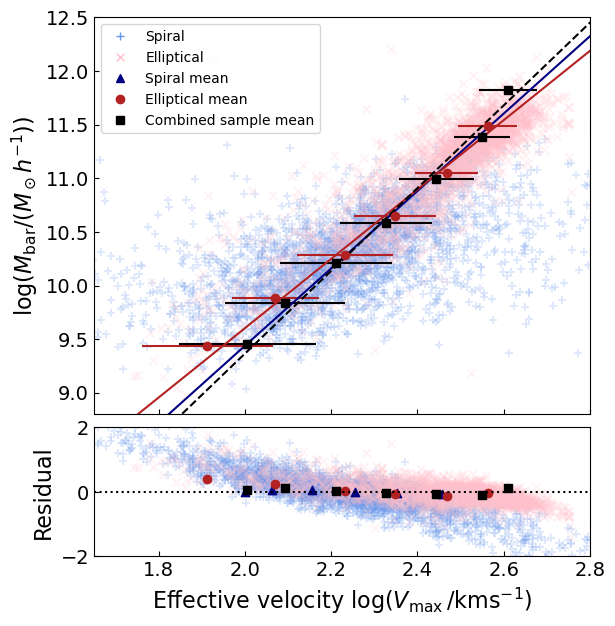

In [42]:
fig, ax = plt.subplots(2,1, figsize=(6.4,7), sharex=True, height_ratios=(4,1.3))

ax[0].scatter(np.log10(HI_spirals['v_max']), HI_spirals_mbar, marker='+', color='cornflowerblue', alpha=0.2)
ax[0].scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h'], marker='x', color='pink', alpha=0.2)

ax[0].errorbar([1.99916163, 2.06337351, 2.1551267 , 2.25447336, 2.3521774 , 2.45800122],
                [0.16460427, 0.15196244 ,0.14436597 ,0.12919076, 0.10138772, 0.09419867], 
               xerr=[9.346277264275589, 9.680852259844158, 10.015055643888651, 10.358647081997201, 10.702733816526775, 11.05744255327344], 
               linestyle='none', marker='^', color='navy')
ax[0].errorbar([1.9129622 , 2.07083505 ,2.23172194 ,2.34847236 ,2.46782006, 2.56240411], 
               [9.439483732076589, 9.882299754205237, 10.287272708772438, 10.645067859381047, 11.053045815861095, 11.486063556490777], 
               xerr=[0.15186315, 0.09989136 ,0.11178953, 0.09515478 ,0.07253952, 0.06839718], linestyle='none', marker='o', color='firebrick')

ax[0].errorbar([2.00539373, 2.09249205, 2.21111341, 2.32650096 ,2.44369854, 2.54921292, 2.60989553], 
               [9.457199585325208, 9.833240287945346, 10.208261752994924, 10.587138971315946, 10.996956951024883, 11.387587167582113, 11.826753976346387], 
               xerr=[0.15844632, 0.13853062, 0.12986103, 0.10705799 ,0.08726466, 0.06502915, 0.06785486], linestyle='none', marker='s', color='k')

vs = np.linspace(1,3,100)
ms = np.linspace(8,14,100)


ax[0].plot(vs, vs*3.608437050669208 + 2.2214268527710628, color='navy')
ax[0].plot(vs, vs*3.232003787025487 + 3.1387614736379224, color='firebrick')
ax[0].plot(vs, vs*3.85697548373097 + 1.651666754051344, color='k', linestyle='--')

ax[0].set_xlim(1.65,2.8)
ax[0].set_ylim(8.8,12.5)


legend_elements = [
                  Line2D([0], [0], marker='+', color='w', label='Spiral',
                          markeredgecolor='cornflowerblue', markerfacecolor='cornflowerblue', markersize=6),
                  Line2D([0], [0], marker='x', color='w', label='Elliptical',
                          markeredgecolor='pink', markerfacecolor='pink', markersize=6),
                  Line2D([0], [0], marker='^', color='w', label='Spiral mean',
                          markeredgecolor='navy', markerfacecolor='navy', markersize=6),
                  Line2D([0], [0], marker='o', color='w', label='Elliptical mean',
                          markeredgecolor='firebrick', markerfacecolor='firebrick', markersize=6),
                  Line2D([0], [0], marker='s', color='w', label='Combined sample mean',
                          markeredgecolor='k', markerfacecolor='k', markersize=6),]

ax[0].legend(handles=legend_elements, loc='upper left')

ax[1].set_xlabel(r'Effective velocity $\log(V_{\rm max}\,/\rm km s^{-1})$', fontsize=16)
ax[0].set_ylabel(r'$\log(M_{\rm bar}/(M_\odot h^{-1}))$', fontsize=16)

ax[0].tick_params( axis='both', direction='in', labelsize=14)

ax[1].tick_params( axis='both', direction='in', labelsize=14)

ax[1].axhline(0, linestyle=':', color='k')

ax[1].scatter(np.log10(HI_spirals['v_max']), HI_spirals_mbar-(np.log10(HI_spirals['v_max'])*3.85697548373097 + 1.651666754051344), marker='+', color='cornflowerblue', alpha=0.2)
ax[1].scatter(np.log10(ellipticals['v_eff']), ellipticals['sphd_M_star_h']-(np.log10(ellipticals['v_eff'])*3.85697548373097 + 1.651666754051344), marker='x', color='pink', alpha=0.2)


ax[1].scatter([1.99916163, 2.06337351, 2.1551267 , 2.25447336 ,2.3521774 , 2.45800122], 
              np.array([9.346277264275589, 9.680852259844158, 10.015055643888651, 10.358647081997201, 10.702733816526775, 11.05744255327344])-(np.array([1.99916163, 2.06337351 ,2.1551267,  2.25447336 ,2.3521774 , 2.45800122])*3.85697548373097 + 1.651666754051344),  marker='^', color='navy')
ax[1].scatter([1.9129622 , 2.07083505 ,2.23172194 ,2.34847236 ,2.46782006 ,2.56240411], 
              np.array([9.439483732076589, 9.882299754205237, 10.287272708772438, 10.645067859381047, 11.053045815861095, 11.486063556490777])-(np.array([1.9129622 , 2.07083505 ,2.23172194 ,2.34847236, 2.46782006 ,2.56240411])*3.85697548373097 + 1.651666754051344),  marker='o', color='firebrick')

ax[1].scatter([2.00539373, 2.09249205, 2.21111341, 2.32650096 ,2.44369854, 2.54921292, 2.60989553], 
              np.array([9.457199585325208, 9.833240287945346, 10.208261752994924, 10.587138971315946, 10.996956951024883, 11.387587167582113, 11.826753976346387])-(np.array([2.00539373, 2.09249205, 2.21111341, 2.32650096 ,2.44369854, 2.54921292, 2.60989553])*3.85697548373097 + 1.651666754051344),  marker='s', color='k')



fig.subplots_adjust(hspace=0.05)



ax[1].set_ylim(-2,2)
ax[1].set_ylabel('Residual', fontsize=16)
fig.savefig(plot_dir + 'BTFR/BTFR_fullmanga_combined_res.png', bbox_inches='tight')

## fig 14 full tng btfr

In [215]:
import illustris_python as il
import h5py

In [216]:
base_path = '/Users/nityaravi/Documents/Research/RotationCurves/data/IlustrisTNG/TNG100-1/'
fields = ['SubhaloFlag',  'SubhaloMassInRadType', 
          # 'SubhaloMass', 'SubhaloMassInHalfRad',
          'SubhaloVmax', 'SubhaloVmaxRad', 'SubhaloMass', 'SubhaloMassType', 'SubhaloHalfmassRad',
          # 'SubhaloStellarPhotometricsMassInRad','SubhaloStellarPhotometricsRad', 'SubhaloHalfmassRadType', 
          # 'SubhaloSFR',
          'SubhaloGasMetalFractions', 
          # 'SubhaloStarMetallicity'
         ]
data = il.groupcat.loadSubhalos(base_path,99,fields=fields)

In [217]:
# data['illustris_Mgas'] = np.zeros(len(ellipticals))
# data['illustris_H_gas'] = np.zeros(len(ellipticals))
# data['illustris_He_gas'] = np.zeros(len(ellipticals))

# for i in range(len(data['SubhaloGasMetalFractions'])):
data['Mgas'] = np.log10(data['SubhaloMassInRadType'][:,0]) + 10
data['H_gas'] = data['SubhaloGasMetalFractions'][:,0]
data['He_gas'] = data['SubhaloGasMetalFractions'][:,1]

data['MH'] = np.log10(data['H_gas']) + data['Mgas']
data['MHe'] = np.log10(data['H_gas']) + data['Mgas']
data['MH_He'] = np.log10(10**data['MH'] + 10**data['MHe'])

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_84775/2075674197.py:6: RuntimeWarning: divide by zero encountered in log10
  data['Mgas'] = np.log10(data['SubhaloMassInRadType'][:,0]) + 10
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_84775/2075674197.py:10: RuntimeWarning: divide by zero encountered in log10
  data['MH'] = np.log10(data['H_gas']) + data['Mgas']
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_84775/2075674197.py:11: RuntimeWarning: divide by zero encountered in log10
  data['MHe'] = np.log10(data['H_gas']) + data['Mgas']
/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_84775/2075674197.py:12: RuntimeWarning: divide by zero encountered in log10
  data['MH_He'] = np.log10(10**data['MH'] + 10**data['MHe'])


In [218]:
data['SubhaloMassInRadStar'] = np.log10(data['SubhaloMassInRadType'][:,4]) + 10
data['SubhaloMassInRadStar_Salpeter'] = data['SubhaloMassInRadStar'] - np.log10(0.55)

/var/folders/4q/zk1xkb454t7_ncsh3pf51p700000gp/T/ipykernel_84775/1831458586.py:1: RuntimeWarning: divide by zero encountered in log10
  data['SubhaloMassInRadStar'] = np.log10(data['SubhaloMassInRadType'][:,4]) + 10


In [219]:
### check that gas and stellar mass are greater than 0

# Mstar_HI = np.ones(len(data['SubhaloFlag']))*-999
# Mstar_gas = np.ones(len(data['SubhaloFlag']))*-999

tng_mbar = np.ones(len(data['SubhaloFlag']))*-999
                   
for i in tqdm(range(len(data['SubhaloFlag']))):
                   
    if data['MH_He'][i] >= 0:
        if data['MH_He'][i] == 0:

            tng_mbar[i] = data['SubhaloMassInRadStar_Salpeter'][i]

        else:
            tng_mbar[i] = np.log10(10**data['SubhaloMassInRadStar_Salpeter'][i] + 10**data['MH_He'][i])

100%|█████████████████████████████| 4371211/4371211 [00:06<00:00, 633612.08it/s]


In [220]:
good_gals = np.logical_and(np.logical_and(data['SubhaloFlag'], tng_mbar >=0), data['SubhaloMassInRadStar_Salpeter'] != -np.inf)

In [221]:
good_vmax = np.log10(data['SubhaloVmax'][good_gals])
good_Mstar_HI = tng_mbar[good_gals]

In [222]:
mvis_bins = np.linspace(np.min(good_Mstar_HI), np.max(good_Mstar_HI) + 0.1, 15)

In [240]:
veff = []
veff_ctr = []
imvis_bins = mvis_bins
imvis_bins = np.concatenate((mvis_bins[:1], mvis_bins[2:-3], mvis_bins[-1:]))
indices = np.digitize(good_Mstar_HI, imvis_bins)

for i in range(1, len(imvis_bins)):

    veff.append(good_vmax[indices==i])
    veff_ctr.append(np.mean(good_Mstar_HI[indices==i]))

mvis_veff_avg, mvis_veff_sig = fit_to_gaussian(veff, plot_dir = plot_dir +'/BTFR/all_tng/', 
                                                         plot_name='v_eff_mvis', xlab=r'$V_{\rm eff}$',
                                              plot_bins=imvis_bins, bin_lab=r'$M_{\rm bar}$')

# e_mvis_veff_popt, e_mvis_veff_pcov = curve_fit(lin_fit, veff_ctr, 
#                                        mvis_veff_avg, sigma=mvis_veff_sig)

# print(e_mvis_veff_popt[0], ' +- ', np.sqrt(e_mvis_veff_pcov[0,0]))
# print(e_mvis_veff_popt[1], ' +- ', np.sqrt(e_mvis_veff_pcov[1][1]))

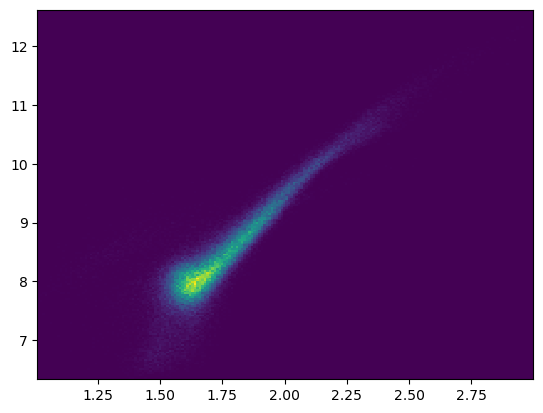

In [241]:
h,xs,ys,im  = plt.hist2d(np.log10(data['SubhaloVmax'][good_gals]),
                      tng_mbar[good_gals], bins=(200,200))

In [242]:
x0 = np.random.uniform(low=[-10,-10], high=[10,10], size=(32,2))
nwalkers, ndim = x0.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_prob, args=(np.array(veff_ctr)[np.array(veff_ctr) > 9],
                                                                mvis_veff_avg[np.array(veff_ctr) > 9], 
                                                                mvis_veff_sig[np.array(veff_ctr) > 9]))
state = sampler.run_mcmc(x0, 10000, progress='notebook')

  0%|          | 0/10000 [00:00<?, ?it/s]

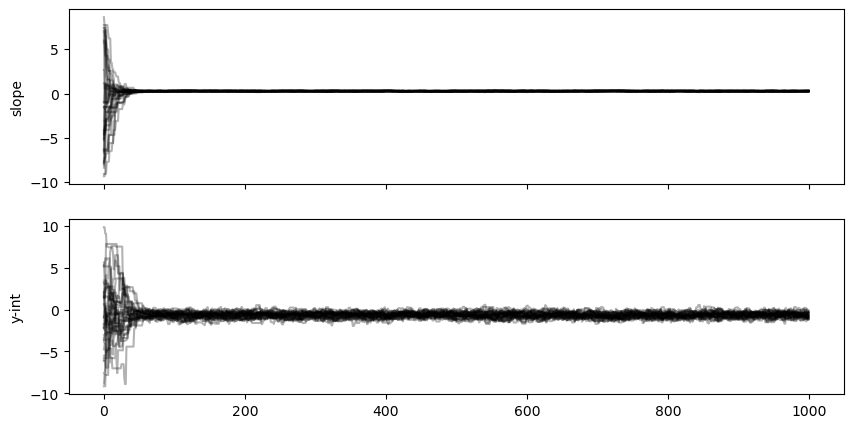

In [243]:
fig, axes = plt.subplots(2,1, figsize=(10,5), sharex=True, gridspec_kw={'hspace':0.2})
samples = sampler.get_chain()
labels = ['slope', 'y-int']
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:1000, :, i], 'k', alpha=0.3)
    ax.set_ylabel(labels[i])
    

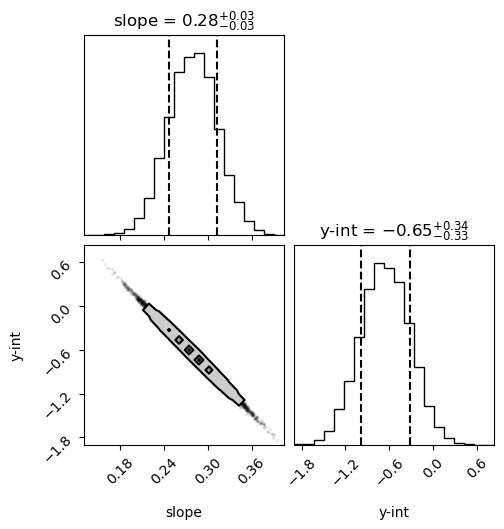

In [244]:
tau = sampler.get_autocorr_time()
tng2_flat_samples = sampler.get_chain(discard=100, thin=int(np.max(tau)), flat=True)
fig = corner.corner(tng2_flat_samples, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                   fill_contours=1,
                    show_titles=1,
                    title_quantiles = [0.16,0.5,0.84]
                   # plot_density=1
                   )




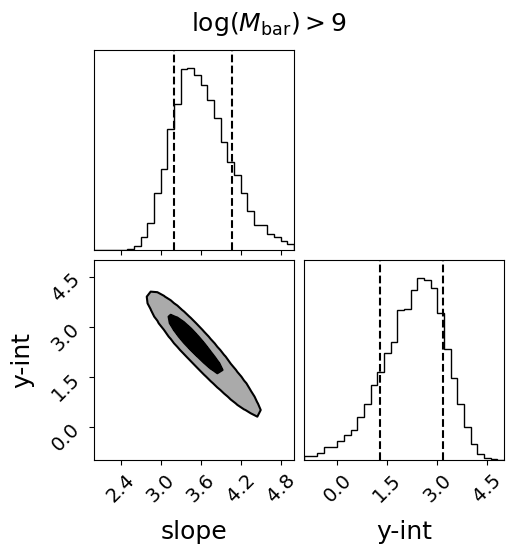

In [245]:
tng2_flat_samples_flip = np.array([1/tng2_flat_samples[:,0], -tng2_flat_samples[:,1]/tng2_flat_samples[:,0]]).transpose()
fig = corner.corner(tng2_flat_samples_flip, labels=labels,
                    # levels=(0.5,0.864),
                    quantiles=(0.16, 0.84),
                    bins=30,
                   fill_contours=1,
                    # show_titles=1,
                    title_quantiles = [0.16,0.5,0.84],
                   title_fmt='.3f',
                    label_kwargs={'fontsize':18},
                    title_kwargs={'fontsize':14},
                     smooth=1,
             levels=(1-np.exp(-0.5), 1-np.exp(-2)),
                   plot_datapoints=False,
                    range=((2,5),(-1,5))
                   )


for ax in fig.get_axes():
    ax.tick_params(axis='both', labelsize=14, pad=4)


plt.suptitle(r'$\log(M_{\rm bar}) > 9$', fontsize=18, y=1, ha='center')

plt.savefig(plot_dir + '/BTFR/' + 'tng_highmass_corner.png', bbox_inches='tight')

In [246]:
tng2_slope = np.percentile(tng2_flat_samples_flip[:,0],50)
tng2_slope_bounds = [np.percentile(tng2_flat_samples_flip[:,0],16), np.percentile(tng2_flat_samples_flip[:,0],84)]
tng2_yint = np.percentile(tng2_flat_samples_flip[:,1],50)
tng2_yint_bounds = [np.percentile(tng2_flat_samples_flip[:,1],16), np.percentile(tng2_flat_samples_flip[:,1],84)]
tng2_chi2 = chi2_norm(lin_fit(np.array(veff_ctr)[np.array(veff_ctr) > 9], np.percentile(tng2_flat_samples[:,0],50), 
                           np.percentile(tng2_flat_samples[:,1],50)), mvis_veff_avg[np.array(veff_ctr) > 9], 
                      mvis_veff_sig[np.array(veff_ctr) > 9], 2)


In [247]:
def quad_fit(veff, a, b, c):

    return a*veff**2 + b*veff + c

def chi2_quad(params, mvis, veff, veff_err):

    a, b, c = params
    model = quad_fit(veff, a, b, c)

    return np.sum((model-mvis)**2/((2*a*veff +b)**2 * veff_err**2))
    

In [248]:
soln = minimize(chi2_quad, x0=[-0.9, 9, -5], args=(np.array(veff_ctr), mvis_veff_avg, mvis_veff_sig),
        method='Powell', #bounds=((-10,0),(0,40),(-40,0)))
               )

In [249]:
import numdifftools as ndt

In [250]:
hessian = ndt.Hessian(chi2_quad)
hess = hessian(soln.x, np.array(veff_ctr), mvis_veff_avg, mvis_veff_sig)

In [251]:
hess_inv = 2*np.linalg.inv(hess)
fit_params_err = np.sqrt(np.diag(np.abs(hess_inv)))


(0.0, 15.0)

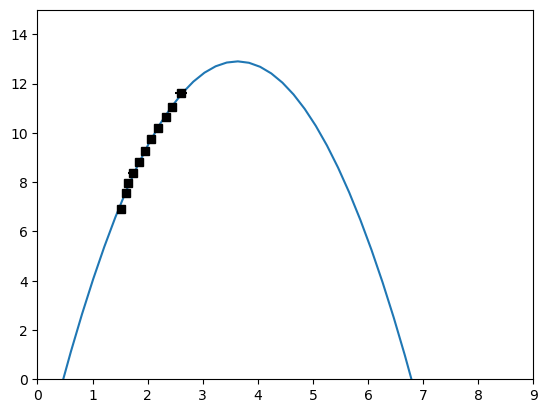

In [252]:
plt.errorbar( mvis_veff_avg,veff_ctr, xerr=mvis_veff_sig, marker='s', color='k', linestyle='none', label='TNG100 mean')
plt.xlim(0,9)
xs = np.linspace(0,20, 100)
plt.plot(xs, soln.x[0]*xs**2 + soln.x[1]*xs + soln.x[2] )

plt.ylim(0,15)

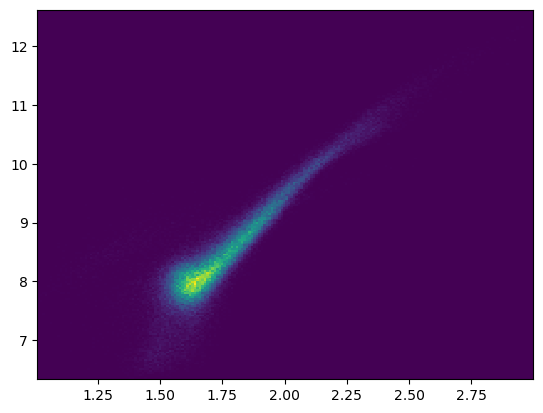

In [254]:
h,xs,ys,im  = plt.hist2d(np.log10(data['SubhaloVmax'][good_gals]),
                      tng_mbar[good_gals], bins=(200,200))

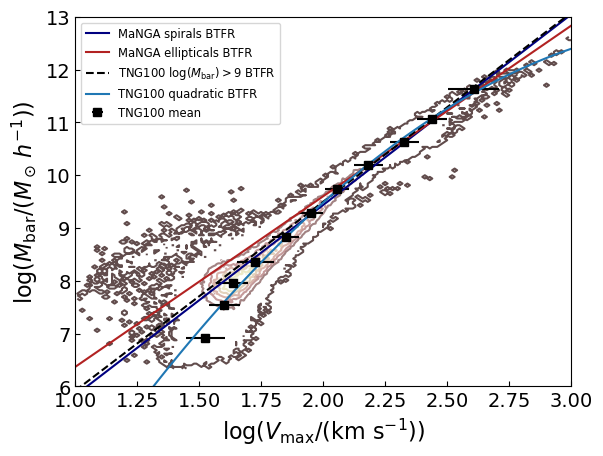

In [260]:

plt.contour(h.transpose(), extent=[xs.min(), xs.max(), ys.min(), ys.max()], cmap='pink', alpha=0.7
            )
plt.errorbar( mvis_veff_avg,veff_ctr, xerr=mvis_veff_sig, marker='s', color='k', linestyle='none', label='TNG100 mean')

vs =np.linspace(1,3,100)



plt.plot(vs, vs*s_slope + s_yint, color='navy', linestyle='-', label='MaNGA spirals BTFR')


plt.plot(vs, vs*e_slope + e_yint, color='firebrick', linestyle='-', label='MaNGA ellipticals BTFR')

plt.plot(vs, vs*tng2_slope + tng2_yint, color='k', linestyle='--', label=r'TNG100 $\log(M_{\rm bar}) > 9$ BTFR')


# N_samples =10000

# random_sample = np.random.multivariate_normal(mean=soln.x, cov=hess_inv, size=N_samples)

# is_good_random = (random_sample[:,0] > 0) & (random_sample[:,1] > 0) & (random_sample[:,2] > 0)
# good_randoms = random_sample[is_good_random, :]
    
# y_sample = np.zeros((len(vs), len(random_sample[:,0])))

# for i in range(len(vs)):
            
#             for j in range(len(random_sample[:,0])):
#         # Calculate values of curve at this location
#                 y_sample[i][j] = quad_fit(vs[i], random_sample[:,0][j],
#                                          random_sample[:,1][j],
#                                          random_sample[:,2][j])




# ms = quad_fit(vs, soln.x[0], soln.x[1], soln.x[2])
# stdevs = np.nanstd(y_sample, axis=1)                                              
# plt.fill_between(vs, ms - stdevs, ms + stdevs, color='tab:blue', alpha=0.4)

plt.plot(vs, quad_fit(vs, soln.x[0], soln.x[1], soln.x[2]), label='TNG100 quadratic BTFR')

# plt.plot(vs, vs*tng2_slope + tng2_yint, color='k', linestyle='--', label=r'TNG100 BTFR $\log(M_{\rm bar}) > 9$')


#broken power law fit
# plt.plot(np.linspace(0,broken_pw_fit[4],100), np.linspace(0,broken_pw_fit[4],100)*broken_pw_fit[0] + broken_pw_fit[1])
# plt.plot(np.linspace(broken_pw_fit[4],3,100), np.linspace(broken_pw_fit[4],3,100)*broken_pw_fit[2] + broken_pw_fit[3])

plt.xlim(1,3)
plt.ylim(6,13)

plt.tick_params( axis='both', direction='in', labelsize=14)

plt.legend(fontsize='small')
plt.xlabel(r'$\log(V_{\rm max}/ (\rm km\,\, s^{-1}))$', fontsize=16)
plt.ylabel(r'$\log(M_{\rm bar} / (M_\odot \, h^{-1}))$', fontsize=16)
#
plt.savefig(plot_dir + 'BTFR/IllustrisTNG_BTFR_HI_He_H2.png', bbox_inches='tight')

### with residuals

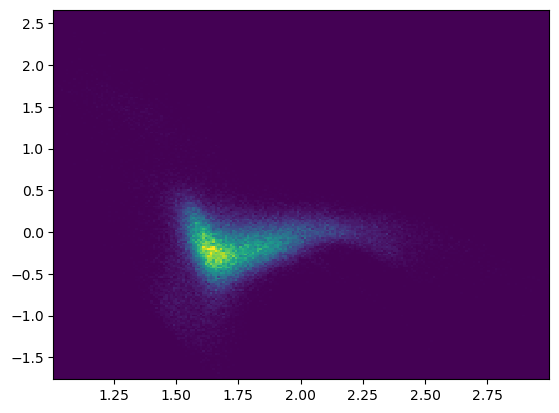

In [272]:
h2,xs2,ys2,im2  = plt.hist2d(np.log10(data['SubhaloVmax'][good_gals]),
                      tng_mbar[good_gals]- (np.log10(data['SubhaloVmax'][good_gals])*tng2_slope + tng2_yint), bins=(200,200))

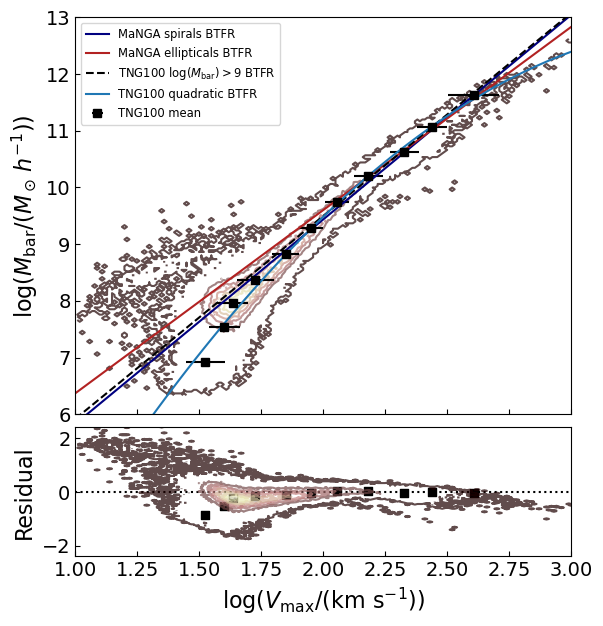

In [279]:
fig, ax = plt.subplots(2,1, figsize=(6.4,7), sharex=True, height_ratios=(4,1.3))

ax[0].contour(h.transpose(), extent=[xs.min(), xs.max(), ys.min(), ys.max()], cmap='pink', alpha=0.7
            )
ax[0].errorbar( mvis_veff_avg,veff_ctr, xerr=mvis_veff_sig, marker='s', color='k', linestyle='none', label='TNG100 mean')

vs =np.linspace(1,3,100)




ax[0].plot(vs, vs*s_slope + s_yint, color='navy', linestyle='-', label='MaNGA spirals BTFR')


ax[0].plot(vs, vs*e_slope + e_yint, color='firebrick', linestyle='-', label='MaNGA ellipticals BTFR')

ax[0].plot(vs, vs*tng2_slope + tng2_yint, color='k', linestyle='--', label=r'TNG100 $\log(M_{\rm bar}) > 9$ BTFR')


# N_samples =10000

# random_sample = np.random.multivariate_normal(mean=soln.x, cov=hess_inv, size=N_samples)

# is_good_random = (random_sample[:,0] > 0) & (random_sample[:,1] > 0) & (random_sample[:,2] > 0)
# good_randoms = random_sample[is_good_random, :]
    
# y_sample = np.zeros((len(vs), len(random_sample[:,0])))

# for i in range(len(vs)):
            
#             for j in range(len(random_sample[:,0])):
#         # Calculate values of curve at this location
#                 y_sample[i][j] = quad_fit(vs[i], random_sample[:,0][j],
#                                          random_sample[:,1][j],
#                                          random_sample[:,2][j])




# ms = quad_fit(vs, soln.x[0], soln.x[1], soln.x[2])
# stdevs = np.nanstd(y_sample, axis=1)                                              
# plt.fill_between(vs, ms - stdevs, ms + stdevs, color='tab:blue', alpha=0.4)

ax[0].plot(vs, quad_fit(vs, soln.x[0], soln.x[1], soln.x[2]), label='TNG100 quadratic BTFR')

# plt.plot(vs, vs*tng2_slope + tng2_yint, color='k', linestyle='--', label=r'TNG100 BTFR $\log(M_{\rm bar}) > 9$')


#broken power law fit
# plt.plot(np.linspace(0,broken_pw_fit[4],100), np.linspace(0,broken_pw_fit[4],100)*broken_pw_fit[0] + broken_pw_fit[1])
# plt.plot(np.linspace(broken_pw_fit[4],3,100), np.linspace(broken_pw_fit[4],3,100)*broken_pw_fit[2] + broken_pw_fit[3])

ax[0].set_xlim(1,3)
ax[0].set_ylim(6,13)

ax[0].tick_params( axis='both', direction='in', labelsize=14)
ax[1].tick_params( axis='both', direction='in', labelsize=14)


ax[0].legend(fontsize='small')
ax[1].set_xlabel(r'$\log(V_{\rm max}/ (\rm km\,\, s^{-1}))$', fontsize=16)
ax[0].set_ylabel(r'$\log(M_{\rm bar} / (M_\odot \, h^{-1}))$', fontsize=16)

fig.subplots_adjust(hspace=0.05)

ax[1].axhline(0, linestyle=':', color='k')
ax[1].contour(h2.transpose(), extent=[xs2.min(), xs2.max(), ys2.min(), ys2.max()], cmap='pink', alpha=0.7)

ax[1].scatter( mvis_veff_avg,veff_ctr- (tng2_slope*mvis_veff_avg + tng2_yint) , marker='s', color='k',  label='TNG100 mean')


ax[1].set_ylim(-2.4,2.4)

ax[1].set_ylabel('Residual', fontsize=16)
fig.savefig(plot_dir + 'BTFR/IllustrisTNG_BTFR_HI_He_H2_res.png', bbox_inches='tight')

In [280]:
quadratic_chi2_nu = chi2_quad(soln.x, np.array(veff_ctr), mvis_veff_avg, mvis_veff_sig) / (len(mvis_veff_avg) -3)

In [281]:
# write data to a file 
f = open(plot_dir + '/BTFR/all_tng/data_w_quad.txt', 'x')
f.write('veff_centers \n')
f.write(str(veff_ctr) + '\n')
f.write('mvis_avgs \n')
f.write(str(mvis_veff_avg)+ '\n')
f.write('mvis_sigs \n')
f.write(str(mvis_veff_sig)+ '\n')

f.write('Mvis > 9 slope \n')
f.write(str(tng2_slope) + ' +- ' + str(tng2_slope_bounds - tng2_slope) + '\n')
f.write('y-int \n')
f.write(str(tng2_yint) + ' +- ' + str(tng2_yint_bounds-tng2_yint)+ '\n')
f.write('chi2 nu \n')
f.write(str(tng2_chi2) + '\n')

# f.write('Mvis < 9 slope \n')
# f.write(str(tng3_slope) + ' +- ' + str(tng3_slope_bounds - tng3_slope) + '\n')
# f.write('y-int \n')
# f.write(str(tng3_yint) + ' +- ' + str(tng3_yint_bounds-tng3_yint)+ '\n')
# f.write('chi2 nu \n')
# f.write(str(chi2_3) + '\n')


f.write('quadratic fit a*v^2 + b*v +c \n')
f.write('a \n')
f.write(str(soln.x[0]) + ' +- ' + str(fit_params_err[0]) + '\n')

f.write('b \n')
f.write(str(soln.x[1]) + ' +- ' + str(fit_params_err[1]) + '\n')

f.write('c \n')
f.write(str(soln.x[2]) + ' +- ' + str(fit_params_err[2]) + '\n')


f.write('chi2 nu \n')
f.write(str(quadratic_chi2_nu))


f.close()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/nityaravi/Documents/Research/RotationCurves/data/manga/Ellipticals_Images/BTFR_paper/vmax//BTFR/all_tng/refit/data_w_quad.txt'

## sample numbers

In [341]:
len(master_table[master_table['spiral_mask']==1])

5626

In [342]:
len(master_table[master_table['elliptical_mask']==1])

2460

In [343]:
len(manga_sample[manga_sample['spiral_mask']==1])

3283

In [344]:
len(manga_sample[manga_sample['elliptical_mask']==1])

2460

In [345]:
len(s_match)

3149

In [346]:
len(e_match)

1423

## velocity inclination degeneracy

(0.0, 600.0)

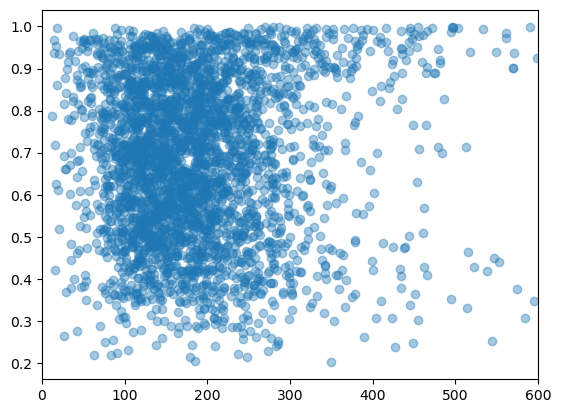

In [190]:
plt.scatter(HI_spirals['v_max'], HI_spirals['ba'], alpha=0.4)
plt.xlim(0,600)

Text(0, 0.5, 'tng100 $V_{\\rm max}$ [km/s]')

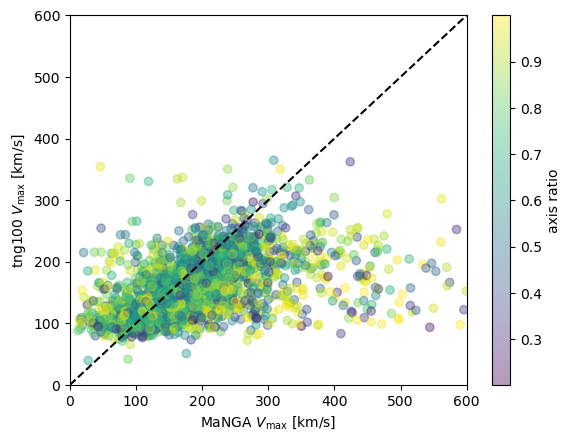

In [197]:
plt.scatter(s_match['v_max'], s_match['illustris_Vmax'], c=s_match['ba'], alpha=0.4)
plt.colorbar(label='axis ratio')
plt.xlim(0,600)
plt.ylim(0,600)
plt.plot([0,800],[0,800], color='k', linestyle='--')
plt.xlabel(r'MaNGA $V_{\rm max}$ [km/s]')
plt.ylabel(r'tng100 $V_{\rm max}$ [km/s]')


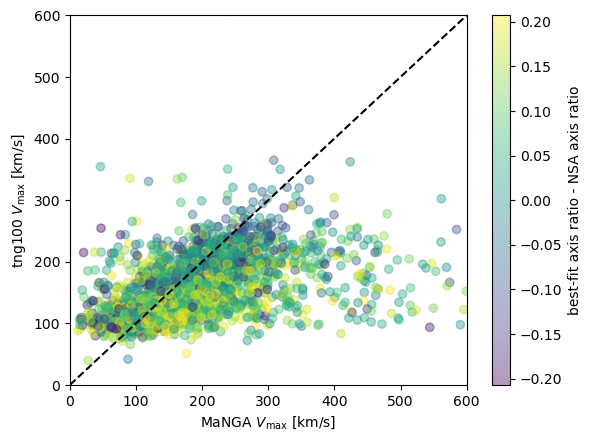

In [198]:
plt.scatter(s_match['v_max'], s_match['illustris_Vmax'], c=s_match['ba']-s_match['nsa_elpetro_ba'], alpha=0.4)
plt.colorbar(label='best-fit axis ratio - NSA axis ratio')
plt.xlim(0,600)
plt.xlabel(r'MaNGA $V_{\rm max}$ [km/s]')
plt.ylabel(r'tng100 $V_{\rm max}$ [km/s]')

plt.xlim(0,600)
plt.ylim(0,600)
plt.plot([0,800],[0,800], color='k', linestyle='--')

In [203]:
axis_ratio_bins= np.linspace(0,1,6)
ba_indices = np.digitize(s_match['ba'], axis_ratio_bins)

In [213]:
for i in range(1,6):

    
    plt.scatter(s_match['v_max'][ba_indices==i], s_match['illustris_Vmax'][ba_indices==i], c=s_match['ba'][ba_indices==i], alpha=0.4)
    plt.colorbar(label='axis ratio')
    plt.xlim(0,600)
    plt.ylim(0,600)
    plt.plot([0,800],[0,800], color='k', linestyle='--')
    plt.xlabel(r'MaNGA $V_{\rm max}$ [km/s]')
    plt.ylabel(r'tng100 $V_{\rm max}$ [km/s]')
    
    plt.savefig(plot_dir + 'vmax_bin_' + str(i) +'.png', bbox_inches='tight')
    plt.clf()

<Figure size 640x480 with 0 Axes>

(array([  0.,   0.,   0.,   0.,   0.,   0.,  11.,  51., 105., 171., 215.,
        263., 312., 363., 420., 457., 546., 605., 729., 734., 838., 922.,
        993., 994., 795., 619., 103.,   0.,   0.]),
 array([-0.1       , -0.05862069, -0.01724138,  0.02413793,  0.06551724,
         0.10689655,  0.14827586,  0.18965517,  0.23103448,  0.27241379,
         0.3137931 ,  0.35517241,  0.39655172,  0.43793103,  0.47931034,
         0.52068966,  0.56206897,  0.60344828,  0.64482759,  0.6862069 ,
         0.72758621,  0.76896552,  0.81034483,  0.85172414,  0.89310345,
         0.93448276,  0.97586207,  1.01724138,  1.05862069,  1.1       ]),
 <BarContainer object of 29 artists>)

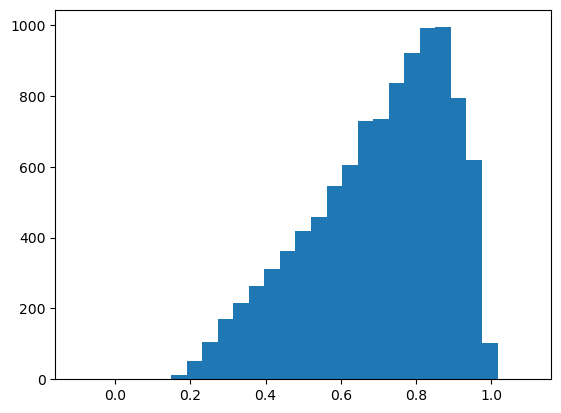

In [216]:
plt.hist(master_table['nsa_elpetro_ba'], bins=np.linspace(-0.1,1.1,30))

### checking rmax vs r90 for ellipticals

In [29]:
ellipticals[:5]

plate,ifudsgn,plateifu,mangaid,versdrp2,versdrp3,verscore,versutil,versprim,platetyp,srvymode,objra,objdec,ifuglon,ifuglat,ifura,ifudec,ebvgal,nexp,exptime,drp3qual,bluesn2,redsn2,harname,frlplug,cartid,designid,cenra,cendec,airmsmin,airmsmed,airmsmax,seemin,seemed,seemax,transmin,transmed,transmax,mjdmin,mjdmed,mjdmax,gfwhm,rfwhm,ifwhm,zfwhm,mngtarg1,mngtarg2,mngtarg3,catidnum,plttarg,manga_tileid,nsa_iauname,ifudesignsize,ifutargetsize,ifudesignwrongsize,z,zmin,zmax,szmin,szmax,ezmin,ezmax,probs,pweight,psweight,psrweight,sweight,srweight,eweight,esweight,esrweight,nsa_field,nsa_run,nsa_camcol,nsa_version,nsa_nsaid,nsa_nsaid_v1b,nsa_z,nsa_zdist,nsa_sersic_absmag,nsa_elpetro_absmag,nsa_elpetro_amivar,nsa_sersic_mass,nsa_elpetro_mass,nsa_elpetro_ba,nsa_elpetro_phi,nsa_extinction,nsa_elpetro_th50_r,nsa_petro_th50,nsa_petro_flux,nsa_petro_flux_ivar,nsa_elpetro_flux,nsa_elpetro_flux_ivar,nsa_sersic_ba,nsa_sersic_n,nsa_sersic_phi,nsa_sersic_th50,nsa_sersic_flux,nsa_sersic_flux_ivar,smoothness_score,nsa_elpetro_th90,v_sys,v_sys_err,ba,ba_err,x0,x0_err,y0,y0_err,phi,phi_err,v_max,v_max_err,r_turn,r_turn_err,chi2,alpha,alpha_err,Rmax,M,M_err,fit_flag,Sigma_disk,Sigma_disk_err,R_disk,R_disk_err,rho_bulge,rho_bulge_err,R_bulge,R_bulge_err,M90_disk,M90_disk_err,M_disk,M_disk_err,chi2_disk,WF50,WF50_err,DL_ttype,vis_tidal,b,b_err,M_R90,M_R90_err,fit_function,A_g,A_r,logH2,R90_kpc,v_3p5,v_3p5_err,NSA_plate,NSA_fiberID,NSA_MJD,logH2_CG,logH2_CG_err,logH2_M,Z,Z_err,M_Z,M_Z_err,grad_Z,grad_Z_err,Z_0,Z_0_err,SFR,sSFR,SFR_err,sSFR_err,Flux_OII_3726,Flux_OII_3726_Err,Flux_OII_3728,Flux_OII_3728_Err,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,Flux_NII_6547,Flux_NII_6547_Err,Flux_NII_6583,Flux_NII_6583_Err,Flux_Ha_6562,Flux_Ha_6562_Err,Flux_Hb_4861,Flux_Hb_4861_Err,CMD_class,rabsmag_NSA,param_H2,param_H2_err,Z_map,Z_err_map,M_Z_map,M_Z_err_map,logHI_R90,Mvir,Mvir_err,star_sigma,star_sigma_err,dipole_moment,Rgal,vflag_VF,nsa_elpetro_log_mass,rabsmag,param_H2_R90,logHe,sphd_rho_c,sphd_rho_c_err,sphd_R_scale,sphd_R_scale_err,sphd_Sigma_d,sphd_Sigma_d_err,sphd_R_d,sphd_R_d_err,sphd_M_star,sphd_M_star_err,sphd_chi2,mhq_R_scale,mhq_R_scale_err,mhq_M_star,mhq_M_star_err,mhq_gamma,mhq_gamma_err,mhq_chi2,hq_R_scale,hq_R_scale_err,hq_M_star,hq_M_star_err,hq_chi2,sph_rho_c,sph_rho_c_err,sph_R_scale,sph_R_scale_err,sph_M_star,sph_M_star_err,sph_chi2,sum_M_star,sum_M_star_err,BPT_class,spiral_mask,elliptical_mask,Age_LW_Re_fit,Age_MW_Re_fit,ZH_LW_Re_fit,ZH_MW_Re_fit,M90_disk_h,M90_disk_err_h,sphd_M_star_err_h,sphd_M_star_h,V_R90,V_R90_err,e_M_star_R90,e_M_star_R90_err,e_M_star_R90_h,e_M_star_R90_err_h,v_eff,v_eff_err,logHI,logHI_err,HI_catalog,logHI_h,logHI_err_h,N2Ha,O3Hb,nsa_u_r,illustris_match,illustris_dist,illustris_u_r,illustris_Mstar,illustris_Mstar_Sal,illustris_Vmax,illustris_flag,illustris_MR90,MH2_S14_vol,MHI_S14_vol,MHtot
int64,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,bytes32,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,bytes53,int64,bytes32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,int64,int64,int64,int64,bytes32,int64,bytes19,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,bytes6,int64,int64,float64,float64,float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64,float64,float64[7],float64[7],float64[7],float64[7],float64,float64,float64,float64,float64[7],float64[7],float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,

(array([  0.,   7.,  43., 168., 601., 340., 210., 334., 280., 166.,  85.,
         49.,  47.,  36.,  19.,  22.,   9.,   8.,   8.,   6.,   7.,   3.,
          2.,   4.,   3.,   1.,   0.,   1.,   0.]),
 array([0.        , 0.13793103, 0.27586207, 0.4137931 , 0.55172414,
        0.68965517, 0.82758621, 0.96551724, 1.10344828, 1.24137931,
        1.37931034, 1.51724138, 1.65517241, 1.79310345, 1.93103448,
        2.06896552, 2.20689655, 2.34482759, 2.48275862, 2.62068966,
        2.75862069, 2.89655172, 3.03448276, 3.17241379, 3.31034483,
        3.44827586, 3.5862069 , 3.72413793, 3.86206897, 4.        ]),
 <BarContainer object of 29 artists>)

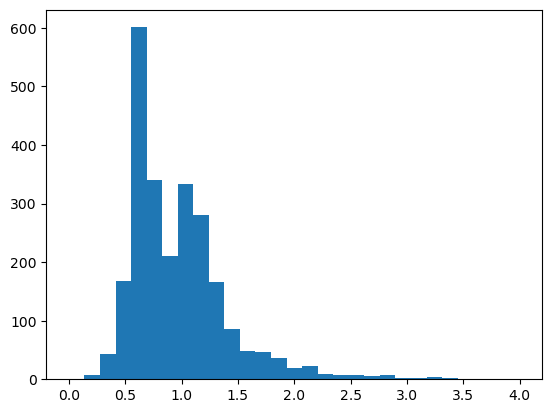

In [17]:
plt.hist(ellipticals['Rmax']/ellipticals['R90_kpc'], bins=np.linspace(0,4,30))

In [28]:
len(ellipticals[ellipticals['Rmax']/ellipticals['R90_kpc'] < 0.7])/len(ellipticals)

0.3475609756097561

(array([  0.,   1.,   1.,   0.,   3.,   4.,   7.,  13.,  23.,  21.,  27.,
         49.,  63.,  82., 102., 116., 153., 165., 215., 212., 237., 253.,
        262., 237., 259., 271., 264., 247., 266., 267., 222., 233., 192.,
        142., 136., 122.,  98.,  73.,  55.,  62.,  49.,  43.,  28.,  35.,
         26.,  23.,  16.,  20.,  16.]),
 array([0.        , 0.04081633, 0.08163265, 0.12244898, 0.16326531,
        0.20408163, 0.24489796, 0.28571429, 0.32653061, 0.36734694,
        0.40816327, 0.44897959, 0.48979592, 0.53061224, 0.57142857,
        0.6122449 , 0.65306122, 0.69387755, 0.73469388, 0.7755102 ,
        0.81632653, 0.85714286, 0.89795918, 0.93877551, 0.97959184,
        1.02040816, 1.06122449, 1.10204082, 1.14285714, 1.18367347,
        1.2244898 , 1.26530612, 1.30612245, 1.34693878, 1.3877551 ,
        1.42857143, 1.46938776, 1.51020408, 1.55102041, 1.59183673,
        1.63265306, 1.67346939, 1.71428571, 1.75510204, 1.79591837,
        1.83673469, 1.87755102, 1.91836735, 1.959183

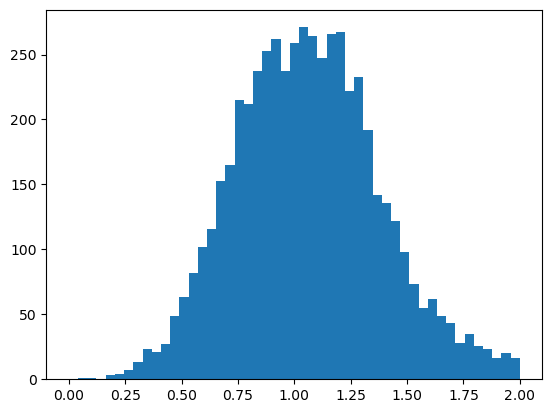

In [14]:
plt.hist(spirals['Rmax']/spirals['R90_kpc'], bins=np.linspace(0,2,50))